# Fake News Detection

In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/SynopticProject/FakeNewsDetection')

In [ ]:
import torch
print(torch.__version__)

2.10.0+cu128


# Dependencies Installation

In [ ]:
!pip install -q -U transformers accelerate
!pip install -q peft trl bitsandbytes datasets scikit-learn
!pip install shap lime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 51.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# Library Importation

In [ ]:
# Import all neccessary libraries

import re
import gc
import time
import json
import shap
import random
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter
from trl import SFTTrainer, SFTConfig
from wordcloud import WordCloud, STOPWORDS
from lime.lime_text import LimeTextExplainer

# Hugging Face
from datasets import (
    load_dataset,
    DatasetDict,
    ClassLabel,
    concatenate_datasets,
    Dataset as HFDataset
)

from transformers import (
    # Tokenizers
    AutoTokenizer,
    BertTokenizer,
    RobertaTokenizer,

    # Encoder models
    AutoModelForSequenceClassification,
    BertForSequenceClassification,
    RobertaForSequenceClassification,

    # Decoder models (Llama / Qwen)
    AutoModelForCausalLM,

    # Training utilities
    DataCollatorWithPadding,
    DataCollatorForSeq2Seq,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
    get_scheduler,

    # Early Stopping
    EarlyStoppingCallback
)

# PEFT / QLoRA
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

# PyTorch
import torch
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch import amp

# Sklearn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)

from sklearn.model_selection import train_test_split

# Hugging Face Token Authentication

In [ ]:
# Hugging Face and Colab imports

from google.colab import userdata
from huggingface_hub import login

# Log in to Hugging Face using stored access token from Colab userdata
login(token=userdata.get('HF_TOKEN'))

# First Dataset Preprocessing

Using device: cuda


Repo card metadata block was not found. Setting CardData to empty.


Dataset Splits Before: 
 DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 24353
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
})

[Sanity check] Raw label sample:
  label=0  title= ‘Maury’ Show Official Facebook Posts F*CKED UP Caption On G
  label=0  title= Trump’s Favorite News Channel Tries To Soothe His Battered 
  label=1  title=Russia warns Iraq, Kurds not to destabilize Middle East afte


Preprocessing Dataset (num_proc=4): 100%|##########| 24353/24353 [00:00<?, ? examples/s]

Preprocessing Dataset (num_proc=4): 100%|##########| 8117/8117 [00:00<?, ? examples/s]

Preprocessing Dataset (num_proc=4): 100%|##########| 8117/8117 [00:00<?, ? examples/s]

Deduplication Report
train: 24350 total, 99 duplicates within split
validation: 8115 total, 11 duplicates within split
test: 8117 total, 15 duplicates within split

Cross-split overlap BEFORE dedup:
  Train-Val overlap:  71
  Train-Test overlap: 54
  Val-Test overlap:   19

train: removed 99 duplicates (24350 -> 24251)

validation: removed 11 duplicates (8115 -> 8104)

test: removed 15 duplicates (8117 -> 8102)

Removed 125 leaked samples from train
Removed 19 leaked samples from validation

Cross-split overlap AFTER dedup:
  Train-Val overlap:  0
  Train-Test overlap: 0
  Val-Test overlap:   0
No leakage detected — splits are clean.

Dataset Splits After Dedup: 
 DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 24126
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 8085
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 8102
    })
})

Train Sample Examples:
Example 1
Text Pr

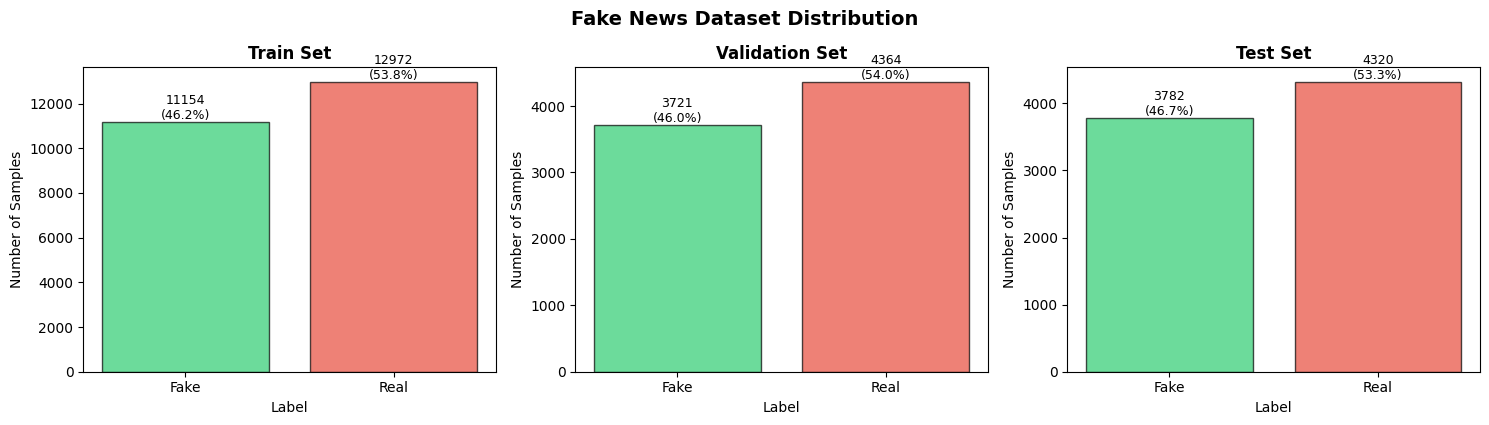

In [ ]:
# Dataset loading and preprocessing

# Detect and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load fake news dataset from Hugging face transformer
dataset = load_dataset("GonzaloA/fake_news")

# Print dataset structure before preprocessing
print(f"Dataset Splits Before: \n {dataset}")

# Label sanity check
print("\n[Sanity check] Raw label sample:")
for i in range(3):
    row = dataset['train'][i]
    print(f"  label={row['label']}  title={str(row.get('title',''))[:60]}")

# Label encoding
id2label  = {0: 'Fake', 1: 'Real'}
label2id  = {'Fake': 0, 'Real': 1}

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = str(text).lower()                          # Convert to lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)       # Remove URLs
    text = re.sub(r'<.*?>', '', text)                 # Remove HTML tags
    text = re.sub(r'[^\w\s.,!?\'"-]', ' ', text)      # Remove special characters
    text = re.sub(r'\s+', ' ', text)                  # Normalize whitespace
    return text.strip()

# Preprocessing  function
def preprocess(example):
    title = clean_text(example.get('title') or "")
    text  = clean_text(example.get('text')  or "")

    # Combine with title emphasis (Title is placed first as headlines are strong indicators of fake news)
    if title and text:
        combined = f"{title}. {text}"
    elif title:
        combined = title
    elif text:
        combined = text
    else:
        combined = "no content"

    # Strip source attribution tags to prevent artefact bias
    combined = re.sub(r'\(reuters\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(ap\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(afp\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'- reuters', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r"\s+", " ", combined).strip()

    return {
        'text': combined if combined else "no content",
        'label': example['label']
    }

# Determine columns to remove
cols_to_remove = ['title']
if 'Unnamed: 0' in dataset['train'].column_names:
    cols_to_remove.append('Unnamed: 0')

# Apply preprocessing to all splits
dataset = dataset.map(
    preprocess,
    remove_columns=cols_to_remove, # Remove unnecessary columns
    desc="Preprocessing Dataset",
    num_proc=4,
    load_from_cache_file=False
)

# Remove empty samples
dataset = dataset.filter(lambda x: x['text'] is not None and x['text'].strip() != "" and x['text'] != "no content")

# Deduplication
print("Deduplication Report")

# Check for duplicates within each split
for split_name in ['train', 'validation', 'test']:
    texts = dataset[split_name]['text']
    unique = set(texts)
    dupes = len(texts) - len(unique)
    print(f"{split_name}: {len(texts)} total, {dupes} duplicates within split")

# Check for cross-split leakage before dedup
train_texts_set = set(dataset['train']['text'])
val_texts_set = set(dataset['validation']['text'])
test_texts_set = set(dataset['test']['text'])

print(f"\nCross-split overlap BEFORE dedup:")
print(f"  Train-Val overlap:  {len(train_texts_set & val_texts_set)}")
print(f"  Train-Test overlap: {len(train_texts_set & test_texts_set)}")
print(f"  Val-Test overlap:   {len(val_texts_set & test_texts_set)}")

# Deduplicate within each split
from datasets import Dataset as HFDataset

for split_name in ['train', 'validation', 'test']:
    df = dataset[split_name].to_pandas()
    before = len(df)
    df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
    after = len(df)
    dataset[split_name] = HFDataset.from_pandas(df, preserve_index=False)
    if before != after:
        print(f"\n{split_name}: removed {before - after} duplicates ({before} -> {after})")

# Remove cross-split leakage
train_df = dataset['train'].to_pandas()
val_texts = set(dataset['validation']['text'])
test_texts = set(dataset['test']['text'])

before_train = len(train_df)
train_df = train_df[~train_df['text'].isin(val_texts | test_texts)].reset_index(drop=True)
leaked_from_train = before_train - len(train_df)

# Remove from val anything that appears in test
val_df = dataset['validation'].to_pandas()
before_val = len(val_df)
val_df = val_df[~val_df['text'].isin(test_texts)].reset_index(drop=True)
leaked_from_val = before_val - len(val_df)

if leaked_from_train > 0:
    print(f"\nRemoved {leaked_from_train} leaked samples from train")
    dataset['train'] = HFDataset.from_pandas(train_df, preserve_index=False)

if leaked_from_val > 0:
    print(f"Removed {leaked_from_val} leaked samples from validation")
    dataset['validation'] = HFDataset.from_pandas(val_df, preserve_index=False)

# Final leakage verification
print(f"\nCross-split overlap AFTER dedup:")
train_final = set(dataset['train']['text'])
val_final = set(dataset['validation']['text'])
test_final = set(dataset['test']['text'])
print(f"  Train-Val overlap:  {len(train_final & val_final)}")
print(f"  Train-Test overlap: {len(train_final & test_final)}")
print(f"  Val-Test overlap:   {len(val_final & test_final)}")

if len(train_final & val_final) + len(train_final & test_final) + len(val_final & test_final) == 0:
    print("No leakage detected — splits are clean.")
else:
    print("WARNING: Leakage still detected!")

# Shuffle training set
dataset['train'] = dataset['train'].shuffle(seed=42)

# Access dataset splits
train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

# Print dataset structure after deduplication
print(f"\nDataset Splits After Dedup: \n {dataset}")

# View sample examples
print(f"\nTrain Sample Examples:")
for i in range(5):
    example = train_dataset[i]
    print(f"Example {i+1}")
    print(f"Text Preview: {example['text'][:200]}...") # Show first 200 characters
    print(f"Label: {example['label']}")
    print(f"Text Length: {len(example['text'])} characters \n")

# Print label encoding information
print("Current Label Encoding", id2label)

# Check label distribution across all splits
print("\nLabel Distribution Analysis:")

for split_name, split_data in [('Train', train_dataset),
                               ('Validation', val_dataset),
                               ('Test', test_dataset)]:
    labels = split_data['label']
    label_counts = Counter(labels)
    total = len(labels)

    print(f"{split_name} Set ({total} samples):")
    for label_id, count in sorted(label_counts.items()):
        percentage = (count / total) * 100
        print(f"  {id2label[label_id]}: {count} ({percentage:.2f}%)")

    balance = min(label_counts.values()) / max(label_counts.values())
    print(f"  Class balance ratio: {balance:.2%} \n")

# Text Length Analysis
TOKEN_LIMIT     = 256
CHAR_THRESHOLD  = 1200

print(f"\nText Length Analysis (256 token ≈ {CHAR_THRESHOLD} character threshold):")

for split_name, split_data in [('Train', train_dataset),
                                ('Validation', val_dataset),
                                ('Test', test_dataset)]:
    lengths     = [len(ex['text']) for ex in split_data]
    long_texts  = sum(1 for l in lengths if l > CHAR_THRESHOLD)
    total       = len(lengths)

    print(f"{split_name} Set:")
    print(f"  Avg length  : {sum(lengths)/total:,.0f} characters")
    print(f"  Max length  : {max(lengths):,} characters")
    print(f"  Likely exceeding 512 tokens: {long_texts} samples ({long_texts/total*100:.1f}%) to be truncated during tokenization\n")

# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (split_name, split_data) in enumerate([('Train', train_dataset),
                                                  ('Validation', val_dataset),
                                                  ('Test', test_dataset)]):
    labels = split_data['label']
    label_counts = Counter(labels)

    # Prepare data for bar chart
    categories = [id2label[i] for i in sorted(label_counts.keys())]
    counts = [label_counts[i] for i in sorted(label_counts.keys())]
    colors = ['#2ecc71', '#e74c3c']  # Green for Real, Red for Fake

    # Plot bar chart
    bars = axes[idx].bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{split_name} Set', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Number of Samples', fontsize=10)
    axes[idx].set_xlabel('Label', fontsize=10)

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count}\n({count/sum(counts)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=9)

# Adjust layout and add global title
plt.tight_layout()
plt.suptitle('Fake News Dataset Distribution', fontsize=14, fontweight='bold', y=1.05)
plt.show()

# Word Cloud Visualisation

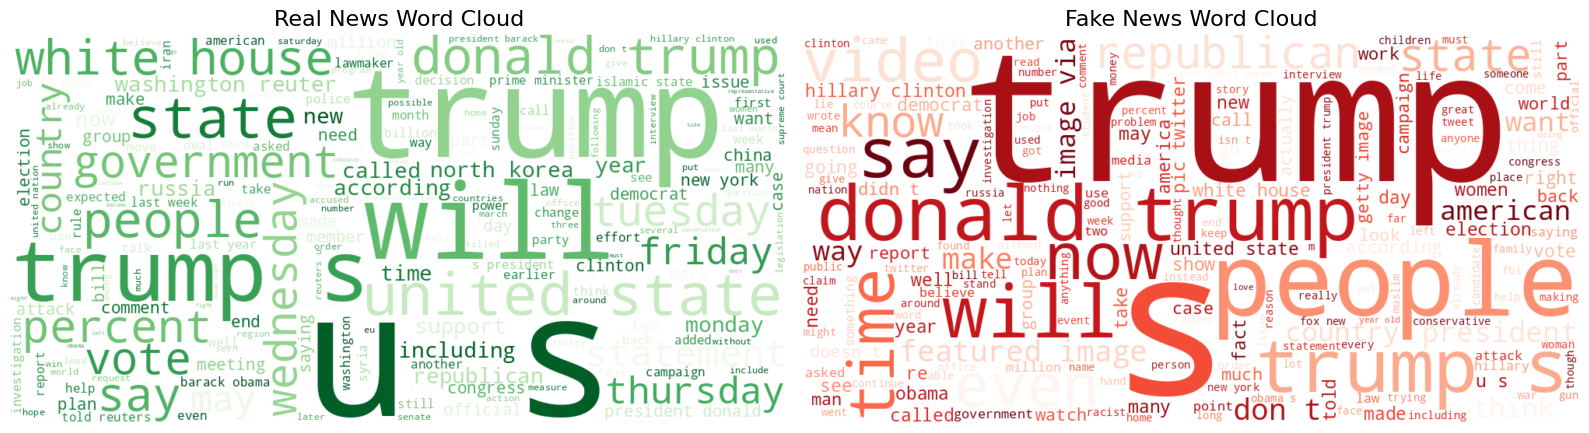

In [ ]:
# General Word Cloud

# Remove common stopwords
stopwords = set(STOPWORDS)
custom_stopwords = stopwords.union({
    "said", "mr", "would", "one", "also", "us"
})

# Separate texts by label (0 = Fake, 1 = Real)
fake_text = " ".join([ex['text'] for ex in train_dataset if ex['label'] == 0])
real_text = " ".join([ex['text'] for ex in train_dataset if ex['label'] == 1])

# Generate word cloud for fake news
fake_wc = WordCloud(background_color='white',
                    width=1000,
                    height=500,
                    stopwords=custom_stopwords,
                    colormap='Reds').generate(fake_text)

# Generate word cloud for real news
real_wc = WordCloud(background_color='white',
                    width=1000,
                    height=500,
                    stopwords=custom_stopwords,
                    colormap='Greens').generate(real_text)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(real_wc, interpolation='bilinear')
axes[0].set_title("Real News Word Cloud", fontsize=16)
axes[0].axis('off')

axes[1].imshow(fake_wc, interpolation='bilinear')
axes[1].set_title("Fake News Word Cloud", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# RoBERTa Tokenisation

In [ ]:
# Load the RoBERTa tokenizer
tokenizer_RoBERTa = RobertaTokenizer.from_pretrained('roberta-base')

# Tokenization function
def tokenize_function_RoBERTa(examples):
    return tokenizer_RoBERTa(
        examples['text'],
        truncation=True,
        padding=False,
        max_length=512,
        return_tensors=None)

# Apply tokenization separately to each splits
tokenized_train = train_dataset.map(tokenize_function_RoBERTa, batched=True, desc="Tokenizing train")
tokenized_val = val_dataset.map(tokenize_function_RoBERTa, batched=True, desc="Tokenizing validation")
tokenized_test = test_dataset.map(tokenize_function_RoBERTa, batched=True, desc="Tokenizing test")

# Convert datasets to PyTorch tensors for use with DataLoader
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Tokenization Verification
print("Tokenization Verification (Train Sample 0):")
sample = tokenized_train[0]
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label: {sample['label']} ({id2label[sample['label'].item()]})")
print(f"  Decoded preview: {tokenizer_RoBERTa.decode(sample['input_ids'], skip_special_tokens=True)[:200]}")

# Print dataset sizes
print(f"\nTokenized datasets ready!")
print(f"Train: {len(tokenized_train)} samples")
print(f"Validation: {len(tokenized_val)} samples")
print(f"Test: {len(tokenized_test)} samples")

# Dynamic Padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_RoBERTa)

# Batch Size
batch_size = 16

# Create DataLoaders
train_loader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

val_loader = DataLoader(
    tokenized_val,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

test_loader = DataLoader(
    tokenized_test,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

# Print Dataloader info
print(f"\nDataLoaders created successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Inspect a single batch to confirm shapes
batch = next(iter(train_loader))
print(f"\nSample Batch Shapes:")
print(f"  input_ids: {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels: {batch['labels'].shape}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train:   0%|          | 0/24126 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/8085 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/8102 [00:00<?, ? examples/s]

Tokenization Verification (Train Sample 0):
  input_ids shape: torch.Size([512])
  attention_mask shape: torch.Size([512])
  label: 1 (Real)
  Decoded preview: top republican ryan distances himself from trump white house bid. washington reuters - paul ryan, the top republican in the u.s. congress, took the extraordinary step on monday of distancing himself f

Tokenized datasets ready!
Train: 24126 samples
Validation: 8085 samples
Test: 8102 samples

DataLoaders created successfully!
Train batches: 1508
Validation batches: 506
Test batches: 507

Sample Batch Shapes:
  input_ids: torch.Size([16, 512])
  attention_mask: torch.Size([16, 512])
  labels: torch.Size([16])


# RoBERTa Training and Validation

In [ ]:
# Load pretrained RoBERTa model for binary classification
model_RoBERTa = RobertaForSequenceClassification.from_pretrained('roberta-base',
                                                         num_labels=2,
                                                         id2label=id2label,
                                                         label2id=label2id)

# Move the model to GPU (or CPU if GPU not available)
model_RoBERTa.to(device)

# Training configuration
num_epochs = 5
learning_rate = 2e-5
patience = 2 # Early stopping counter

# Total number of training steps
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)

# Optimizer with weight decay
optimizer = AdamW(model_RoBERTa.parameters(), lr=learning_rate, weight_decay=0.01)

# Linear learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Print training details
print(f"\nRoBERTa Training Configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Warmup steps: {warmup_steps}")
print(f"  Total training steps: {total_steps}")
print(f"  Batch size: {train_loader.batch_size}")
print(f"  Total batches per epoch: {len(train_loader)}")
print(f"  Early stopping patience : {patience}")

# Training function
def train_epoch(model_RoBERTa, dataloader, optimizer, scheduler, device):
    model_RoBERTa.train() # Set model to training mode
    total_loss = 0

    # Prints training progress
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_RoBERTa(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Loss
        loss = outputs.loss

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model_RoBERTa.parameters(), 1.0)

        # Update weights and learning rate
        optimizer.step()
        scheduler.step()

        # Track loss and learning rate
        total_loss += loss.item()
        current_lr = scheduler.get_last_lr()[0]
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': current_lr})

    # Average loss for the epoch
    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Validation function
def validate(model_RoBERTa, dataloader, device):
    model_RoBERTa.eval() # Set model to evaluation mode
    total_loss = 0
    predictions, true_labels = [], []

    # Disable gradient computation
    with torch.no_grad():
        # Prints evaluation progress
        progress_bar = tqdm(dataloader, desc="Evaluating")

        for batch in progress_bar:
           # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model_RoBERTa(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels)

            # Loss
            loss = outputs.loss

            # Store results
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

            current_lr = scheduler.get_last_lr()[0]
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': current_lr})

    # Compute evaluation metrics
    avg_loss = total_loss / len(dataloader)
    val_f1 = f1_score(true_labels, predictions, average='macro')

    return avg_loss, val_f1

# Metrics history tracking
history = {'train_loss': [],
           'val_loss': [],
           'val_f1': []}

# Training loop
print("Starting training...\n")
best_val_f1 = 0
epochs_without_improvement = 0
total_start_time = time.time() # Track training time

for epoch in range(num_epochs):
    # Start epoch timer
    epoch_start_time = time.time()

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("-" * 60)

    # Train
    train_loss = train_epoch(model_RoBERTa, train_loader, optimizer, scheduler, device)
    print(f"Train Loss: {train_loss:.4f}")

    # Validate
    val_loss, val_f1 = validate(model_RoBERTa, val_loader, device)
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val F1: {val_f1:.4f} ({val_f1*100:.4f}%)")

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch time: {epoch_time:.2f}s")

    # Store metrics history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save model with best validation F1-score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_RoBERTa.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'history': history
        }, 'best_model_RoBERTa.pt')
        tokenizer_RoBERTa.save_pretrained('best_model_tokenizer_RoBERTa/')
        print(f"Saved best model with F1-Score: {best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement in validation F1-Score. {epochs_without_improvement}/{patience} patience used")

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after epoch {epoch + 1}")
            print(f"Best F1-Score: {best_val_f1:.4f} achieved at {best_epoch + 1}")
            break
    print()

# Calculate training time
total_training_time = time.time() - total_start_time

print("\nTraining Complete.")
print(f"Best Val F1-Score: {best_val_f1:.4f} at Epoch {best_epoch + 1}")
print(f"Total training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



RoBERTa Training Configuration:
  Epochs: 5
  Learning rate: 2e-05
  Warmup steps: 754
  Total training steps: 7540
  Batch size: 16
  Total batches per epoch: 1508
  Early stopping patience : 2
Starting training...

Epoch 1/5
------------------------------------------------------------


...

Val Loss: 0.0449
Val F1: 0.9908 (99.0790%)
Epoch time: 518.84s
No improvement in validation F1-Score. 1/2 patience used

Epoch 5/5
------------------------------------------------------------


Training:   0%|          | 0/1508 [00:00<?, ?it/s]

Train Loss: 0.0048


Evaluating:   0%|          | 0/506 [00:00<?, ?it/s]

Val Loss: 0.0605
Val F1: 0.9908 (99.0788%)
Epoch time: 519.04s
No improvement in validation F1-Score. 2/2 patience used

Early stopping triggered after epoch 5
Best F1-Score: 0.9909 achieved at 3

Training Complete.
Best Val F1-Score: 0.9909 at Epoch 3
Total training time: 2628.14 seconds (43.80 minutes)


# RoBERTa Training and Validation Visualisation

Creating visualizations...


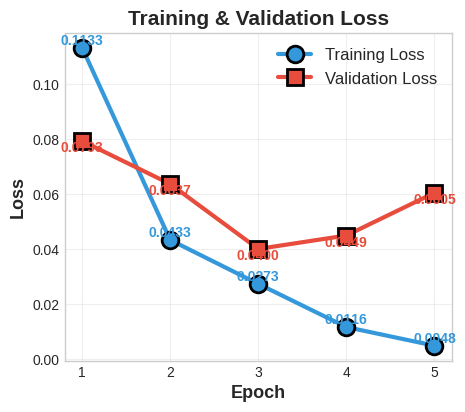

In [ ]:
# Visualisation after training and validation

print("Creating visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

epochs = list(range(1, len(history['train_loss']) + 1))

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

train_color = '#3498db' # Blue
val_color = '#e74c3c' # Red

# Training and validation loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history['train_loss'], 'o-', color=train_color, linewidth=3,
         markersize=12, label='Training Loss', markeredgecolor='black', markeredgewidth=2)
ax1.plot(epochs, history['val_loss'], 's-', color=val_color, linewidth=3,
         markersize=12, label='Validation Loss', markeredgecolor='black', markeredgewidth=2)

for i, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
    ax1.text(epochs[i], tl, f'{tl:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=train_color)
    ax1.text(epochs[i], vl, f'{vl:.4f}', ha='center', va='top',
            fontsize=10, fontweight='bold', color=val_color)

ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

plt.show()

# RoBERTa Testing

In [ ]:
def evaluate(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    predictions, true_labels = [], []
    all_logits, all_probs = [], []

    # Disable gradient computation
    with torch.no_grad():
        # Prints evaluation progress
        progress_bar = tqdm(dataloader, desc=f"Testing")

        for batch in progress_bar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            # Cross-entropy loss
            loss = outputs.loss
            logits = outputs.logits

            # Calculate probabilities and predictions
            probs = torch.softmax(logits, dim=1) # Convert logits to probabilities
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            # Store results
            total_loss += loss.item()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
            all_logits.extend(logits.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate all metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)

    # Macro F1
    macro_f1 = f1_score(true_labels, predictions, average='macro')

    # Precision and recall
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')

    return {
        'loss': avg_loss,
        'f1': macro_f1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'predictions': predictions,
        'true_labels': true_labels,
        'logits': all_logits,
        'probabilities': all_probs
    }

Loading best model for final evaluation...

 Model loaded successfully
  Epoch: 3/5
  Validation F1-Score: 0.9909
Evaluating on test set


Testing:   0%|          | 0/507 [00:00<?, ?it/s]

Final Test Set Results
Test Accuracy: 0.9901 (99.01%)
Test F1 Score: 0.9901 (99.01%)
Test Precision: 0.9899 (98.99%)
Test Recall: 0.9903 (99.03%)
Test AUC-ROC: 0.9997 (99.97%)

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9858    0.9931    0.9895      3782
        Real     0.9939    0.9875    0.9907      4320

    accuracy                         0.9901      8102
   macro avg     0.9899    0.9903    0.9901      8102
weighted avg     0.9902    0.9901    0.9901      8102

True Positives (Fake -> Fake):     3756 
False Negatives (Fake -> Real):      26 
False Positives (Real -> Fake):      54 
True Negatives (Real -> Real):     4266 

Total test samples: 8,102
Correct predictions: 8,022 (99.01%)

False Positive Rate: 0.0125 (1.25%)
False Negative Rate: 0.0069 (0.69%)


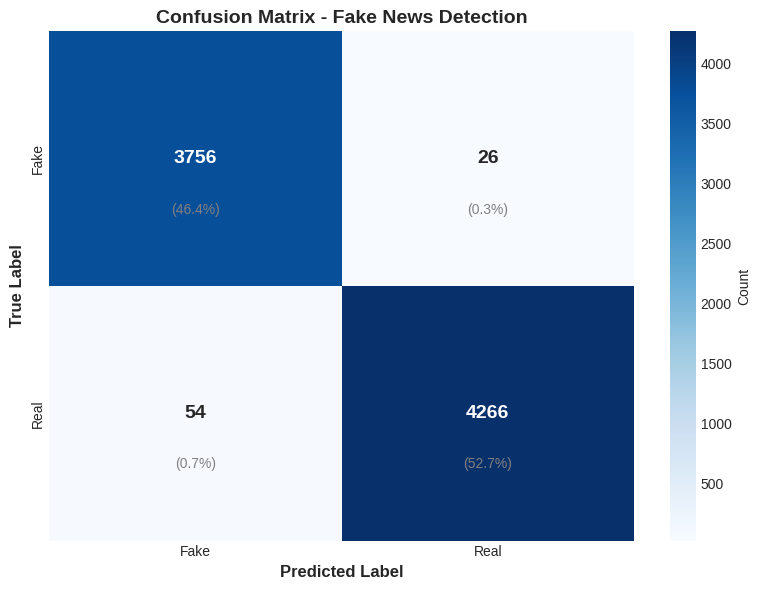

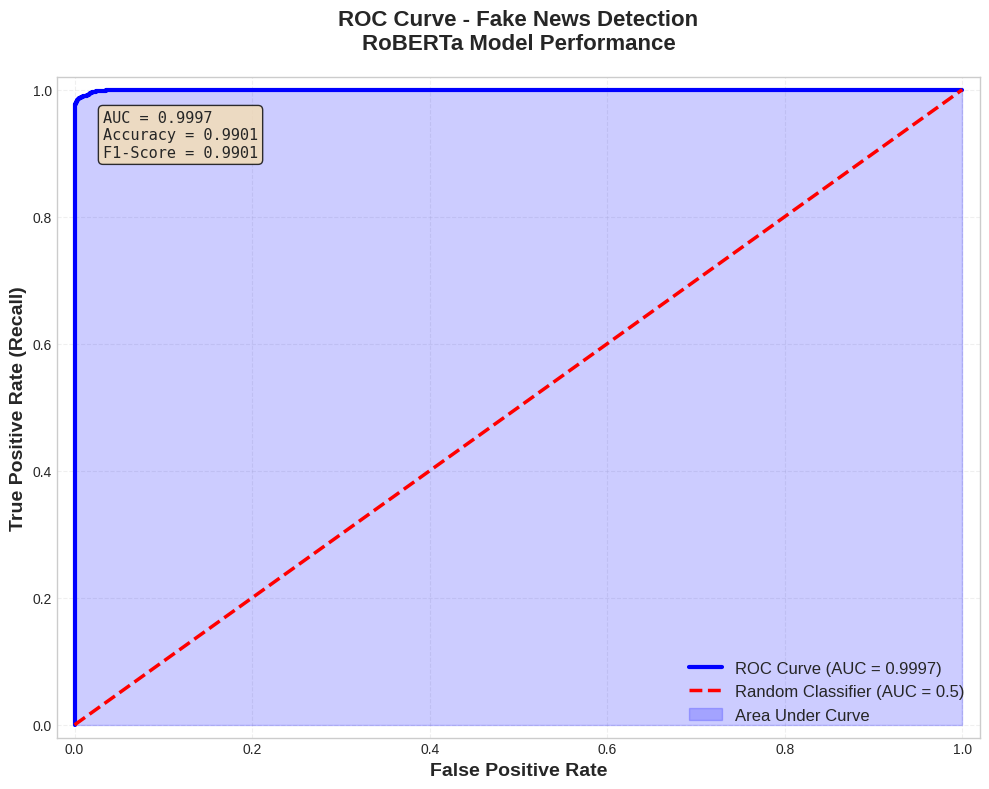

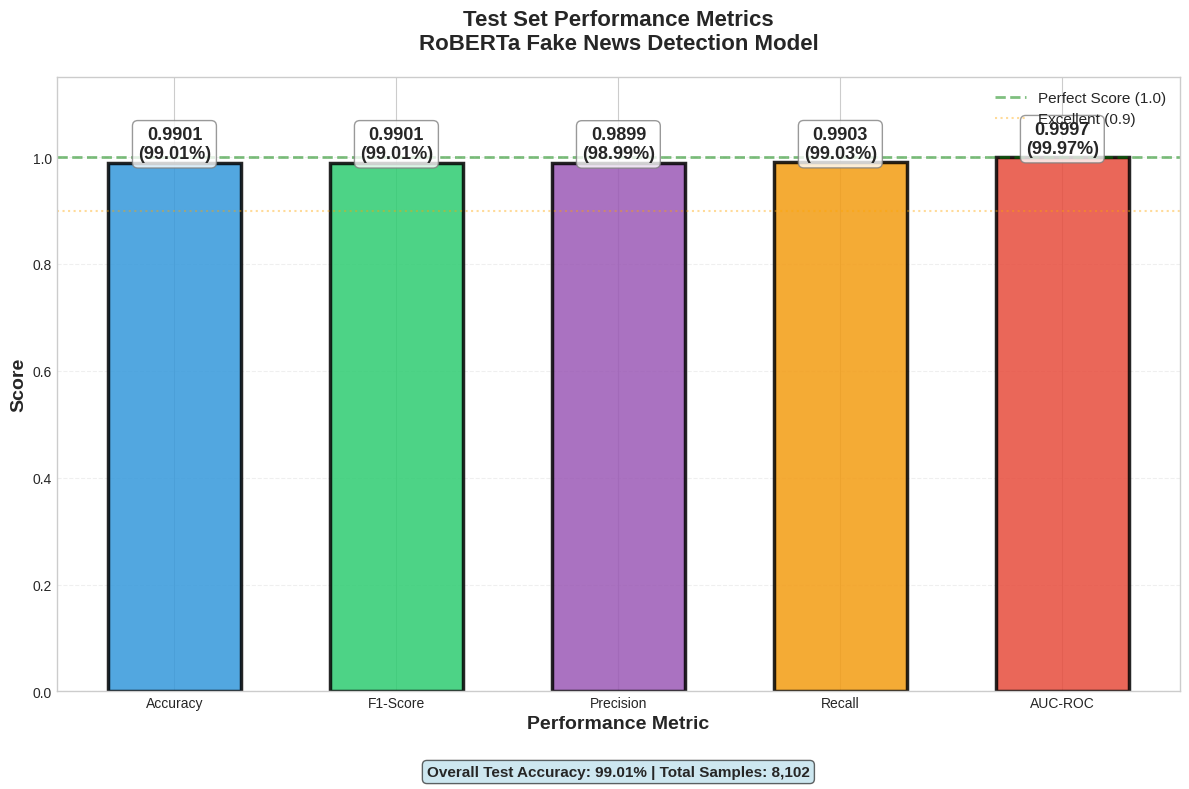

Stored GonzaloA test evauation results: Acc=0.9901, F1=0.9901


In [ ]:
# Load best model and evaluate on test set
print("Loading best model for final evaluation...")

checkpoint = torch.load('best_model_RoBERTa.pt', map_location=device)
model_RoBERTa.load_state_dict(checkpoint['model_state_dict'])

print(f"\n Model loaded successfully")
print(f"  Epoch: {checkpoint['epoch']}/{num_epochs}")
print(f"  Validation F1-Score: {checkpoint['val_f1']:.4f}")

# Evaluate on test set
print("Evaluating on test set")
RoBERTa_test_metrics = evaluate(model_RoBERTa, test_loader, device)

# Prints evaluation results
print("Final Test Set Results")
print(f"Test Accuracy: {RoBERTa_test_metrics['accuracy']:.4f} ({RoBERTa_test_metrics['accuracy']*100:.2f}%)")
print(f"Test F1 Score: {RoBERTa_test_metrics['f1']:.4f} ({RoBERTa_test_metrics['f1']*100:.2f}%)")
print(f"Test Precision: {RoBERTa_test_metrics['precision']:.4f} ({RoBERTa_test_metrics['precision']*100:.2f}%)")
print(f"Test Recall: {RoBERTa_test_metrics['recall']:.4f} ({RoBERTa_test_metrics['recall']*100:.2f}%)")

# Calculate probabilities
test_probs = np.array(RoBERTa_test_metrics['probabilities'])
real_probs = test_probs[:, 1]  # Probability of real class

auc_score = roc_auc_score(RoBERTa_test_metrics['true_labels'], real_probs)
print(f"Test AUC-ROC: {auc_score:.4f} ({auc_score*100:.2f}%)")

# Classification report
pred_labels = [id2label[p] for p in RoBERTa_test_metrics['predictions']]
true_label_names = [id2label[t] for t in RoBERTa_test_metrics['true_labels']]

print("\nClassification Report:")
print(classification_report(
    true_label_names,
    pred_labels,
    target_names=['Fake','Real'],
    digits=4
))

# Confusion matrix

cm = confusion_matrix(RoBERTa_test_metrics['true_labels'], RoBERTa_test_metrics['predictions']) # Calculate confusion matrix

# Label 0 = Fake, Label 1 = Real
print(f"True Positives (Fake -> Fake):   {cm[0][0]:>6} ")
print(f"False Negatives (Fake -> Real):  {cm[0][1]:>6} ")
print(f"False Positives (Real -> Fake):  {cm[1][0]:>6} ")
print(f"True Negatives (Real -> Real):   {cm[1][1]:>6} ")
print(f"\nTotal test samples: {cm.sum():,}")
print(f"Correct predictions: {cm[0][0] + cm[1][1]:,} ({(cm[0][0] + cm[1][1])/cm.sum()*100:.2f}%)")

fnr = cm[0][1] / cm[0].sum()
fpr = cm[1][0] / cm[1].sum()
print(f"\nFalse Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")
print(f"False Negative Rate: {fnr:.4f} ({fnr*100:.2f}%)")

# Visualise confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                ha='center', va='center', fontsize=10, color='gray')

plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Fake News Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(RoBERTa_test_metrics['true_labels'], real_probs) # Calculate ROC curve

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot ROC curve
plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Random Classifier (AUC = 0.5)')

# Fill area under curve
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='Area Under Curve')

# Labels and formatting
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Fake News Detection\nRoBERTa Model Performance',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right', framealpha=0.95, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

# Add performance annotation
textstr = f'AUC = {auc_score:.4f}\nAccuracy = {RoBERTa_test_metrics["accuracy"]:.4f}\nF1-Score = {RoBERTa_test_metrics["f1"]:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

# Bar chart
# Prepare metrics
metrics_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC']
metrics_values = [
    RoBERTa_test_metrics['accuracy'],
    RoBERTa_test_metrics['f1'],
    RoBERTa_test_metrics['precision'],
    RoBERTa_test_metrics['recall'],
    auc_score
]

# Colors for each metric
colors_bar = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

# Create figure
plt.figure(figsize=(12, 8))

# Create bars
bars = plt.bar(metrics_names, metrics_values, color=colors_bar, alpha=0.85,
               edgecolor='black', linewidth=2.5, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}\n({val*100:.2f}%)',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor='gray', alpha=0.8))

# Add horizontal reference lines
plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2,
           alpha=0.5, label='Perfect Score (1.0)')
plt.axhline(y=0.9, color='orange', linestyle=':', linewidth=1.5,
           alpha=0.4, label='Excellent (0.9)')

# Labels and formatting
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.xlabel('Performance Metric', fontsize=14, fontweight='bold')
plt.title('Test Set Performance Metrics\nRoBERTa Fake News Detection Model',
          fontsize=16, fontweight='bold', pad=20)
plt.ylim([0, 1.15])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)

# Overall performance summary
summary_text = f'Overall Test Accuracy: {RoBERTa_test_metrics["accuracy"]*100:.2f}% | Total Samples: {len(RoBERTa_test_metrics["true_labels"]):,}'
plt.text(0.5, -0.12, summary_text,
         ha='center', va='top',
         transform=plt.gca().transAxes,
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.show()

# Store results for cross-dataset summary
if 'RoBERTa_results' not in dir():
    RoBERTa_results = {}

RoBERTa_results['gonzalo'] = {
        'accuracy': RoBERTa_test_metrics['accuracy'],
        'macro_f1': RoBERTa_test_metrics['f1'],
        'precision': RoBERTa_test_metrics['precision'],
        'recall': RoBERTa_test_metrics['recall'],
        'auc_roc': auc_score,
        'confusion_matrix': cm,
        'predictions': RoBERTa_test_metrics['predictions'],
        'true_labels': RoBERTa_test_metrics['true_labels'],
        'probabilities': RoBERTa_test_metrics['probabilities']
}

print(f"Stored GonzaloA test evauation results: Acc={RoBERTa_results['gonzalo']['accuracy']:.4f}, "
      f"F1={RoBERTa_results['gonzalo']['macro_f1']:.4f}")

# RoBERTa Prediction

Sample Predictions (10 random examples from test set)


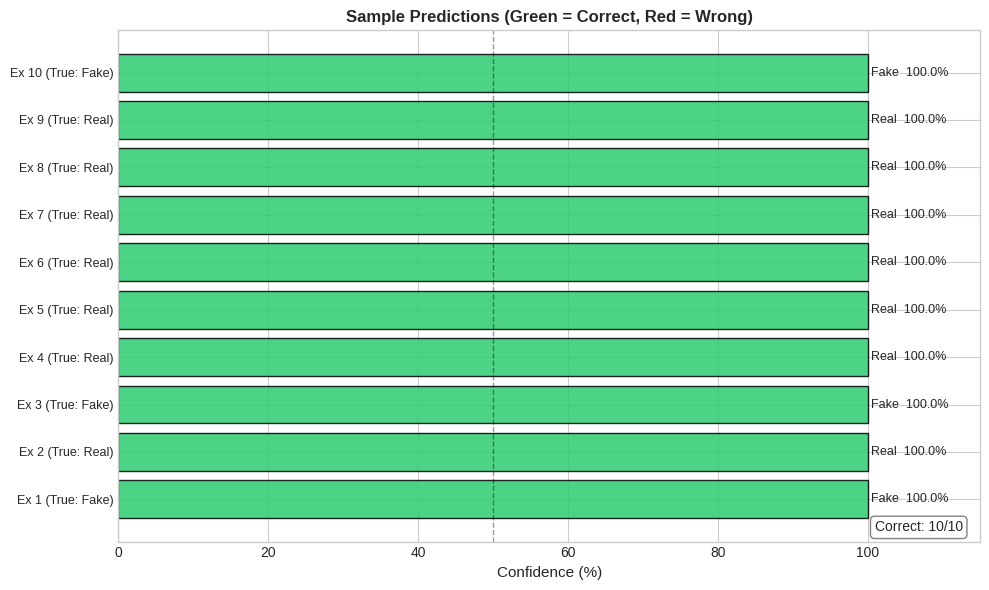

In [ ]:
# Model Sample Prediction

sample_size = 10
sample_indices = random.sample(range(len(test_dataset)), sample_size)

print(f"Sample Predictions ({sample_size} random examples from test set)")

model_RoBERTa.eval()

labels_true, labels_pred, confidences, texts = [], [], [], []

for idx in sample_indices:
    text = test_dataset[idx]['text']
    true_label = test_dataset[idx]['label']

    encoded = tokenizer_RoBERTa(
            text,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors='pt')

    with torch.no_grad():
        outputs = model_RoBERTa(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device)
        )
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
        pred  = int(np.argmax(probs))

    labels_true.append(true_label)
    labels_pred.append(pred)
    confidences.append(probs[pred] * 100)
    texts.append(text[:60] + '...')

# Display Predictions
bar_colors = ['#2ecc71' if p == t else '#e74c3c'
        for p, t in zip(labels_pred, labels_true)]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(sample_size), confidences, color=bar_colors,
               alpha=0.85, edgecolor='black')

# Add predicted label and confidence on each bar
for i, (bar, pred, conf) in enumerate(zip(bars, labels_pred, confidences)):
    ax.text(conf + 0.5, i, f"{id2label[pred]}  {conf:.1f}%",
            va='center', fontsize=9)

ax.set_yticks(range(sample_size))
ax.set_yticklabels([f"Ex {i+1} (True: {id2label[t]})"
                    for i, t in enumerate(labels_true)], fontsize=9)
ax.set_xlabel('Confidence (%)', fontsize=11)
ax.set_title('Sample Predictions (Green = Correct, Red = Wrong)',
             fontsize=12, fontweight='bold')
ax.set_xlim([0, 115])
ax.axvline(x=50, color='black', linestyle='--', linewidth=1, alpha=0.4)

correct = sum(p == t for p, t in zip(labels_pred, labels_true))
ax.text(0.98, 0.02, f"Correct: {correct}/{sample_size}",
        transform=ax.transAxes, fontsize=10, ha='right',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

# RoBERTa Custom Input

In [ ]:
# Inference on Custom Input
def predict_custom(text, model, tokenizer, device):
    # Set model to evaluation mode
    model.eval()

    # Tokenise input text
    encoded = tokenizer(
        text,
        truncation=True, # Ensures max length is respected
        padding=True, # Ensures consistent tensor shape
        max_length=512, # Maximum text length
        return_tensors='pt' # Returns PyTorch tensors
    )

    with torch.no_grad():# Disable gradient calculation for inference
        # Forward pass through the model
        outputs = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device)
        )

        # Convert logits to probabilities
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

        # Get predicted class
        pred  = int(np.argmax(probs))

    return pred, probs

# Test with Custom Headlines / Articles
custom_inputs = [
    "Manchester Metropolitan University is a university in Manchester England",
    "Scientists discover new vaccine that eliminates all known diseases overnight",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns",
    "Government puts fluoride in water to control the population and leaked documents reveal",
    "Apple announces new iPhone with record-breaking battery life",
    "The stock market is expected to rise next quarter due to economic growth",
    "Breaking news as major earthquake strikes downtown area",
    "New technology is revolutionizing the healthcare industry",
    "The local sports team wins the championship after a thrilling match",
    "Scientists discover a new planet that could support life",
    "Local man wins lottery and buys new mansion",
    "Study reveals that drinking coffee can actually improve your memory",
    "New research shows that climate change is accelerating at an alarming rate",
    "Celebrity couple announces their divorce after 10 years of marriage",
    "Unbelievable as man claims to have spoken with aliens during a camping trip"
]

print("Custom Input Predictions")

# Loop through each example and perform inference
for i, text in enumerate(custom_inputs):
    # Get prediction and probabilities
    pred, probs = predict_custom(text, model_RoBERTa, tokenizer_RoBERTa, device)

    # Confidence score of predicted class
    confidence  = probs[pred] * 100

    # Convert label index to readable class name
    label       = id2label[pred]

    # Colour formatting for terminal output
    color = '\033[92m' if pred == 1 else '\033[91m'  # Green = Real (1), Red = Fake (0)
    reset       = '\033[0m'

    # Print prediction summary
    print(f"{color}Example {i+1}: {label} ({confidence:.1f}% confidence){reset}")
    print(f"  Text : {text}")

    # Print probability distribution
    print(f"  Fake: {probs[0]*100:.1f}%  |  Real : {probs[1]*100:.1f}%")

Custom Input Predictions
Example 1: Real (96.2% confidence)
  Text : Manchester Metropolitan University is a university in Manchester England
  Fake: 3.8%  |  Real : 96.2%
Example 2: Fake (99.0% confidence)
  Text : Scientists discover new vaccine that eliminates all known diseases overnight
  Fake: 99.0%  |  Real : 1.0%
Example 3: Real (94.1% confidence)
  Text : Federal Reserve raises interest rates by 0.25% amid inflation concerns
  Fake: 5.9%  |  Real : 94.1%
Example 4: Fake (99.5% confidence)
  Text : Government puts fluoride in water to control the population and leaked documents reveal
  Fake: 99.5%  |  Real : 0.5%
Example 5: Fake (99.0% confidence)
  Text : Apple announces new iPhone with record-breaking battery life
  Fake: 99.0%  |  Real : 1.0%
Example 6: Real (90.2% confidence)
  Text : The stock market is expected to rise next quarter due to economic growth
  Fake: 9.8%  |  Real : 90.2%
Example 7: Fake (99.9% confidence)
  Text : Breaking news as major earthquake strikes do

# BERT Tokenisation

In [ ]:
# Load the BERT tokenizer
tokenizer_BERT = AutoTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function
def tokenize_function_BERT(examples):
    return tokenizer_BERT(
        examples['text'],
        truncation=True,
        padding=False,
        max_length=512,
        return_tensors=None)

# Apply tokenization separately to each splits
tokenized_train = train_dataset.map(tokenize_function_BERT, batched=True, desc="Tokenizing train")
tokenized_val = val_dataset.map(tokenize_function_BERT, batched=True, desc="Tokenizing validation")
tokenized_test = test_dataset.map(tokenize_function_BERT, batched=True, desc="Tokenizing test")

# Convert datasets to PyTorch tensors for use with DataLoader
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'label'])

# Tokenization Verification
print("Tokenization Verification (Train Sample 0):")
sample = tokenized_train[0]
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label: {sample['label']} ({id2label[sample['label'].item()]})")
print(f"  Decoded preview: {tokenizer_BERT.decode(sample['input_ids'], skip_special_tokens=True)[:200]}")

# Print dataset sizes
print(f"\nTokenized datasets ready!")
print(f"Train: {len(tokenized_train)} samples")
print(f"Validation: {len(tokenized_val)} samples")
print(f"Test: {len(tokenized_test)} samples")

# Dynamic Padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_BERT)

# Batch Size
batch_size = 16

# Create DataLoaders
train_loader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

val_loader = DataLoader(
    tokenized_val,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

test_loader = DataLoader(
    tokenized_test,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=0,
    pin_memory=True )

# Print Dataloader info
print(f"\nDataLoaders created successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Inspect a single batch to confirm shapes
batch = next(iter(train_loader))
print(f"\nSample Batch Shapes:")
print(f"  input_ids: {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  labels: {batch['labels'].shape}")

Tokenizing train:   0%|          | 0/24126 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/8085 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/8102 [00:00<?, ? examples/s]

Tokenization Verification (Train Sample 0):
  input_ids shape: torch.Size([512])
  attention_mask shape: torch.Size([512])
  label: 1 (Real)
  Decoded preview: top republican ryan distances himself from trump white house bid. washington reuters - paul ryan, the top republican in the u. s. congress, took the extraordinary step on monday of distancing himself 

Tokenized datasets ready!
Train: 24126 samples
Validation: 8085 samples
Test: 8102 samples

DataLoaders created successfully!
Train batches: 1508
Validation batches: 506
Test batches: 507

Sample Batch Shapes:
  input_ids: torch.Size([16, 512])
  attention_mask: torch.Size([16, 512])
  labels: torch.Size([16])


# BERT Training and Validation

In [ ]:
# Load pretrained BERT model for binary classification
model_BERT = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased',
                                                         num_labels=2,
                                                         id2label=id2label,
                                                         label2id=label2id)

# Move the model to GPU (or CPU if GPU not available)
model_BERT.to(device)

# Training configuration
num_epochs = 5
learning_rate = 2e-5
patience = 2 # Early stopping counter

# Total number of training steps
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)

# Optimizer with weight decay
optimizer = AdamW(model_BERT.parameters(), lr=learning_rate, weight_decay=0.01)

# Linear learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Print training details
print(f"\nBERT Training Configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Warmup steps: {warmup_steps}")
print(f"  Total training steps: {total_steps}")
print(f"  Batch size: {train_loader.batch_size}")
print(f"  Total batches per epoch: {len(train_loader)}")
print(f"  Early stopping patience : {patience}")

# Training function
def train_epoch(model_BERT, dataloader, optimizer, scheduler, device):
    model_BERT.train() # Set model to training mode
    total_loss = 0

    # Prints training progress
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_BERT(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Loss
        loss = outputs.loss

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model_BERT.parameters(), 1.0)

        # Update weights and learning rate
        optimizer.step()
        scheduler.step()

        # Track loss and learning rate
        total_loss += loss.item()
        current_lr = scheduler.get_last_lr()[0]
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': current_lr})

    # Average loss for the epoch
    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Validation function
def validate(model_BERT, dataloader, device):
    model_BERT.eval() # Set model to evaluation mode
    total_loss = 0
    predictions, true_labels = [], []

    # Disable gradient computation
    with torch.no_grad():
        # Prints evaluation progress
        progress_bar = tqdm(dataloader, desc="Evaluating")

        for batch in progress_bar:
           # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model_BERT(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels)

            # Loss
            loss = outputs.loss

            # Store results
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

            current_lr = scheduler.get_last_lr()[0]
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': current_lr})

    # Compute evaluation metrics
    avg_loss = total_loss / len(dataloader)
    val_f1 = f1_score(true_labels, predictions, average='macro')

    return avg_loss, val_f1

# Metrics history tracking
history = {'train_loss': [],
           'val_loss': [],
           'val_f1': []}

# Training loop
print("Starting training...\n")
best_val_f1 = 0
epochs_without_improvement = 0
total_start_time = time.time() # Track training time

for epoch in range(num_epochs):
    # Start epoch timer
    epoch_start_time = time.time()

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("-" * 60)

    # Train
    train_loss = train_epoch(model_BERT, train_loader, optimizer, scheduler, device)
    print(f"Train Loss: {train_loss:.4f}")

    # Validate
    val_loss, val_f1 = validate(model_BERT, val_loader, device)
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val F1: {val_f1:.4f} ({val_f1*100:.4f}%)")

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch time: {epoch_time:.2f}s")

    # Store metrics history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save model with best validation F1-score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_BERT.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'history': history
        }, 'best_model_BERT.pt')
        tokenizer_BERT.save_pretrained('best_model_tokenizer_BERT/')
        print(f"Saved best model with F1-Score: {best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement in validation F1-Score. {epochs_without_improvement}/{patience} patience used")

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after epoch {epoch + 1}")
            print(f"Best F1-Score: {best_val_f1:.4f} achieved at {best_epoch + 1}")
            break
    print()

# Calculate training time
total_training_time = time.time() - total_start_time

print("\nTraining Complete.")
print(f"Best Val F1-Score: {best_val_f1:.4f} at Epoch {best_epoch + 1}")
print(f"Total training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT Training Configuration:
  Epochs: 5
  Learning rate: 2e-05
  Warmup steps: 754
  Total training steps: 7540
  Batch size: 16
  Total batches per epoch: 1508
  Early stopping patience : 2
Starting training...

Epoch 1/5
------------------------------------------------------------


Training:   0%|          | 0/1508 [00:00<?, ?it/s]

...

Val Loss: 0.0668
Val F1: 0.9905 (99.0535%)
Epoch time: 523.59s
No improvement in validation F1-Score. 1/2 patience used

Epoch 5/5
------------------------------------------------------------


Training:   0%|          | 0/1508 [00:00<?, ?it/s]

Train Loss: 0.0006


Evaluating:   0%|          | 0/506 [00:00<?, ?it/s]

Val Loss: 0.0644
Val F1: 0.9910 (99.1037%)
Epoch time: 523.66s
No improvement in validation F1-Score. 2/2 patience used

Early stopping triggered after epoch 5
Best F1-Score: 0.9913 achieved at 3

Training Complete.
Best Val F1-Score: 0.9913 at Epoch 3
Total training time: 2659.30 seconds (44.32 minutes)


# BERT Training and Validation Visualisation

Creating visualizations...


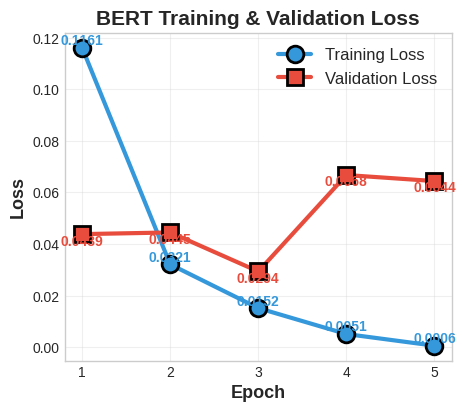

In [ ]:
# Visualisation after training and validation

print("Creating visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

epochs = list(range(1, len(history['train_loss']) + 1))

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

train_color = '#3498db' # Blue
val_color = '#e74c3c' # Red

# Training and validation loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history['train_loss'], 'o-', color=train_color, linewidth=3,
         markersize=12, label='Training Loss', markeredgecolor='black', markeredgewidth=2)
ax1.plot(epochs, history['val_loss'], 's-', color=val_color, linewidth=3,
         markersize=12, label='Validation Loss', markeredgecolor='black', markeredgewidth=2)

for i, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
    ax1.text(epochs[i], tl, f'{tl:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=train_color)
    ax1.text(epochs[i], vl, f'{vl:.4f}', ha='center', va='top',
            fontsize=10, fontweight='bold', color=val_color)

ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('BERT Training & Validation Loss', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

plt.show()

# BERT Testing

In [ ]:
def evaluate(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    predictions, true_labels = [], []
    all_logits, all_probs = [], []

    # Disable gradient computation
    with torch.no_grad():
        # Prints evaluation progress
        progress_bar = tqdm(dataloader, desc=f"Testing")

        for batch in progress_bar:
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            # Loss
            loss = outputs.loss
            logits = outputs.logits

            # Calculate probabilities and predictions
            probs = torch.softmax(logits, dim=1) # Convert logits to probabilities
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            # Store results
            total_loss += loss.item()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
            all_logits.extend(logits.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate all metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)

    # Macro F1
    macro_f1 = f1_score(true_labels, predictions, average='macro')

    # Precision and recall
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')

    return {
        'loss': avg_loss,
        'f1': macro_f1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'predictions': predictions,
        'true_labels': true_labels,
        'logits': all_logits,
        'probabilities': all_probs
    }

Loading best model for final evaluation...

 Model loaded successfully
  Epoch: 3/5
  Validation F1-Score: 0.9913
Evaluating on test set


Testing:   0%|          | 0/507 [00:00<?, ?it/s]

Final Test Set Results
Test Accuracy: 0.9904 (99.04%)
Test F1 Score: 0.9903 (99.03%)
Test Precision: 0.9903 (99.03%)
Test Recall: 0.9904 (99.04%)
Test AUC-ROC: 0.9997 (99.97%)

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9884    0.9910    0.9897      3782
        Real     0.9921    0.9898    0.9910      4320

    accuracy                         0.9904      8102
   macro avg     0.9903    0.9904    0.9903      8102
weighted avg     0.9904    0.9904    0.9904      8102

True Positives (Fake -> Fake):     3748 
False Negatives (Fake -> Real):      34 
False Positives (Real -> Fake):      44 
True Negatives (Real -> Real):     4276 

Total test samples: 8,102
Correct predictions: 8,024 (99.04%)

False Positive Rate: 0.0102 (1.02%)
False Negative Rate: 0.0090 (0.90%)


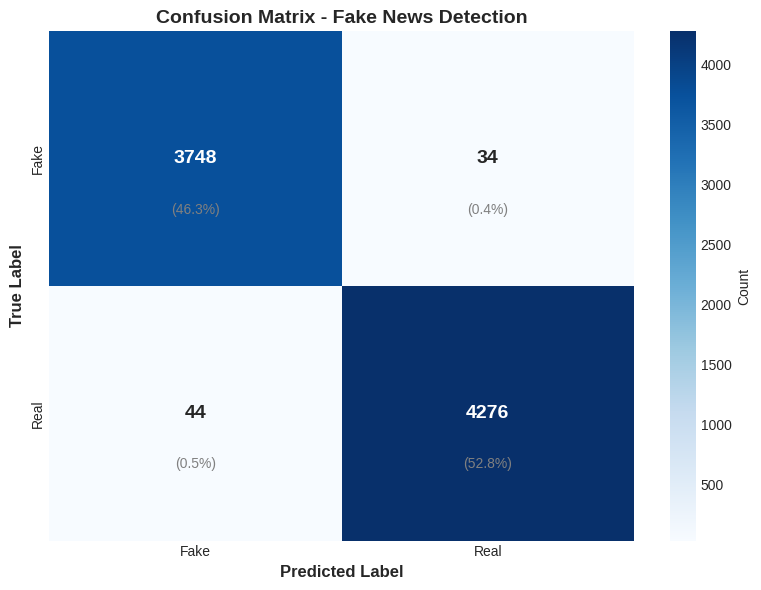

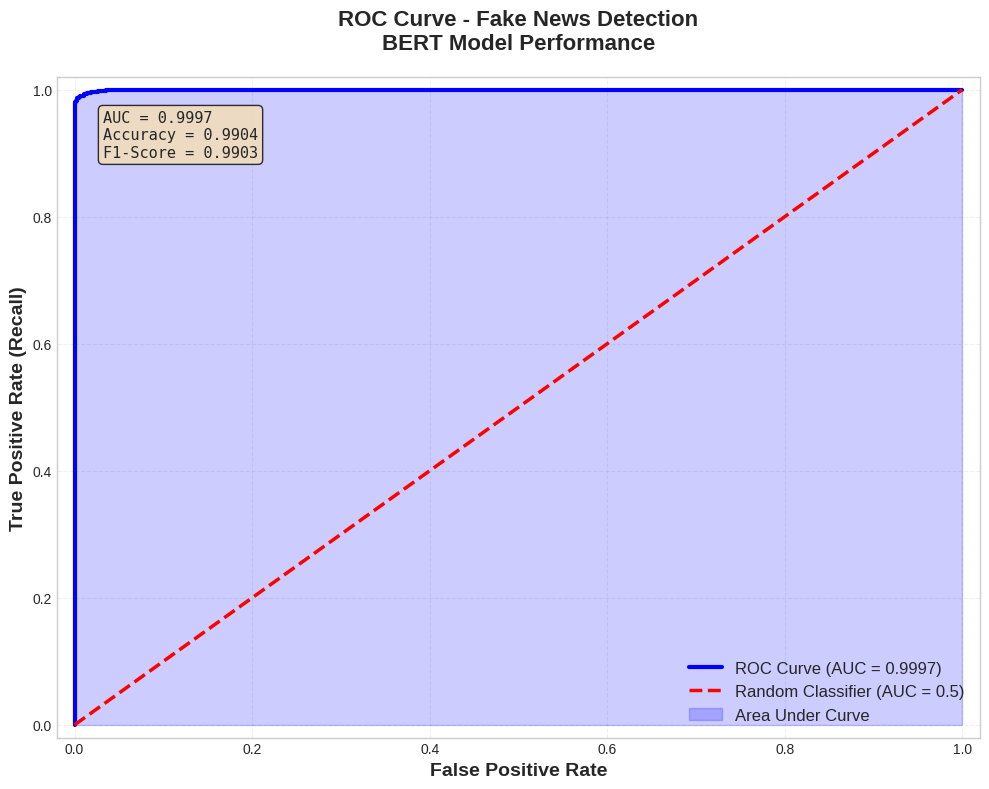

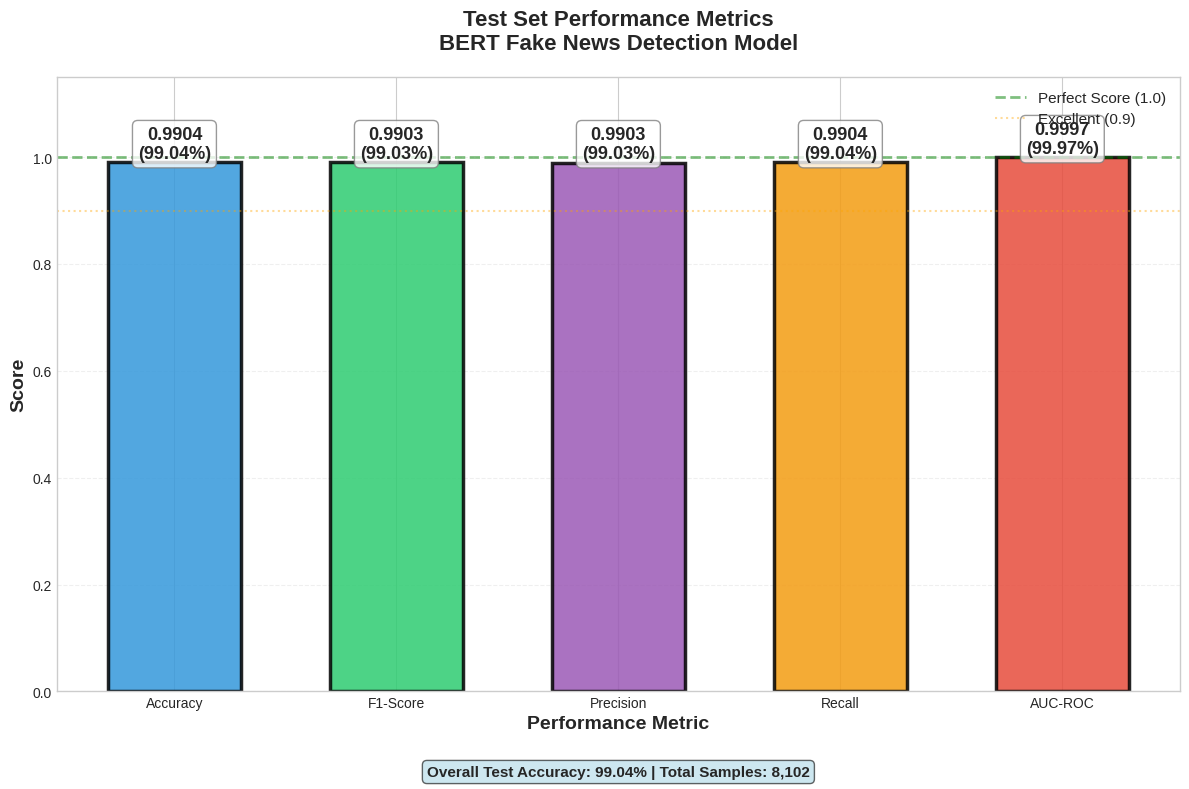

Stored GonzaloA test evaluation results: Acc=0.9904, F1=0.9903


In [ ]:
# Load best model and evaluate on test set
print("Loading best model for final evaluation...")

checkpoint = torch.load('best_model_BERT.pt', map_location=device)
model_BERT.load_state_dict(checkpoint['model_state_dict'])

print(f"\n Model loaded successfully")
print(f"  Epoch: {checkpoint['epoch']}/{num_epochs}")
print(f"  Validation F1-Score: {checkpoint['val_f1']:.4f}")

# Evaluate on test set
print("Evaluating on test set")
BERT_test_metrics = evaluate(model_BERT, test_loader, device)

# Prints evaluation results
print("Final Test Set Results")
print(f"Test Accuracy: {BERT_test_metrics['accuracy']:.4f} ({BERT_test_metrics['accuracy']*100:.2f}%)")
print(f"Test F1 Score: {BERT_test_metrics['f1']:.4f} ({BERT_test_metrics['f1']*100:.2f}%)")
print(f"Test Precision: {BERT_test_metrics['precision']:.4f} ({BERT_test_metrics['precision']*100:.2f}%)")
print(f"Test Recall: {BERT_test_metrics['recall']:.4f} ({BERT_test_metrics['recall']*100:.2f}%)")

# Calculate probabilities
test_probs = np.array(BERT_test_metrics['probabilities'])
real_probs = test_probs[:, 1]  # Probability of real class

auc_score = roc_auc_score(BERT_test_metrics['true_labels'], real_probs)
print(f"Test AUC-ROC: {auc_score:.4f} ({auc_score*100:.2f}%)")

# Classification report
pred_labels = [id2label[p] for p in BERT_test_metrics['predictions']]
true_label_names = [id2label[t] for t in BERT_test_metrics['true_labels']]

print("\nClassification Report:")
print(classification_report(
    true_label_names,
    pred_labels,
    target_names=['Fake', 'Real'],
    digits=4
))

# Confusion matrix

cm = confusion_matrix(BERT_test_metrics['true_labels'], BERT_test_metrics['predictions']) # Calculate confusion matrix

# Label 0 = Fake, Label 1 = Real
print(f"True Positives (Fake -> Fake):   {cm[0][0]:>6} ")
print(f"False Negatives (Fake -> Real):  {cm[0][1]:>6} ")
print(f"False Positives (Real -> Fake):  {cm[1][0]:>6} ")
print(f"True Negatives (Real -> Real):   {cm[1][1]:>6} ")
print(f"\nTotal test samples: {cm.sum():,}")
print(f"Correct predictions: {cm[0][0] + cm[1][1]:,} ({(cm[0][0] + cm[1][1])/cm.sum()*100:.2f}%)")

fnr = cm[0][1] / cm[0].sum()
fpr = cm[1][0] / cm[1].sum()
print(f"\nFalse Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")
print(f"False Negative Rate: {fnr:.4f} ({fnr*100:.2f}%)")

# Visualise confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                ha='center', va='center', fontsize=10, color='gray')

plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Fake News Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(BERT_test_metrics['true_labels'], real_probs) # Calculate ROC curve

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot ROC curve
plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Random Classifier (AUC = 0.5)')

# Fill area under curve
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='Area Under Curve')

# Labels and formatting
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Fake News Detection\nBERT Model Performance',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right', framealpha=0.95, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

# Add performance annotation
textstr = f'AUC = {auc_score:.4f}\nAccuracy = {BERT_test_metrics["accuracy"]:.4f}\nF1-Score = {BERT_test_metrics["f1"]:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

# Bar chart
# Prepare metrics
metrics_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC']
metrics_values = [
    BERT_test_metrics['accuracy'],
    BERT_test_metrics['f1'],
    BERT_test_metrics['precision'],
    BERT_test_metrics['recall'],
    auc_score
]

# Colors for each metric
colors_bar = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

# Create figure
plt.figure(figsize=(12, 8))

# Create bars
bars = plt.bar(metrics_names, metrics_values, color=colors_bar, alpha=0.85,
               edgecolor='black', linewidth=2.5, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}\n({val*100:.2f}%)',
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor='gray', alpha=0.8))

# Add horizontal reference lines
plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2,
           alpha=0.5, label='Perfect Score (1.0)')
plt.axhline(y=0.9, color='orange', linestyle=':', linewidth=1.5,
           alpha=0.4, label='Excellent (0.9)')

# Labels and formatting
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.xlabel('Performance Metric', fontsize=14, fontweight='bold')
plt.title('Test Set Performance Metrics\nBERT Fake News Detection Model',
          fontsize=16, fontweight='bold', pad=20)
plt.ylim([0, 1.15])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)

# Overall performance summary
summary_text = f'Overall Test Accuracy: {BERT_test_metrics["accuracy"]*100:.2f}% | Total Samples: {len(BERT_test_metrics["true_labels"]):,}'
plt.text(0.5, -0.12, summary_text,
         ha='center', va='top',
         transform=plt.gca().transAxes,
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.show()

# Store results for cross-dataset summary
if 'BERT_results' not in dir():
    BERT_results = {}

# Store results for cross-dataset summary
BERT_results['gonzalo'] = {
        'accuracy': BERT_test_metrics['accuracy'],
        'macro_f1': BERT_test_metrics['f1'],
        'precision': BERT_test_metrics['precision'],
        'recall': BERT_test_metrics['recall'],
        'auc_roc': auc_score,
        'confusion_matrix': cm,
        'predictions': BERT_test_metrics['predictions'],
        'true_labels': BERT_test_metrics['true_labels'],
        'probabilities': BERT_test_metrics['probabilities']
}

print(f"Stored GonzaloA test evaluation results: Acc={BERT_results['gonzalo']['accuracy']:.4f}, "
      f"F1={BERT_results['gonzalo']['macro_f1']:.4f}")

# BERT Prediction

Sample Predictions (10 random examples from test set)


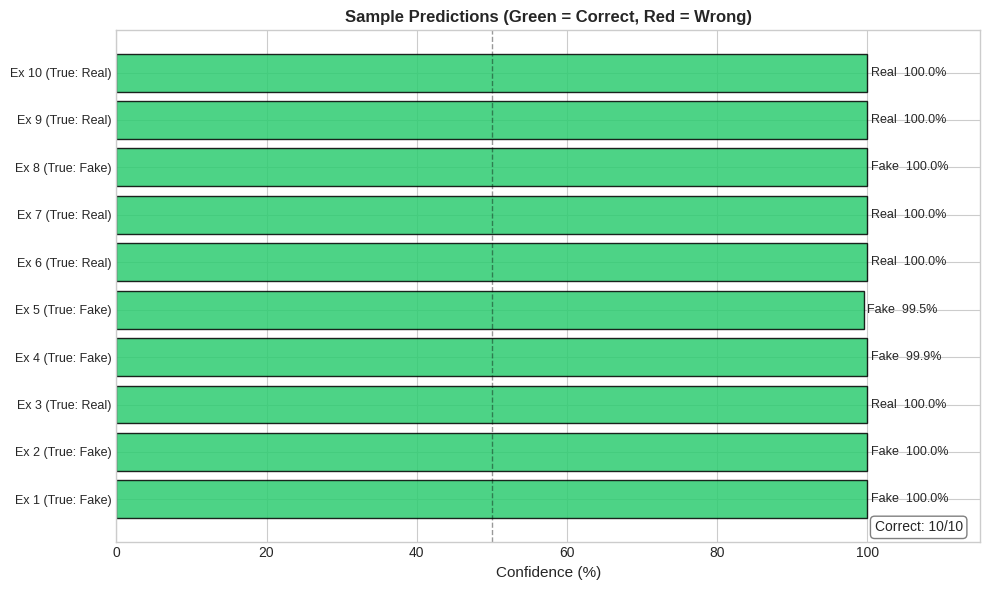

In [ ]:
# Model Sample Prediction

sample_size = 10
sample_indices = random.sample(range(len(test_dataset)), sample_size)

print(f"Sample Predictions ({sample_size} random examples from test set)")

model_BERT.eval()

labels_true, labels_pred, confidences, texts = [], [], [], []

for idx in sample_indices:
    text = test_dataset[idx]['text']
    true_label = test_dataset[idx]['label']

    encoded = tokenizer_BERT(
            text,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors='pt')

    with torch.no_grad():
        outputs = model_BERT(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device)
        )
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
        pred  = int(np.argmax(probs))

    labels_true.append(true_label)
    labels_pred.append(pred)
    confidences.append(probs[pred] * 100)
    texts.append(text[:60] + '...')

# Display Predictions
bar_colors = ['#2ecc71' if p == t else '#e74c3c'
        for p, t in zip(labels_pred, labels_true)]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(sample_size), confidences, color=bar_colors,
               alpha=0.85, edgecolor='black')

# Add predicted label and confidence on each bar
for i, (bar, pred, conf) in enumerate(zip(bars, labels_pred, confidences)):
    ax.text(conf + 0.5, i, f"{id2label[pred]}  {conf:.1f}%",
            va='center', fontsize=9)

ax.set_yticks(range(sample_size))
ax.set_yticklabels([f"Ex {i+1} (True: {id2label[t]})"
                    for i, t in enumerate(labels_true)], fontsize=9)
ax.set_xlabel('Confidence (%)', fontsize=11)
ax.set_title('Sample Predictions (Green = Correct, Red = Wrong)',
             fontsize=12, fontweight='bold')
ax.set_xlim([0, 115])
ax.axvline(x=50, color='black', linestyle='--', linewidth=1, alpha=0.4)

correct = sum(p == t for p, t in zip(labels_pred, labels_true))
ax.text(0.98, 0.02, f"Correct: {correct}/{sample_size}",
        transform=ax.transAxes, fontsize=10, ha='right',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

# BERT Custom Input

In [ ]:
# Inference on Custom Input
def predict_custom(text, model, tokenizer, device):
   # Set model to evaluation mode
    model.eval()

    # Tokenise input text
    encoded = tokenizer(
        text,
        truncation=True, # Ensures max length is respected
        padding=True, # Ensures consistent tensor shape
        max_length=512, # Maximum length of text
        return_tensors='pt' # Returns PyTorch tensors
    )

    with torch.no_grad(): # Disable gradient calculation for inference
        # Forward pass through the model
        outputs = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device)
        )

         # Convert logits to probabilities
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

        # Get predicted class
        pred  = int(np.argmax(probs))

    return pred, probs

# Test with Custom Headlines / Articles
custom_inputs = [
    "Manchester Metropolitan University is a university in Manchester England",
    "Scientists discover new vaccine that eliminates all known diseases overnight",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns",
    "Government puts fluoride in water to control the population and leaked documents reveal",
    "Apple announces new iPhone with record-breaking battery life",
    "The stock market is expected to rise next quarter due to economic growth",
    "Breaking news: Major earthquake strikes downtown area",
    "New technology is revolutionizing the healthcare industry",
    "The local sports team wins the championship after a thrilling match",
    "Scientists discover a new planet that could support life",
    "Local man wins lottery and buys new mansion",
    "Study reveals that drinking coffee can actually improve your memory",
    "New research shows that climate change is accelerating at an alarming rate",
    "Celebrity couple announces their divorce after 10 years of marriage",
    "Unbelievable as man claims to have spoken with aliens during a camping trip"
]

# Displays text
print("Custom Input Predictions")

# Loop through each example and perform inference
for i, text in enumerate(custom_inputs):
  # Get prediction and probabilities
    pred, probs = predict_custom(text, model_BERT, tokenizer_BERT, device)

    # Confidence score of predicted class
    confidence = probs[pred] * 100

    # Convert label index to readable class name
    label = id2label[pred]

    # Colour formatting for output
    color = '\033[92m' if pred == 1 else '\033[91m'  # Green = Real (1), Red = Fake (0)
    reset = '\033[0m'

    # Print probability distribution
    print(f"{color}Example {i+1}: {label} ({confidence:.1f}% confidence){reset}")
    print(f"  Text : {text}")

    # Print probability distribution
    print(f"  Fake: {probs[0]*100:.1f}%  |  Real : {probs[1]*100:.1f}%")

Custom Input Predictions
Example 1: Fake (72.8% confidence)
  Text : Manchester Metropolitan University is a university in Manchester England
  Fake: 72.8%  |  Real : 27.2%
Example 2: Real (90.5% confidence)
  Text : Scientists discover new vaccine that eliminates all known diseases overnight
  Fake: 9.5%  |  Real : 90.5%
Example 3: Real (98.5% confidence)
  Text : Federal Reserve raises interest rates by 0.25% amid inflation concerns
  Fake: 1.5%  |  Real : 98.5%
Example 4: Real (97.8% confidence)
  Text : Government puts fluoride in water to control the population and leaked documents reveal
  Fake: 2.2%  |  Real : 97.8%
Example 5: Real (99.1% confidence)
  Text : Apple announces new iPhone with record-breaking battery life
  Fake: 0.9%  |  Real : 99.1%
Example 6: Real (99.5% confidence)
  Text : The stock market is expected to rise next quarter due to economic growth
  Fake: 0.5%  |  Real : 99.5%
Example 7: Real (99.4% confidence)
  Text : Breaking news: Major earthquake strikes dow

# Llama Registry

In [ ]:
# Load Llama model

# Stores configuration for model
Model_Llama = {
    'llama': {
        'model_id'   : 'meta-llama/Llama-3.2-3B', # Hugging Face model identifier
        'save_name'  : 'llama3b',  # Short name for saving/loading locally
        'padding'    : 'left',   # Padding strategy
    },
}

 # Select the llama config
cfg_Llama = Model_Llama['llama']

# Extract the model ID from the selected configuration
model_id = cfg_Llama['model_id']

# Print the currently active model ID
print(f"Active model: {model_id}")

Active model: meta-llama/Llama-3.2-3B


# Llama Tokenisation

In [ ]:
# Model Tokenisation

# Print to screen
print(f"Loading tokeniser for {model_id}...")

# Load tokeniser from Hugging Facemodel
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

# Ensure the tokenizer has a padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Use end-of-sequence token as padding
    tokenizer.pad_token_id = tokenizer.eos_token_id  # Set corresponding token ID

# Set padding side
tokenizer.padding_side = cfg_Llama['padding'] # Left-padding

# Debug info
print(f"Vocab size: {tokenizer.vocab_size}") # Total number of tokens in vocabulary
print(f"Pad token: {tokenizer.pad_token!r}") # Displays padding token
print(f"Padding side: {tokenizer.padding_side}") # Shows whether padding is left or right
print(f"EOS token: {tokenizer.eos_token!r}") # End-of-sequence token

Loading tokeniser for meta-llama/Llama-3.2-3B...
Vocab size: 128000
Pad token: '<|end_of_text|>'
Padding side: left
EOS token: '<|end_of_text|>'


# Llama Dataset Formatting

In [ ]:
# Prompt formatting

# Function to format a single example into an instruction style prompt
def format_instruction_prompt(example, include_label=True):
    # Follows the pattern:
    # Task: [description]

    # Input:
    #[content]

    # Output: [label]

    text  = example['text'][:1500]    # Truncate text to avoid exceeding model context length
    label = id2label[example['label']] # Convert numeric label to string

    # Build the instruction style prompt
    prompt = (
        f"### Task: Classify the following news article as Real or Fake.\n\n"
        f"### Article:\n{text}\n\n"
        f"### Label:"
    )
    # Include the correct label at the end during training
    if include_label:
        return prompt + f" {label}"   # Full prompt + answer for training
    return prompt                      # Return only prompt for inference

# Add formatted text column
def add_formatted_text(example):
    return {"formatted_text": format_instruction_prompt(example, include_label=True)}

print("Formatting datasets...")
train_data = train_dataset.map(add_formatted_text, desc="Formatting train")
val_data = val_dataset.map(add_formatted_text, desc="Formatting val")

# Summary of tokenization
print(f"Train: {len(train_data)} samples")  # Number of training samples
print(f"Val: {len(val_data)} samples") # Number of validation samples

# Check sample
print(f"\nSample prompt:")
print(train_data[0]['formatted_text'][:300])

Formatting datasets...


Formatting train:   0%|          | 0/24126 [00:00<?, ? examples/s]

Formatting val:   0%|          | 0/8085 [00:00<?, ? examples/s]

Train: 24126 samples
Val: 8085 samples

Sample prompt:
### Task: Classify the following news article as Real or Fake.

### Article:
top republican ryan distances himself from trump white house bid. washington reuters - paul ryan, the top republican in the u.s. congress, took the extraordinary step on monday of distancing himself from donald trump, stirr


# QLoRA Configuration

In [ ]:
# QLoRA 4-bit quantisation config

# Create a BitsAndBytes configuration for efficient 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # Load model weights in 4-bit precision
    bnb_4bit_use_double_quant=True, # Enable nested quantisation
    bnb_4bit_quant_type="nf4", # Use NormalFloat4 quantisation
    bnb_4bit_compute_dtype=torch.bfloat16 # Use bfloat16 for computation
)

# Verification output
print("BitsAndBytes config:")
print(f"  load_in_4bit: True")  # Confirms 4-bit loading is enabled
print(f"  use_double_quant: True") # Confirms nested quantisation is active
print(f"  quant_type: nf4") # Shows chosen quantisation type
print(f"  compute_dtype: bfloat16") # Shows computation precision

BitsAndBytes config:
  load_in_4bit: True
  use_double_quant: True
  quant_type: nf4
  compute_dtype: bfloat16


# Llama Base Model

In [ ]:
# Load Llama base model

# Print to screen
print(f"Loading {model_id} in 4-bit...")

# Load the base causal language model with 4-bit quantisation
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config, # Apply QLoRA 4-bit quantisation settings
    trust_remote_code=True, # Allow custom model code from Hugging Face repo
    device_map="auto",  # Automatically distribute model across available devices
)

# Ensure padding token is correctly set
base_model.config.pad_token_id = tokenizer.pad_token_id

# Disable caching for training
base_model.config.use_cache = False

print(f"Base model loaded")

# Enable gradient checkpointing to reduce memory usage
base_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# Check how many parameters are trainable BEFORE adding LoRA adapters
print(f"Trainable params before LoRA: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")

Loading meta-llama/Llama-3.2-3B in 4-bit...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Base model loaded
Trainable params before LoRA: 394,177,536


# LoRA Configuration

In [ ]:
# LoRA configuration

lora_config = LoraConfig(
    r=16,  # Rank
    lora_alpha=32,  # Scaling factor
    lora_dropout=0.05, # Dropout for regularization
    bias="none",   # No bias adaptation
    task_type='CAUSAL_LM',  # Language modeling task
    target_modules=[   # Attention + MLP layers
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj"   # Feed-forward
    ],
)

print("\nLoRA config ready for training!")


LoRA config ready for training!


# Llama Training

In [ ]:
# Model Training

# Fix GPU memory fragmentation
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True' # Improves allocator behavior for large models

# Forces synchronous GPU execution
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Safer GPU allocation

# Memory cleanup before training
print("\nCleaning GPU memory...")
torch.cuda.empty_cache() # Clear unused GPU memory
torch.cuda.synchronize() # Wait for all GPU operations to finish
gc.collect() # Run garbage collection

# Check GPU memory status
free_memory = torch.cuda.mem_get_info()[0] / 1e9
total_memory = torch.cuda.mem_get_info()[1] / 1e9

print(f"Memory cleared!")
print(f"  Free: {free_memory:.1f} GB")
print(f"  Total: {total_memory:.1f} GB")

# Training parameters
NUM_EPOCHS = 5
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
MAX_TOKENS = 512
LEARNING_RATE = 2e-4

# Training configuration with SFTTRAINER
training_args = SFTConfig(
    output_dir=f'./{cfg_Llama["save_name"]}_checkpoint', # Directory to save checkpoints
    per_device_train_batch_size=BATCH_SIZE,  # Train batch size per GPU
    per_device_eval_batch_size=BATCH_SIZE, # Evaluation batch size per GPU
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS, # Accumulate gradients to simulate larger batch size
    learning_rate=LEARNING_RATE,  # Optimizer learning rate
    num_train_epochs=NUM_EPOCHS, # Number of full passes over dataset
    logging_steps=10, # Log training progress every N steps
    eval_strategy='epoch', # Evaluate after each epoch
    save_strategy='epoch', # Save after each epoch
    load_best_model_at_end=True, # Restore best model after training
    metric_for_best_model='eval_loss', # Metric used to determine "best" model
    greater_is_better=False,  # Lower loss = better
    bf16=True,  # bfloat16 for faster training
    dataset_text_field='formatted_text', # Field used by trainer
    max_length=512, # Maximum token sequence length for SFTTrainer tokenization
    packing=False, # Do not pack multiple samples into one sequence
    dataloader_pin_memory=True,  # Faster GPU data transfer
    dataloader_num_workers=0, # Disable multiprocessing
    remove_unused_columns=True, # Clean up unused columns
    optim="paged_adamw_32bit", # Optimizer
    weight_decay=0.01, # Regularization
    gradient_checkpointing=True, # Saves memory
    torch_empty_cache_steps=25, # Periodically clear GPU cache
)

# Print training configuration
print("Training configuration:")
print(f"  Output dir: {training_args.output_dir}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Total steps: ~{len(train_data) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS) * NUM_EPOCHS}")

# Initialize trainer
print("\nInitializing SFTTrainer...")

# Early stopping
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,  # Stop if no improvement for 2 evaluations
    early_stopping_threshold=0.001,  # Minimum improvement needed to continue
)

# Create trainer instance
trainer = SFTTrainer(
    model=base_model, # Base LLaMA model
    train_dataset=train_data, # Tokenized training dataset
    eval_dataset=val_data, # Tokenized validation dataset
    args=training_args, # Training configuration
    peft_config=lora_config, # LoRA configuration
    processing_class=tokenizer, # Tokenizer for decoding/logging
    callbacks=[early_stopping], # Early stopping
)

# Print dataset sample size
print(f"\nTrainer initialized")
print(f"  Train samples: {len(train_data)}")
print(f"  Val samples: {len(val_data)}")
print(f"Ready to train!")

# Start training
print("\nStarting training...\n")
print("=" * 70)

# Train the model
train_result = trainer.train()

print("=" * 70)

# Training results
print(f"\nTraining complete!")
print(f"\nResults:")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Training time: {train_result.metrics.get('train_runtime', 0)/60:.1f} minutes")

# Save trained LoRA adapter
save_dir_Llama = f'./{cfg_Llama["save_name"]}_lora_adapter'

print(f"Saving trained adapter to {save_dir_Llama}...")

# Save only LoRA adapter weights
trainer.model.save_pretrained(save_dir_Llama)

# Save tokenizer for reuse during inference
tokenizer.save_pretrained(save_dir_Llama)

# Save training config and label mappings
eval_config = {
    'model_name': cfg_Llama["model_id"],
    'save_name': cfg_Llama["save_name"],
    'id2label': id2label,
    'label2id': label2id,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'max_tokens': MAX_TOKENS,
    'best_eval_loss': trainer.state.best_metric
}

with open(f'{save_dir_Llama}/eval_config.json', 'w') as f:
    json.dump(eval_config, f, indent=2)

logs = trainer.state.log_history
with open(f'{save_dir_Llama}/training_logs.json', 'w') as f:
    json.dump(logs, f)
print(f"Saved {len(logs)} log entries")

print(f"\nModel saved!")
print(f"  LoRA adapter: {save_dir_Llama}")
print(f"  Tokenizer: {save_dir_Llama}")
print(f"Saved model, tokenizer, and config to {save_dir_Llama}")


Cleaning GPU memory...
Memory cleared!
  Free: 74.9 GB
  Total: 85.1 GB
Training configuration:
  Output dir: ./llama3b_checkpoint
  Epochs: 5
  Batch size: 8
  Learning rate: 0.0002
  Gradient accumulation: 4
  Total steps: ~3765

Initializing SFTTrainer...


Adding EOS to train dataset:   0%|          | 0/24126 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/24126 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/8085 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/8085 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.



Trainer initialized
  Train samples: 24126
  Val samples: 8085
Ready to train!

Starting training...



Epoch,Training Loss,Validation Loss
1,2.066197,2.034744
2,1.930147,2.023790
3,1.800487,2.041991
4,1.731308,2.073339



Training complete!

Results:
  Training loss: 1.8824
  Training time: 138.8 minutes
Saving trained adapter to ./llama3b_lora_adapter...
Saved 306 log entries

Model saved!
  LoRA adapter: ./llama3b_lora_adapter
  Tokenizer: ./llama3b_lora_adapter
Saved model, tokenizer, and config to ./llama3b_lora_adapter


# Llama Training and Validation Visualisation

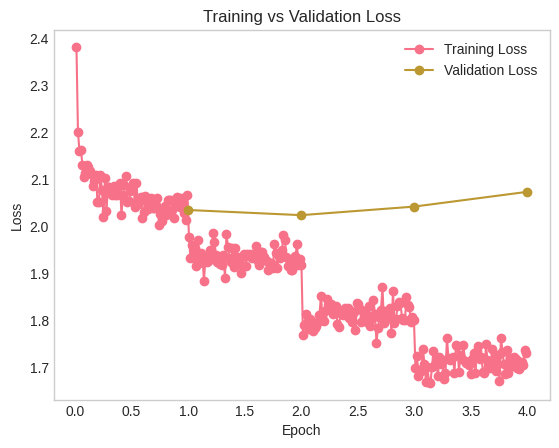

In [ ]:
# Loss Curves Visualisation

# Get full training log history from trainer
logs = trainer.state.log_history

# Initialize lists to store extracted values
train_losses = []   # Stores training loss values
eval_losses = []    # Stores validation (evaluation) loss values
epochs = []         # Stores epoch numbers for training loss

# Loop through all log entries
for log in logs:

    # Extract training loss
    if "loss" in log and "epoch" in log:
        train_losses.append(log["loss"])     # Save training loss
        epochs.append(log["epoch"])          # Save corresponding epoch

    # Extract validation loss
    if "eval_loss" in log:
        eval_losses.append(log["eval_loss"]) # Save validation loss

# Create epoch indices for validation loss
eval_epochs = list(range(1, len(eval_losses) + 1))


# Plot
plt.figure()

# Plot training loss curve
plt.plot(epochs[:len(train_losses)], train_losses, marker='o', label="Training Loss")

# Plot validation loss curve
plt.plot(eval_epochs, eval_losses, marker='o', label="Validation Loss")

# Label axes
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add title
plt.title("Training vs Validation Loss")

# Add legend to distinguish lines
plt.legend()

# Add grid for better readability
plt.grid()

# Save plot to output directory
plt.savefig(f'{training_args.output_dir}/loss_curve.png')

# Display the plot
plt.show()

# Llama Label Extraction

In [ ]:
# Label Extraction Function

# Extract Real or Fake from generated text
def extract_label_from_output(text):
    # Convert text to lowercase for case-insensitive matching
    text = text.lower()

    # Remove thinking tags if present
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)

    # Check for keywords in the cleaned text
    if re.search(r'\breal\b', text):
      return 1 # Label for Real
    elif re.search(r'\bfake\b', text):
        return 0  # Label for Fake
    else:
        return -1  # Return -1 if label cannot be determined

# Test label extraction
test_cases = [
    ("The answer is Real", 1),
    ("This is Fake news", 0),
    ("Unknown output", -1),
]

print("Testing label extraction:")
# Run tests and compare results
for text, expected in test_cases:
    result = extract_label_from_output(text)

    # Check if result matches expected output
    status = "✓" if result == expected else "✗"
    print(f"  {status} '{text}' = {result}")

Testing label extraction:
  ✓ 'The answer is Real' = 1
  ✓ 'This is Fake news' = 0
  ✓ 'Unknown output' = -1


# Llama Testing

In [ ]:
# Batch prediction

# Maximum number of tokens the model generates for the label
MAX_NEW_TOKENS = 5

# Function to run batch inference on multiple texts
def predict_batch(base_model, tokenizer, texts, batch_size=16):
    base_model.eval() # Set model to evaluation mode
    predictions = [] # Store predicted labels

    # Process texts in batches
    for i in tqdm(range(0, len(texts), batch_size), desc='Inference'):
        batch_texts = texts[i:i+batch_size]

        # Format prompts WITHOUT labels
        prompts = [
            format_instruction_prompt(
                {'text': t, 'label': 0}, # Dummy label
                include_label=False # Exclude label so model predicts it
        )
            for t in batch_texts
        ]

        # Tokenize batch
        inputs = tokenizer(
            prompts,
            return_tensors='pt', # Return PyTorch tensors
            truncation=True,  # Truncate long inputs
            max_length=512, # Ensure consistent max length
            padding=True # Pad batch to same length
        ).to(device) # Move inputs to GPU/CPU

        # Generate predictions
        with torch.no_grad(): # Disable gradient computation
            outputs = base_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS, # Only generate short label output
                do_sample=False, # Deterministic
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Extract labels
        for j, output in enumerate(outputs):
            #input_len = inputs['input_ids'].shape[1]
            input_len = (inputs['attention_mask'][j] == 1).sum()# Length of input prompt
            new_tokens = output[input_len:] # Extract only newly generated tokens
            decoded = tokenizer.decode(new_tokens, skip_special_tokens=True).strip() # Decode tokens to text
            label = extract_label_from_output(decoded) # Convert generated text into label
            predictions.append(label)

    return predictions

# Ready for inference
print("Prediction function ready")

Prediction function ready


Running inference on test set...



Inference:   0%|          | 0/507 [00:00<?, ?it/s]



RESULTS (meta-llama/Llama-3.2-3B)

Prediction summary:
  Total predictions: 8102
  Valid predictions: 8101
  Unparseable: 1 (0.0%)

Metrics:
  Accuracy: 0.9400 (94.00%)
  F1 (Macro): 0.9394 (93.94%)
  F1 (Weighted): 0.9398 (93.98%)
  Recall: 0.9374 (93.74%)
  Precision: 0.9437 (94.37%)
  ROC AUC Score: 0.9374

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9708    0.8984    0.9332      3781
        Real     0.9166    0.9764    0.9455      4320

    accuracy                         0.9400      8101
   macro avg     0.9437    0.9374    0.9394      8101
weighted avg     0.9419    0.9400    0.9398      8101



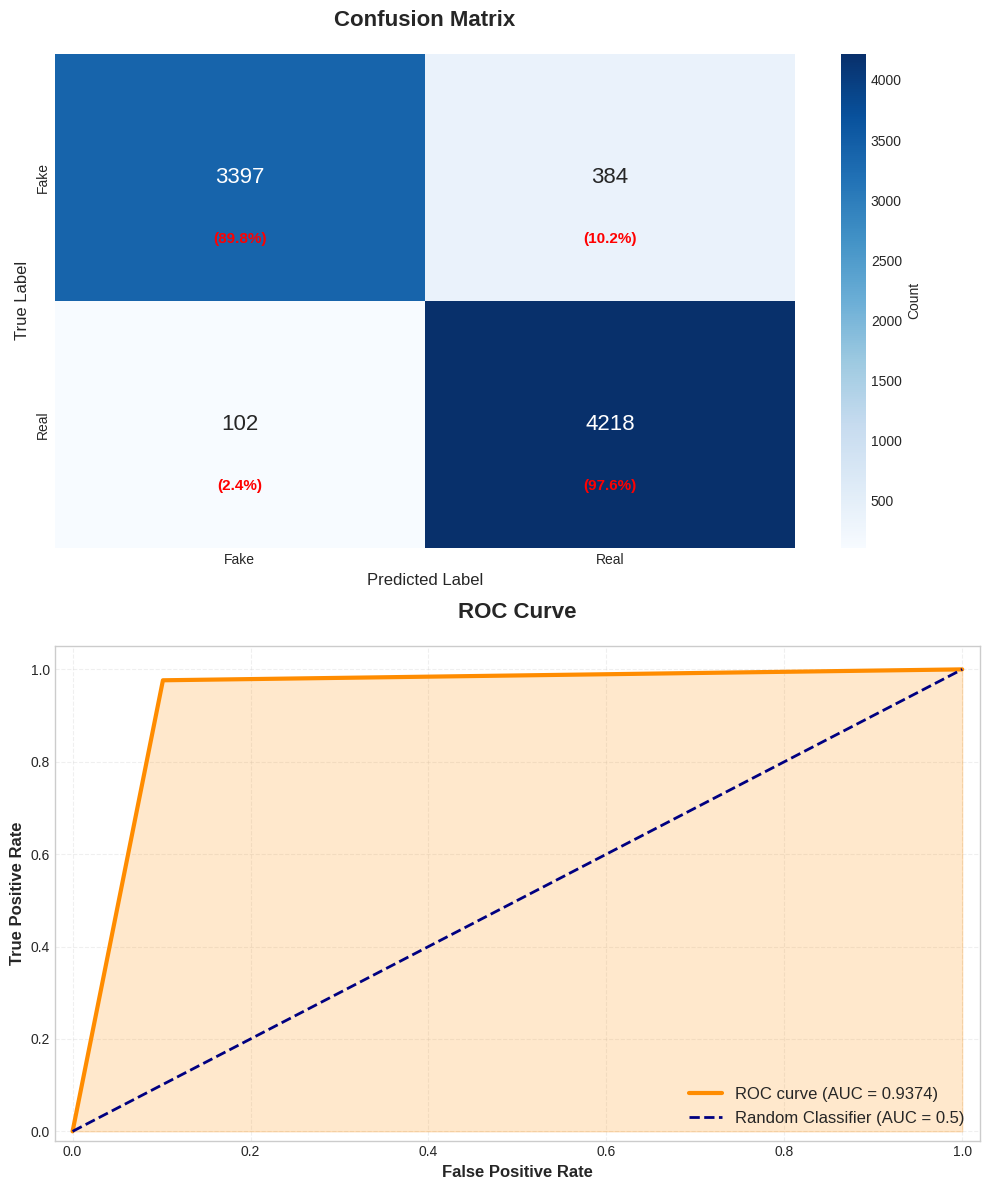


Evaluation plots saved as 'evaluation_results.png'

CONFUSION MATRIX BREAKDOWN:

True Negatives (Fake predicted as Fake): 3397
   Model correctly identified 3397 fake articles

False Positives (Fake predicted as Real): 384
   Model missed 384 fake articles (called them real)
   False positive rate: 10.16%

False Negatives (Real predicted as Fake): 102
   Model incorrectly flagged 102 real articles as fake
   False negative rate: 2.36%

True Positives (Real predicted as Real): 4218
   Model correctly identified 4218 real articles

ROC AUC INTERPRETATION:

ROC AUC Score: 0.9374
   1.0 = Perfect classifier
   0.9+ = Excellent
   0.8-0.9 = Good
   0.7-0.8 = Fair
   0.5-0.7 = Poor
   0.5 = Random guess

 Model has EXCELLENT discrimination ability!

SUMMARY METRICS TABLE:

Metric                    Score           Interpretation                
Accuracy                  0.9400          Correct predictions
Precision                 0.9437          Of positive predictions, how many correct
Re

In [ ]:
# Evaluation on test dataset

print("Running inference on test set...\n")

# Extract test texts and true labels
test_texts = test_dataset['text']
test_labels = test_dataset['label']

# Run batch prediction
predictions = predict_batch(trainer.model, tokenizer, test_texts, batch_size=16)

# Check for unrecognised outputs
unrecognised = sum(1 for p in predictions if p == -1)
if unrecognised > 0:
    print(f"\nWarning: {unrecognised}/{len(predictions)} unrecognised outputs")


# Filter valid predictions
valid_preds = [(p, l) for p, l in zip(predictions, test_labels) if p != -1] # Remove predictions th

# Separate predictions and labels
pred_list = [v[0] for v in valid_preds]
label_list = [v[1] for v in valid_preds]
unparseable = len(predictions) - len(valid_preds) # Count unparseable outputs

# Print prediction summary
print(f"\nRESULTS ({model_id})")

print(f"\nPrediction summary:")
print(f"  Total predictions: {len(predictions)}")
print(f"  Valid predictions: {len(pred_list)}")
print(f"  Unparseable: {unparseable} ({unparseable/len(predictions)*100:.1f}%)")

# Compute evaluation metrics
if pred_list:
    accuracy = accuracy_score(label_list, pred_list)
    f1_macro = f1_score(label_list, pred_list, average='macro')
    f1_weighted = f1_score(label_list, pred_list, average='weighted')
    recall = recall_score(label_list, pred_list, average='macro')
    precision = precision_score(label_list, pred_list, average='macro')

    print(f"\nMetrics:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  F1 (Macro): {f1_macro:.4f} ({f1_macro*100:.2f}%)")
    print(f"  F1 (Weighted): {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
    print(f"  Recall: {recall:.4f} ({recall*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")

    # ROC-AUC score
    try:
        roc_auc = roc_auc_score(label_list, pred_list)
        print(f"  ROC AUC Score: {roc_auc:.4f}")
    except Exception as e:
        print(f"  ROC AUC Score: Could not calculate ({str(e)})")
        roc_auc = None

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(label_list, pred_list,
                               target_names=['Fake', 'Real'], digits=4))

    # Confusion matrix and ROC-AUC Visualisation
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    # Confusion matrix
    cm = confusion_matrix(label_list, pred_list)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'],
                ax=axes[0],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 16})

    axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)

    # Add percentages values inside confusion matrix
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j + 0.5, i + 0.75, f'({cm_percent[i, j]:.1f}%)',
                        ha='center', va='center', fontsize=11, color='red', fontweight='bold')

    # ROC curve
    fpr, tpr, thresholds = roc_curve(label_list, pred_list)
    roc_auc_calc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=3,
                label=f'ROC curve (AUC = {roc_auc_calc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                 label='Random Classifier (AUC = 0.5)')  # Random baseline
    axes[1].set_xlim([-0.02, 1.02])
    axes[1].set_ylim([-0.02, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    axes[1].set_title('ROC Curve', fontsize=16, fontweight='bold', pad=20)
    axes[1].legend(loc="lower right", fontsize=12, framealpha=0.95)
    axes[1].grid(True, alpha=0.3, linestyle='--')

    # Fill area under curve
    axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')

    # Adjust spacing between subplots
    plt.tight_layout()

    # Save figure
    plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nEvaluation plots saved as 'evaluation_results.png'")

    # Confusion matrix interpretation
    print("\nCONFUSION MATRIX BREAKDOWN:")

    tn, fp, fn, tp = cm.ravel()

    print(f"\nTrue Negatives (Fake predicted as Fake): {tn}")
    print(f"   Model correctly identified {tn} fake articles")

    print(f"\nFalse Positives (Fake predicted as Real): {fp}")
    print(f"   Model missed {fp} fake articles (called them real)")
    print(f"   False positive rate: {fp/(fp+tn)*100:.2f}%")

    print(f"\nFalse Negatives (Real predicted as Fake): {fn}")
    print(f"   Model incorrectly flagged {fn} real articles as fake")
    print(f"   False negative rate: {fn/(fn+tp)*100:.2f}%")

    print(f"\nTrue Positives (Real predicted as Real): {tp}")
    print(f"   Model correctly identified {tp} real articles")

    # ROC interpretation
    print("\nROC AUC INTERPRETATION:")
    print(f"\nROC AUC Score: {roc_auc_calc:.4f}")
    print("   1.0 = Perfect classifier")
    print("   0.9+ = Excellent")
    print("   0.8-0.9 = Good")
    print("   0.7-0.8 = Fair")
    print("   0.5-0.7 = Poor")
    print("   0.5 = Random guess")

    if roc_auc_calc >= 0.9:
        print(f"\n Model has EXCELLENT discrimination ability!")
    elif roc_auc_calc >= 0.8:
        print(f"\n Model has GOOD discrimination ability!")
    elif roc_auc_calc >= 0.7:
        print(f"\n Model has FAIR discrimination ability!")
    else:
        print(f"\n Model has LIMITED discrimination ability!")

    # Summary statistics table
    print("\nSUMMARY METRICS TABLE:")
    print(f"\n{'Metric':<25} {'Score':<15} {'Interpretation':<30}")
    print(f"{'Accuracy':<25} {accuracy:<15.4f} Correct predictions")
    print(f"{'Precision':<25} {precision:<15.4f} Of positive predictions, how many correct")
    print(f"{'Recall':<25} {recall:<15.4f} Of actual positives, how many found")
    print(f"{'F1 (Weighted)':<25} {f1_weighted:<15.4f} Harmonic mean (weighted)")
    print(f"{'F1 (Macro)':<25} {f1_macro:<15.4f} Harmonic mean (unweighted)")
    print(f"{'ROC AUC':<25} {roc_auc_calc:<15.4f} Area under ROC curve")
else:
    # No valid predictions case
    print(f"\nNo valid predictions! Check prompt format.")

# Store results
llama_results = {}

llama_results['gonzalo'] = {
    'accuracy': accuracy,
    'macro_f1': f1_macro
}

# Llama Prediction

In [ ]:
# Model Sample Prediction

# Pick 10 random test samples
sample_indices = random.sample(range(len(test_dataset)), 10)
sample_texts = [test_dataset[i]['text'] for i in sample_indices]
sample_labels = [test_dataset[i]['label'] for i in sample_indices]

# Run predictions
sample_preds = predict_batch(trainer.model, tokenizer, sample_texts, batch_size=4)

# Display results
print(f"{'#':<4} {'True':<8} {'Pred':<8} {'Match':<8} {'Generated Text'}")
print("-" * 60)

for i, (true, pred) in enumerate(zip(sample_labels, sample_preds)):
    true_str = id2label[true]
    pred_str = id2label[pred] if pred != -1 else "???"
    match = "✓" if true == pred else "✗"
    print(f"{i+1:<4} {true_str:<8} {pred_str:<8} {match}")

# Summary
correct = sum(1 for t, p in zip(sample_labels, sample_preds) if t == p)
print(f"\nAccuracy: {correct}/10 ({correct/10*100:.0f}%)")

Inference:   0%|          | 0/3 [00:00<?, ?it/s]

#    True     Pred     Match    Generated Text
------------------------------------------------------------
1    Real     Real     ✓
2    Fake     Fake     ✓
3    Real     Real     ✓
4    Fake     Real     ✗
5    Fake     Fake     ✓
6    Real     Real     ✓
7    Real     Real     ✓
8    Real     Real     ✓
9    Fake     Fake     ✓
10   Fake     Fake     ✓

Accuracy: 9/10 (90%)


# Llama Custom Inference

In [ ]:
# Custom inference examples

custom_inputs = [
    "Manchester Metropolitan University is a university in Manchester England",
    "Scientists discover new vaccine that eliminates all known diseases overnight",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns",
    "Government puts fluoride in water to control the population and leaked documents reveal",
    "Apple announces new iPhone with record-breaking battery life",
    "The stock market is expected to rise next quarter due to economic growth",
    "Breaking news: Major earthquake strikes downtown area",
    "New technology is revolutionizing the healthcare industry",
    "The local sports team wins the championship after a thrilling match",
    "Scientists discover a new planet that could support life",
    "Local man wins lottery and buys new mansion",
    "Study reveals that drinking coffee can actually improve your memory",
    "New research shows that climate change is accelerating at an alarming rate",
    "Celebrity couple announces their divorce after 10 years of marriage",
    "Unbelievable as man claims to have spoken with aliens during a camping trip"
]

print("Testing on custom examples:\n")

custom_preds = predict_batch(base_model, tokenizer, custom_inputs, batch_size=2)

print(f"\nResults:")
for text, pred in zip(custom_inputs, custom_preds):
    if pred == -1:
        label = "UNPARSEABLE"
    else:
        label = id2label[pred]
    print(f"\n  [{label}] {text[:80]}...")

Testing on custom examples:



Inference:   0%|          | 0/8 [00:00<?, ?it/s]


Results:

  [Fake] Manchester Metropolitan University is a university in Manchester England...

  [Fake] Scientists discover new vaccine that eliminates all known diseases overnight...

  [Fake] Federal Reserve raises interest rates by 0.25% amid inflation concerns...

  [Fake] Government puts fluoride in water to control the population and leaked documents...

  [Fake] Apple announces new iPhone with record-breaking battery life...

  [Fake] The stock market is expected to rise next quarter due to economic growth...

  [Fake] Breaking news: Major earthquake strikes downtown area...

  [Fake] New technology is revolutionizing the healthcare industry...

  [Fake] The local sports team wins the championship after a thrilling match...

  [Fake] Scientists discover a new planet that could support life...

  [Fake] Local man wins lottery and buys new mansion...

  [Fake] Study reveals that drinking coffee can actually improve your memory...

  [Fake] New research shows that climate change 

# Qwen Registry

In [ ]:
# Load Qwen model

Model_Qwen = {
    'qwen': {
        'model_id'   : 'Qwen/Qwen2.5-3B', # Hugging Face model identifier
        'save_name'  : 'qwen3b', # Short name for saving/loading locally
        'padding'    : 'left', # Padding strategy
    },
}

 # Select the Qwen config
cfg_Qwen = Model_Qwen['qwen']

# Extract the model ID from the selected configuration
model_id = cfg_Qwen['model_id']

# Print the currently active model ID
print(f"Active model: {model_id}")

Active model: Qwen/Qwen2.5-3B


# Qwen Tokenization

In [ ]:
# Model Tokenization

# Print to screen
print(f"Loading tokenizer for {model_id}...")

# Load tokenizer from Hugging Facemodel
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

# Ensure the tokenizer has a padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Use end-of-sequence token as padding
    tokenizer.pad_token_id = tokenizer.eos_token_id  # Set corresponding token ID

# Set padding side
tokenizer.padding_side = cfg_Qwen['padding']

# Debug info
print(f"Vocab size: {tokenizer.vocab_size}") # Total number of tokens in vocabulary
print(f"Pad token: {tokenizer.pad_token!r}") # Displays padding token
print(f"Padding side: {tokenizer.padding_side}") # Shows whether padding is left or right
print(f"EOS token: {tokenizer.eos_token!r}") # End-of-sequence token

Loading tokenizer for Qwen/Qwen2.5-3B...


config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 151643
Pad token: '<|endoftext|>'
Padding side: left
EOS token: '<|endoftext|>'


# Qwen Dataset Formatting

In [ ]:
# Prompt formatting

# Function to format a single example into an instruction style prompt
def format_instruction_prompt(example, include_label=True):
    # Follows the pattern:
    # Task: [description]

    # Input:
    #[content]

    # Output: [label]

    text  = example['text'][:1500]    # Truncate text to avoid exceeding model context length
    label = id2label[example['label']] # Convert numeric label to string

    # Build the instruction style prompt
    prompt = (
        f"### Task: Classify the following news article as Real or Fake.\n\n"
        f"### Article:\n{text}\n\n"
        f"### Label:"
    )
    # Include the correct label at the end during training
    if include_label:
        return prompt + f" {label}"   # Full prompt + answer for training
    return prompt                      # Return only prompt for inference


# Add formatted text column
def add_formatted_text(example):
    return {"formatted_text": format_instruction_prompt(example, include_label=True)}

print("Formatting datasets...")
train_data = train_dataset.map(add_formatted_text, desc="Formatting train")
val_data = val_dataset.map(add_formatted_text, desc="Formatting val")

print(f"Train: {len(train_data)} samples")
print(f"Val: {len(val_data)} samples")

# Check sample
print(f"\nSample prompt:")
print(train_data[0]['formatted_text'][:300])

Formatting datasets...


Formatting train:   0%|          | 0/24126 [00:00<?, ? examples/s]

Formatting val:   0%|          | 0/8085 [00:00<?, ? examples/s]

Train: 24126 samples
Val: 8085 samples

Sample prompt:
### Task: Classify the following news article as Real or Fake.

### Article:
top republican ryan distances himself from trump white house bid. washington reuters - paul ryan, the top republican in the u.s. congress, took the extraordinary step on monday of distancing himself from donald trump, stirr


# QLoRA Configuration

In [ ]:
# QLoRA 4-bit quantisation config

# Create a BitsAndBytes configuration for efficient 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # Load model weights in 4-bit precision
    bnb_4bit_use_double_quant=True, # Enable nested quantisation
    bnb_4bit_quant_type="nf4", # Use NormalFloat4 quantisation
    bnb_4bit_compute_dtype=torch.bfloat16 # Use bfloat16 for computation
)

# Verification output
print("BitsAndBytes config:")
print(f"  load_in_4bit: True")  # Confirms 4-bit loading is enabled
print(f"  use_double_quant: True") # Confirms nested quantisation is active
print(f"  quant_type: nf4") # Shows chosen quantisation type
print(f"  compute_dtype: bfloat16") # Shows computation precision

BitsAndBytes config:
  load_in_4bit: True
  use_double_quant: True
  quant_type: nf4
  compute_dtype: bfloat16


# Qwen Base Model

In [ ]:
# Load Qwen base model

# Print to screen
print(f"Loading {model_id} in 4-bit...")

# Load the base causal language model with 4-bit quantisation
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config, # Apply QLoRA 4-bit quantisation settings
    trust_remote_code=True, # Allow custom model code from Hugging Face repo
    device_map="auto",  # Automatically distribute model across available devices
)

# Ensure padding token is correctly set
base_model.config.pad_token_id = tokenizer.pad_token_id

# Disable caching for training
base_model.config.use_cache = False

print(f"Base model loaded")

# Enable gradient checkpointing to reduce memory usage
base_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# Check how many parameters are trainable BEFORE adding LoRA adapters
print(f"Trainable params before LoRA: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")

Loading Qwen/Qwen2.5-3B in 4-bit...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Base model loaded
Trainable params before LoRA: 311,406,592


# LoRA Configuration

In [ ]:
# LoRA configuration

lora_config = LoraConfig(
    r=16,                    # Rank
    lora_alpha=32,           # Scaling factor
    lora_dropout=0.05,       # Dropout for regularization
    bias="none",             # No bias adaptation
    task_type='CAUSAL_LM',   # Language modeling task
    target_modules=[         # Attention + MLP layers
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj"   # Feed-forward
    ],
)

# Wrap model with PEFT
print("\nLoRA config ready for training!")


LoRA config ready for training!


# Qwen Training

In [ ]:
# Model Training

# Fix GPU memory fragmentation
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True' # Improves allocator behavior for large models

# Forces synchronous GPU execution
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Safer GPU allocation

# Memory cleanup before training
print("\nCleaning GPU memory...")
torch.cuda.empty_cache() # Clear unused GPU memory
torch.cuda.synchronize() # Wait for all GPU operations to finish
gc.collect() # Run garbage collection

# Check GPU memory status
free_memory = torch.cuda.mem_get_info()[0] / 1e9
total_memory = torch.cuda.mem_get_info()[1] / 1e9

print(f"Memory cleared!")
print(f"  Free: {free_memory:.1f} GB")
print(f"  Total: {total_memory:.1f} GB")

# Training parameters
NUM_EPOCHS = 5
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
MAX_TOKENS = 512
LEARNING_RATE = 2e-4

# Training configuration with SFTTRAINER
training_args = SFTConfig(
    output_dir=f'./{cfg_Qwen["save_name"]}_checkpoint', # Directory to save checkpoints
    per_device_train_batch_size=BATCH_SIZE,  # Train batch size per GPU
    per_device_eval_batch_size=BATCH_SIZE, # Evaluation batch size per GPU
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS, # Accumulate gradients to simulate larger batch size
    learning_rate=LEARNING_RATE,  # Optimizer learning rate
    num_train_epochs=NUM_EPOCHS, # Number of full passes over dataset
    logging_steps=10, # Log training progress every N steps
    eval_strategy='epoch', # Evaluate after each epoch
    save_strategy='epoch', # Save after each epoch
    load_best_model_at_end=True, # Restore best model after training
    metric_for_best_model='eval_loss', # Metric used to determine "best" model
    greater_is_better=False,  # Lower loss = better
    bf16=True,  # bfloat16 for faster training
    dataset_text_field='formatted_text', # Field used by trainer
    max_length=512, # Maximum token sequence length for SFTTrainer tokenization
    packing=False, # Do not pack multiple samples into one sequence
    dataloader_pin_memory=True,  # Faster GPU data transfer
    dataloader_num_workers=0, # Disable multiprocessing
    remove_unused_columns=True, # Clean up unused columns
    optim="paged_adamw_32bit", # Optimizer
    weight_decay=0.01, # Regularization
    gradient_checkpointing=True, # Saves memory
    torch_empty_cache_steps=25, # Periodically clear GPU cache
)

# Print training configuration
print("Training configuration:")
print(f"  Output dir: {training_args.output_dir}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Total steps: ~{len(train_data) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS) * NUM_EPOCHS}")

# Initialize trainer
print("\nInitializing SFTTrainer...")

# Early stopping
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,  # Stop if no improvement for 2 evaluations
    early_stopping_threshold=0.001,  # Minimum improvement needed to continue
)

# Create trainer instance
trainer = SFTTrainer(
    model=base_model, # Base Qwen model
    train_dataset=train_data, # Tokenized training dataset
    eval_dataset=val_data, # Tokenized validation dataset
    args=training_args, # Training configuration
    peft_config=lora_config, # LoRA configuration
    processing_class=tokenizer, # Tokenizer for decoding/logging
    callbacks=[early_stopping], # Early stopping
)

# Print dataset sample size
print(f"\nTrainer initialized")
print(f"  Train samples: {len(train_data)}")
print(f"  Val samples: {len(val_data)}")
print(f"Ready to train!")

# Start training
print("\nStarting training...\n")
print("=" * 70)

# Train the model
train_result = trainer.train()

print("=" * 70)

# Training results
print(f"\nTraining complete!")
print(f"\nResults:")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Training time: {train_result.metrics.get('train_runtime', 0)/60:.1f} minutes")

# Save trained LoRA adapter
save_dir_Qwen = f'./{cfg_Qwen["save_name"]}_lora_adapter'

print(f"Saving trained adapter to {save_dir_Qwen}...")

# Save only LoRA adapter weights
trainer.model.save_pretrained(save_dir_Qwen)

# Save tokenizer for reuse during inference
tokenizer.save_pretrained(save_dir_Qwen)

eval_config = {
    'model_name': cfg_Qwen["model_id"],
    'save_name': cfg_Qwen["save_name"],
    'id2label': id2label,
    'label2id': label2id,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'max_tokens': MAX_TOKENS,
    'best_eval_loss': trainer.state.best_metric
}

with open(f'{save_dir_Qwen}/eval_config.json', 'w') as f:
    json.dump(eval_config, f, indent=2)

logs = trainer.state.log_history
with open(f'{save_dir_Qwen}/training_logs.json', 'w') as f:
    json.dump(logs, f)
print(f"Saved {len(logs)} Qwen log entries")

print(f"\nModel saved!")
print(f"  LoRA adapter: {save_dir_Qwen}")
print(f"  Tokenizer: {save_dir_Qwen}")
print(f"Saved model, tokenizer, and config to {save_dir_Qwen}")


Cleaning GPU memory...
Memory cleared!
  Free: 71.5 GB
  Total: 85.1 GB
Training configuration:
  Output dir: ./qwen3b_checkpoint
  Epochs: 5
  Batch size: 8
  Learning rate: 0.0002
  Gradient accumulation: 4
  Total steps: ~3765

Initializing SFTTrainer...


Adding EOS to train dataset:   0%|          | 0/24126 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/24126 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/8085 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/8085 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



Trainer initialized
  Train samples: 24126
  Val samples: 8085
Ready to train!

Starting training...



Epoch,Training Loss,Validation Loss
1,2.221313,2.186224
2,2.077493,2.163019
3,1.956159,2.174449
4,1.885152,2.200878



Training complete!

Results:
  Training loss: 2.0417
  Training time: 180.4 minutes
Saving trained adapter to ./qwen3b_lora_adapter...
Saved 306 Qwen log entries

Model saved!
  LoRA adapter: ./qwen3b_lora_adapter
  Tokenizer: ./qwen3b_lora_adapter
Saved model, tokenizer, and config to ./qwen3b_lora_adapter


# Qwen Training and Validation Visualisation

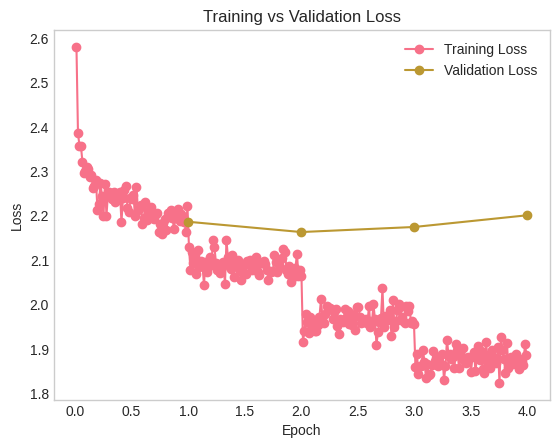

In [ ]:
# Loss Curves Visualisation

# Get full training log history from trainer
logs = trainer.state.log_history

# Initialize lists to store extracted values
train_losses = []   # Stores training loss values
eval_losses = []    # Stores validation (evaluation) loss values
epochs = []         # Stores epoch numbers for training loss

# Loop through all log entries
for log in logs:

    # Extract training loss
    if "loss" in log and "epoch" in log:
        train_losses.append(log["loss"])     # Save training loss
        epochs.append(log["epoch"])          # Save corresponding epoch

    # Extract validation loss
    if "eval_loss" in log:
        eval_losses.append(log["eval_loss"]) # Save validation loss

# Create epoch indices for validation loss
eval_epochs = list(range(1, len(eval_losses) + 1))


# Plot
plt.figure()

# Plot training loss curve
plt.plot(epochs[:len(train_losses)], train_losses, marker='o', label="Training Loss")

# Plot validation loss curve
plt.plot(eval_epochs, eval_losses, marker='o', label="Validation Loss")

# Label axes
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add title
plt.title("Training vs Validation Loss")

# Add legend to distinguish lines
plt.legend()

# Add grid for better readability
plt.grid()

# Save plot to output directory
plt.savefig(f'{training_args.output_dir}/loss_curve.png')

# Display the plot
plt.show()

# Qwen Label Extraction

In [ ]:
# Label Extraction Function

# Extract Real or Fake from generated text
def extract_label_from_output(text):
    # Convert text to lowercase for case-insensitive matching
    text = text.lower()

    # Remove thinking tags if present
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)

    # Check for keywords in the cleaned text
    if re.search(r'\breal\b', text):
      return 1 # Label for Real
    elif re.search(r'\bfake\b', text):
        return 0  # Label for Fake
    else:
        return -1  # Return -1 if label cannot be determined

# Test label extraction
test_cases = [
    ("The answer is Real", 1),
    ("This is Fake news", 0),
    ("Unknown output", -1),
]

print("Testing label extraction:")
# Run tests and compare results
for text, expected in test_cases:
    result = extract_label_from_output(text)

    # Check if result matches expected output
    status = "✓" if result == expected else "✗"
    print(f"  {status} '{text}' = {result}")

Testing label extraction:
  ✓ 'The answer is Real' = 1
  ✓ 'This is Fake news' = 0
  ✓ 'Unknown output' = -1


# Qwen Testing

In [ ]:
# Batch prediction

# Maximum number of tokens the model generates for the label
MAX_NEW_TOKENS = 5

# Function to run batch inference on multiple texts
def predict_batch(base_model, tokenizer, texts, batch_size=16):
    base_model.eval() # Set model to evaluation mode
    predictions = [] # Store predicted labels

    # Process texts in batches
    for i in tqdm(range(0, len(texts), batch_size), desc='Inference'):
        batch_texts = texts[i:i+batch_size]

        # Format prompts WITHOUT labels
        prompts = [
            format_instruction_prompt(
                {'text': t, 'label': 0}, # Dummy label
                include_label=False # Exclude label so model predicts it
        )
            for t in batch_texts
        ]

        # Tokenize batch
        inputs = tokenizer(
            prompts,
            return_tensors='pt', # Return PyTorch tensors
            truncation=True,  # Truncate long inputs
            max_length=512, # Ensure consistent max length
            padding=True # Pad batch to same length
        ).to(device) # Move inputs to GPU/CPU

        # Generate predictions
        with torch.no_grad(): # Disable gradient computation
            outputs = base_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS, # Only generate short label output
                do_sample=False, # Deterministic
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Extract labels
        for j, output in enumerate(outputs):
            input_len = (inputs['attention_mask'][j] == 1).sum()# Length of input prompt
            new_tokens = output[input_len:] # Extract only newly generated tokens
            decoded = tokenizer.decode(new_tokens, skip_special_tokens=True).strip() # Decode tokens to text
            label = extract_label_from_output(decoded) # Convert generated text into label
            predictions.append(label)

    return predictions

# Ready for inference
print("Prediction function ready")

Prediction function ready


Running inference on test set...



Inference:   0%|          | 0/507 [00:00<?, ?it/s]



RESULTS (Qwen/Qwen2.5-3B)

Prediction summary:
  Total predictions: 8102
  Valid predictions: 8101
  Unparseable: 1 (0.0%)

Metrics:
  Accuracy: 0.9389 (93.89%)
  F1 (Macro): 0.9383 (93.83%)
  F1 (Weighted): 0.9387 (93.87%)
  Recall: 0.9363 (93.63%)
  Precision: 0.9427 (94.27%)
  ROC AUC Score: 0.9363

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9702    0.8966    0.9320      3781
        Real     0.9151    0.9759    0.9446      4320

    accuracy                         0.9389      8101
   macro avg     0.9427    0.9363    0.9383      8101
weighted avg     0.9408    0.9389    0.9387      8101



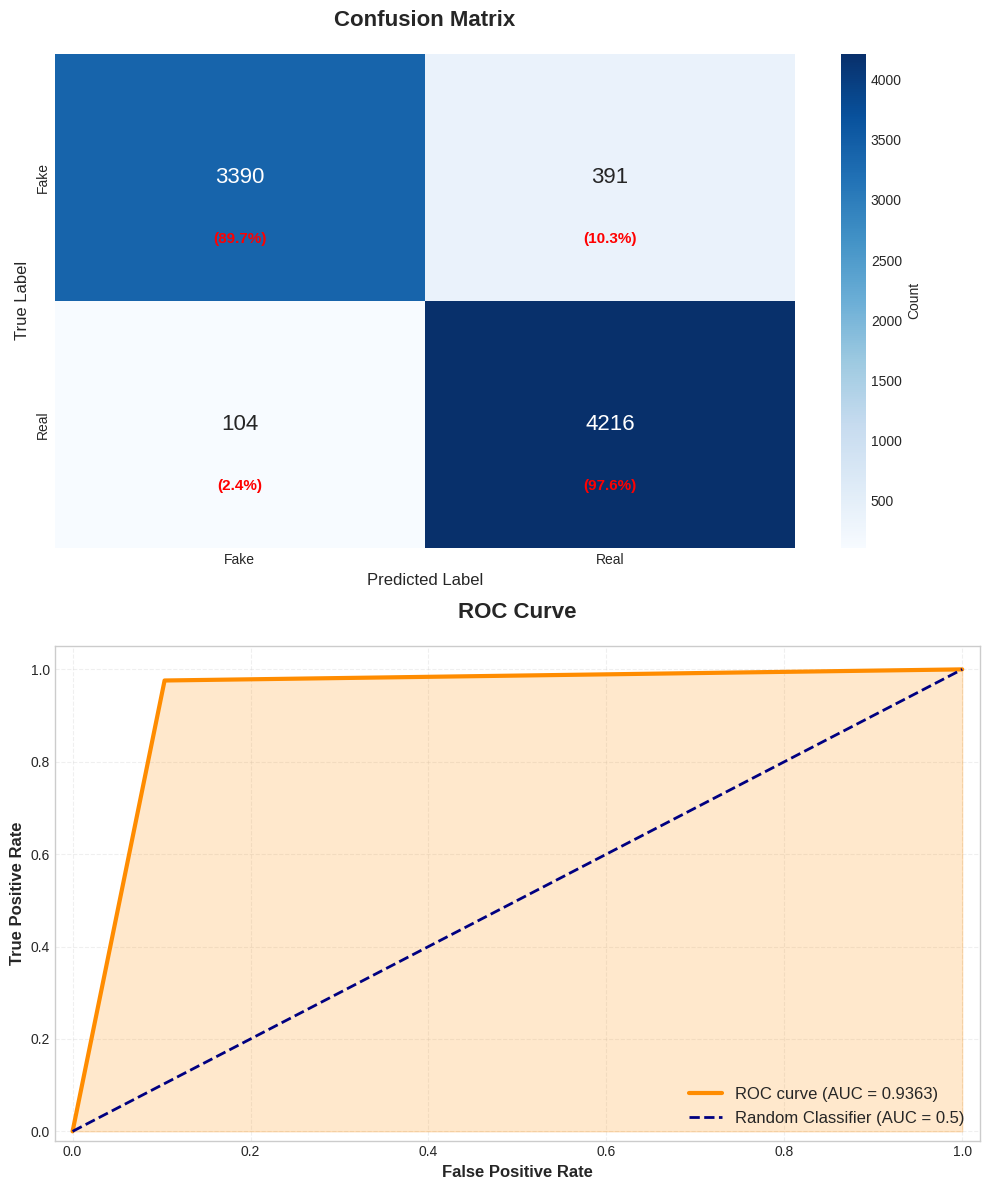


Evaluation plots saved as 'evaluation_results.png'

CONFUSION MATRIX BREAKDOWN:

True Negatives (Fake predicted as Fake): 3390
   Model correctly identified 3390 fake articles

False Positives (Fake predicted as Real): 391
   Model missed 391 fake articles (called them real)
   False positive rate: 10.34%

False Negatives (Real predicted as Fake): 104
   Model incorrectly flagged 104 real articles as fake
   False negative rate: 2.41%

True Positives (Real predicted as Real): 4216
   Model correctly identified 4216 real articles

ROC AUC INTERPRETATION:

ROC AUC Score: 0.9363
   1.0 = Perfect classifier
   0.9+ = Excellent
   0.8-0.9 = Good
   0.7-0.8 = Fair
   0.5-0.7 = Poor
   0.5 = Random guess

 Model has EXCELLENT discrimination ability!

SUMMARY METRICS TABLE:

Metric                    Score           Interpretation                
Accuracy                  0.9389          Correct predictions
Precision                 0.9427          Of positive predictions, how many correct
Re

In [ ]:
# Evaluation on test dataset

print("Running inference on test set...\n")

# Extract test texts and true labels
test_texts = test_dataset['text']
test_labels = test_dataset['label']

# Run batch prediction
predictions = predict_batch(trainer.model, tokenizer, test_texts, batch_size=16)

# Check for unrecognised outputs
unrecognised = sum(1 for p in predictions if p == -1)
if unrecognised > 0:
    print(f"\nWarning: {unrecognised}/{len(predictions)} unrecognised outputs")


# Filter valid predictions
valid_preds = [(p, l) for p, l in zip(predictions, test_labels) if p != -1] # Remove predictions th

# Separate predictions and labels
pred_list = [v[0] for v in valid_preds]
label_list = [v[1] for v in valid_preds]
unparseable = len(predictions) - len(valid_preds) # Count unparseable outputs

# Print prediction summary
print(f"\nRESULTS ({model_id})")

print(f"\nPrediction summary:")
print(f"  Total predictions: {len(predictions)}")
print(f"  Valid predictions: {len(pred_list)}")
print(f"  Unparseable: {unparseable} ({unparseable/len(predictions)*100:.1f}%)")

# Compute evaluation metrics
if pred_list:
    accuracy = accuracy_score(label_list, pred_list)
    f1_macro = f1_score(label_list, pred_list, average='macro')
    f1_weighted = f1_score(label_list, pred_list, average='weighted')
    recall = recall_score(label_list, pred_list, average='macro')
    precision = precision_score(label_list, pred_list, average='macro')

    print(f"\nMetrics:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  F1 (Macro): {f1_macro:.4f} ({f1_macro*100:.2f}%)")
    print(f"  F1 (Weighted): {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
    print(f"  Recall: {recall:.4f} ({recall*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")

    # ROC-AUC score
    try:
        roc_auc = roc_auc_score(label_list, pred_list)
        print(f"  ROC AUC Score: {roc_auc:.4f}")
    except Exception as e:
        print(f"  ROC AUC Score: Could not calculate ({str(e)})")
        roc_auc = None

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(label_list, pred_list,
                               target_names=['Fake', 'Real'], digits=4))

    # Confusion matrix and ROC-AUC Visualisation
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    # Confusion matrix
    cm = confusion_matrix(label_list, pred_list)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'],
                ax=axes[0],
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 16})

    axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)

    # Add percentages values inside confusion matrix
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j + 0.5, i + 0.75, f'({cm_percent[i, j]:.1f}%)',
                        ha='center', va='center', fontsize=11, color='red', fontweight='bold')

    # ROC curve
    fpr, tpr, thresholds = roc_curve(label_list, pred_list)
    roc_auc_calc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=3,
                label=f'ROC curve (AUC = {roc_auc_calc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                 label='Random Classifier (AUC = 0.5)')  # Random baseline
    axes[1].set_xlim([-0.02, 1.02])
    axes[1].set_ylim([-0.02, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    axes[1].set_title('ROC Curve', fontsize=16, fontweight='bold', pad=20)
    axes[1].legend(loc="lower right", fontsize=12, framealpha=0.95)
    axes[1].grid(True, alpha=0.3, linestyle='--')

    # Fill area under curve
    axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')

    # Adjust spacing between subplots
    plt.tight_layout()

    # Save figure
    plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nEvaluation plots saved as 'evaluation_results.png'")

    # Confusion matrix interpretation
    print("\nCONFUSION MATRIX BREAKDOWN:")

    tn, fp, fn, tp = cm.ravel()

    print(f"\nTrue Negatives (Fake predicted as Fake): {tn}")
    print(f"   Model correctly identified {tn} fake articles")

    print(f"\nFalse Positives (Fake predicted as Real): {fp}")
    print(f"   Model missed {fp} fake articles (called them real)")
    print(f"   False positive rate: {fp/(fp+tn)*100:.2f}%")

    print(f"\nFalse Negatives (Real predicted as Fake): {fn}")
    print(f"   Model incorrectly flagged {fn} real articles as fake")
    print(f"   False negative rate: {fn/(fn+tp)*100:.2f}%")

    print(f"\nTrue Positives (Real predicted as Real): {tp}")
    print(f"   Model correctly identified {tp} real articles")

    # ROC interpretation
    print("\nROC AUC INTERPRETATION:")
    print(f"\nROC AUC Score: {roc_auc_calc:.4f}")
    print("   1.0 = Perfect classifier")
    print("   0.9+ = Excellent")
    print("   0.8-0.9 = Good")
    print("   0.7-0.8 = Fair")
    print("   0.5-0.7 = Poor")
    print("   0.5 = Random guess")

    if roc_auc_calc >= 0.9:
        print(f"\n Model has EXCELLENT discrimination ability!")
    elif roc_auc_calc >= 0.8:
        print(f"\n Model has GOOD discrimination ability!")
    elif roc_auc_calc >= 0.7:
        print(f"\n Model has FAIR discrimination ability!")
    else:
        print(f"\n Model has LIMITED discrimination ability!")

    # Summary statistics table
    print("\nSUMMARY METRICS TABLE:")
    print(f"\n{'Metric':<25} {'Score':<15} {'Interpretation':<30}")
    print(f"{'Accuracy':<25} {accuracy:<15.4f} Correct predictions")
    print(f"{'Precision':<25} {precision:<15.4f} Of positive predictions, how many correct")
    print(f"{'Recall':<25} {recall:<15.4f} Of actual positives, how many found")
    print(f"{'F1 (Weighted)':<25} {f1_weighted:<15.4f} Harmonic mean (weighted)")
    print(f"{'F1 (Macro)':<25} {f1_macro:<15.4f} Harmonic mean (unweighted)")
    print(f"{'ROC AUC':<25} {roc_auc_calc:<15.4f} Area under ROC curve")
else:
    # No valid predictions case
    print(f"\nNo valid predictions! Check prompt format.")

# Store results
qwen_results = {}

qwen_results['gonzalo'] = {
    'accuracy': accuracy,
    'macro_f1': f1_macro
}

# Qwen Prediction

In [ ]:
# Model Sample Prediction

# Pick 10 random test samples
sample_indices = random.sample(range(len(test_dataset)), 10)
sample_texts = [test_dataset[i]['text'] for i in sample_indices]
sample_labels = [test_dataset[i]['label'] for i in sample_indices]

# Run predictions
sample_preds = predict_batch(trainer.model, tokenizer, sample_texts, batch_size=4)

# Display results
print(f"{'#':<4} {'True':<8} {'Pred':<8} {'Match':<8} {'Generated Text'}")
print("-" * 60)

for i, (true, pred) in enumerate(zip(sample_labels, sample_preds)):
    true_str = id2label[true]
    pred_str = id2label[pred] if pred != -1 else "???"
    match = "✓" if true == pred else "✗"
    print(f"{i+1:<4} {true_str:<8} {pred_str:<8} {match}")

# Summary
correct = sum(1 for t, p in zip(sample_labels, sample_preds) if t == p)
print(f"\nAccuracy: {correct}/10 ({correct/10*100:.0f}%)")

Inference:   0%|          | 0/3 [00:00<?, ?it/s]

#    True     Pred     Match    Generated Text
------------------------------------------------------------
1    Fake     Fake     ✓
2    Fake     Fake     ✓
3    Fake     Real     ✗
4    Real     Real     ✓
5    Fake     Fake     ✓
6    Fake     Fake     ✓
7    Fake     Fake     ✓
8    Fake     Fake     ✓
9    Fake     Fake     ✓
10   Real     Real     ✓

Accuracy: 9/10 (90%)


# Qwen Custom Inference

In [ ]:
# Custom inference examples

custom_inputs = [
    "Manchester Metropolitan University is a university in Manchester England",
    "Scientists discover new vaccine that eliminates all known diseases overnight",
    "Federal Reserve raises interest rates by 0.25% amid inflation concerns",
    "Government puts fluoride in water to control the population and leaked documents reveal",
    "Apple announces new iPhone with record-breaking battery life",
    "The stock market is expected to rise next quarter due to economic growth",
    "Breaking news: Major earthquake strikes downtown area",
    "New technology is revolutionizing the healthcare industry",
    "The local sports team wins the championship after a thrilling match",
    "Scientists discover a new planet that could support life",
    "Local man wins lottery and buys new mansion",
    "Study reveals that drinking coffee can actually improve your memory",
    "New research shows that climate change is accelerating at an alarming rate",
    "Celebrity couple announces their divorce after 10 years of marriage",
    "Unbelievable as man claims to have spoken with aliens during a camping trip"
]

print("Testing on custom examples:\n")

custom_preds = predict_batch(base_model, tokenizer, custom_inputs, batch_size=2)

print(f"\nResults:")
for text, pred in zip(custom_inputs, custom_preds):
    if pred == -1:
        label = "UNPARSEABLE"
    else:
        label = id2label[pred]
    print(f"\n  [{label}] {text[:80]}...")

Testing on custom examples:



Inference:   0%|          | 0/8 [00:00<?, ?it/s]


Results:

  [Fake] Manchester Metropolitan University is a university in Manchester England...

  [Fake] Scientists discover new vaccine that eliminates all known diseases overnight...

  [Fake] Federal Reserve raises interest rates by 0.25% amid inflation concerns...

  [Fake] Government puts fluoride in water to control the population and leaked documents...

  [Fake] Apple announces new iPhone with record-breaking battery life...

  [Fake] The stock market is expected to rise next quarter due to economic growth...

  [Fake] Breaking news: Major earthquake strikes downtown area...

  [Fake] New technology is revolutionizing the healthcare industry...

  [Fake] The local sports team wins the championship after a thrilling match...

  [Fake] Scientists discover a new planet that could support life...

  [Fake] Local man wins lottery and buys new mansion...

  [Fake] Study reveals that drinking coffee can actually improve your memory...

  [Fake] New research shows that climate change 

# Training Curve Analysis

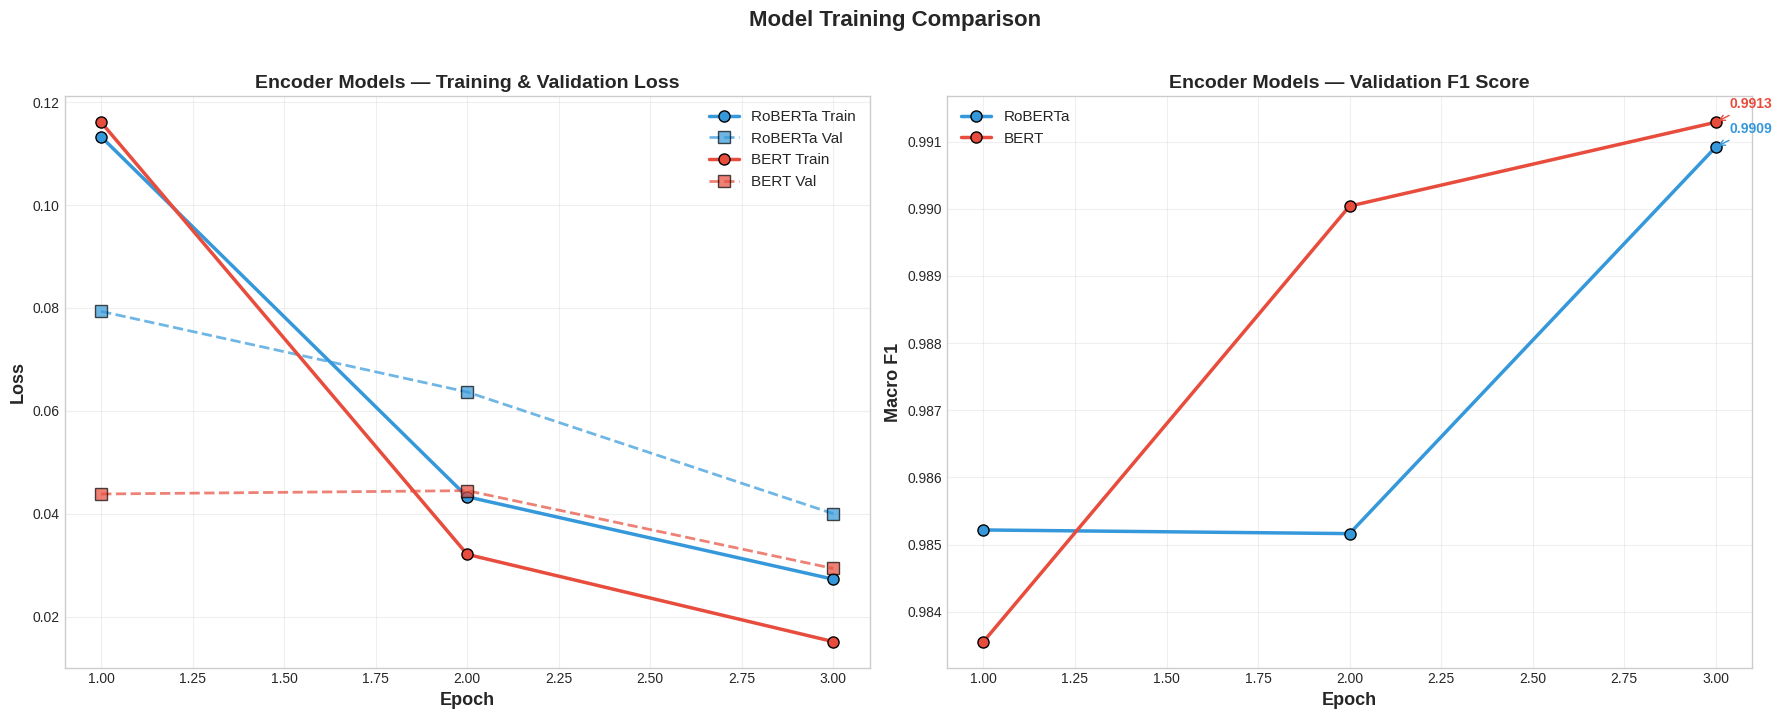

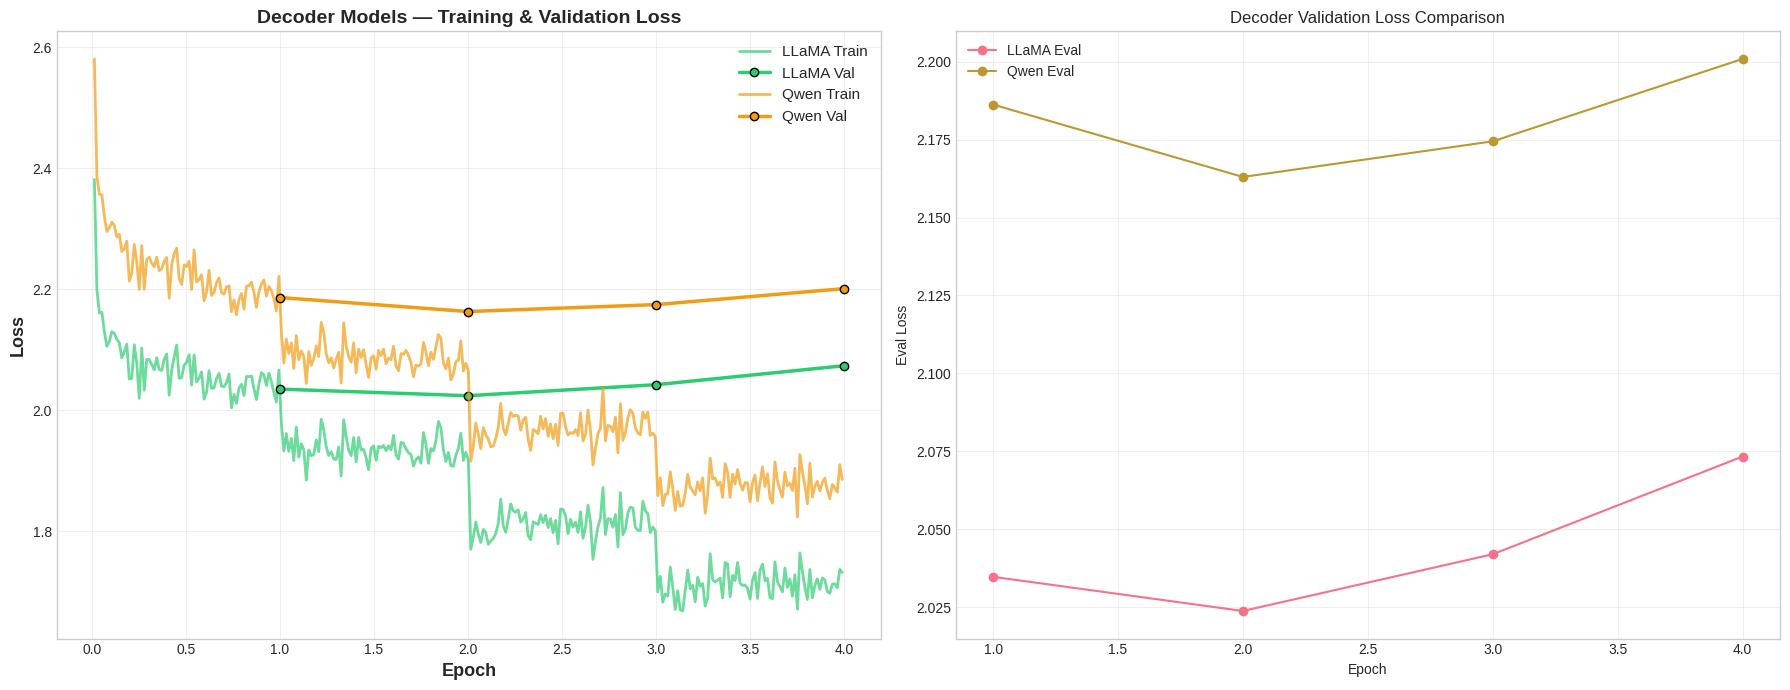

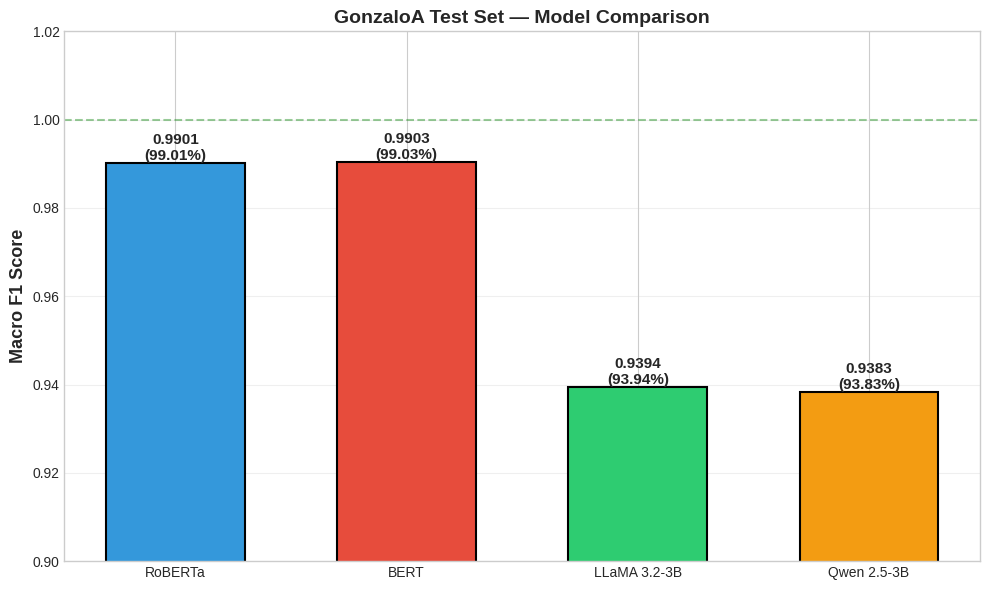

In [ ]:
# Combined Training Curves Comparison

# Load encoder histories from saved checkpoints
roberta_ckpt = torch.load('best_model_RoBERTa.pt', map_location='cpu')
bert_ckpt = torch.load('best_model_BERT.pt', map_location='cpu')

roberta_history = roberta_ckpt.get('history', {})
bert_history = bert_ckpt.get('history', {})

# Prepare decoder histories
def extract_decoder_losses(trainer_logs):
    # Extract train/eval losses from SFTTrainer log history
    train_losses, eval_losses = [], []
    train_epochs, eval_epochs = [], []
    for log in trainer_logs:
        if 'loss' in log and 'epoch' in log and 'eval_loss' not in log:
            train_losses.append(log['loss'])
            train_epochs.append(log['epoch'])
        if 'eval_loss' in log and 'epoch' in log:
            eval_losses.append(log['eval_loss'])
            eval_epochs.append(log['epoch'])
    return train_losses, eval_losses, train_epochs, eval_epochs

# Load LLaMA logs
with open(f'{save_dir_Llama}/training_logs.json') as f:
    llama_logs = json.load(f)

# Load Qwen logs
with open(f'{save_dir_Qwen}/training_logs.json') as f:
    qwen_logs = json.load(f)

# Load decoder histories
llama_train, llama_eval, llama_t_epochs, llama_e_epochs = extract_decoder_losses(llama_logs)
qwen_train, qwen_eval, qwen_t_epochs, qwen_e_epochs = extract_decoder_losses(qwen_logs)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

model_configs = [
    ('RoBERTa', '#3498db', roberta_history.get('train_loss', []), roberta_history.get('val_loss', [])),
    ('BERT', '#e74c3c', bert_history.get('train_loss', []), bert_history.get('val_loss', [])),
]

# Subplot 1: Encoder Training Loss
ax1 = axes[0]
for name, color, train_loss, val_loss in model_configs:
    if train_loss:
        epochs = list(range(1, len(train_loss) + 1))
        ax1.plot(epochs, train_loss, 'o-', color=color, linewidth=2.5,
                 markersize=8, label=f'{name} Train', markeredgecolor='black', markeredgewidth=1)
        ax1.plot(epochs, val_loss, 's--', color=color, linewidth=2, alpha=0.7,
                 markersize=8, label=f'{name} Val', markeredgecolor='black', markeredgewidth=1)

ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Encoder Models — Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Subplot 2: Encoder Validation F1
ax2 = axes[1]
for name, color, train_loss, val_loss in model_configs:
    # Get val_f1 from history
    if name == 'RoBERTa' and 'val_f1' in roberta_history:
        f1_vals = roberta_history['val_f1']
    elif name == 'BERT' and 'val_f1' in bert_history:
        f1_vals = bert_history['val_f1']
    else:
        continue
    epochs = list(range(1, len(f1_vals) + 1))
    ax2.plot(epochs, f1_vals, 'o-', color=color, linewidth=2.5,
             markersize=8, label=f'{name}', markeredgecolor='black', markeredgewidth=1)
    # Annotate best epoch
    best_idx = f1_vals.index(max(f1_vals))
    ax2.annotate(f'{f1_vals[best_idx]:.4f}',
                 xy=(epochs[best_idx], f1_vals[best_idx]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=10, fontweight='bold', color=color,
                 arrowprops=dict(arrowstyle='->', color=color))

ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Macro F1', fontsize=13, fontweight='bold')
ax2.set_title('Encoder Models — Validation F1 Score', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Training Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_comparison_encoders.png', dpi=150, bbox_inches='tight')
plt.show()

# Decoder Training Curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 3: Decoder Training Loss
ax1 = axes[0]
if llama_train:
    ax1.plot(llama_t_epochs, llama_train, '-', color='#2ecc71', linewidth=2,
             alpha=0.7, label='LLaMA Train')
if llama_eval:
    ax1.plot(llama_e_epochs, llama_eval, 'o-', color='#2ecc71', linewidth=2.5,
             markersize=6, label='LLaMA Val', markeredgecolor='black', markeredgewidth=1)
if qwen_train:
    ax1.plot(qwen_t_epochs, qwen_train, '-', color='#f39c12', linewidth=2,
             alpha=0.7, label='Qwen Train')
if qwen_eval:
    ax1.plot(qwen_e_epochs, qwen_eval, 'o-', color='#f39c12', linewidth=2.5,
             markersize=6, label='Qwen Val', markeredgecolor='black', markeredgewidth=1)

ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Decoder Models — Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Subplot 4: Decoder Validation Loss
ax2 = axes[1]

ax2.plot(llama_e_epochs, llama_eval, 'o-', label='LLaMA Eval')
ax2.plot(qwen_e_epochs, qwen_eval, 'o-', label='Qwen Eval')

ax2.set_title("Decoder Validation Loss Comparison")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Eval Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# GonzaloA Test Performance Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

models = ['RoBERTa', 'BERT', 'LLaMA 3.2-3B', 'Qwen 2.5-3B']
gonzalo_f1 = [
    RoBERTa_results['gonzalo']['macro_f1'],
    BERT_results['gonzalo']['macro_f1'],
    llama_results.get('gonzalo', {}).get('macro_f1', 0),
    qwen_results.get('gonzalo', {}).get('macro_f1', 0),
]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(models, gonzalo_f1, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

for bar, val in zip(bars, gonzalo_f1):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.4f}\n({val*100:.2f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Macro F1 Score', fontsize=13, fontweight='bold')
ax.set_title('GonzaloA Test Set — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.90, 1.02])
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('gonzalo_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-Dataset Evaluation

In [ ]:
# Dataset cleaning function

# Text cleaning
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s.,!?\'"-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

id2label = {0: 'Fake', 1: 'Real'}

# Second Dataset Preprocessing

In [ ]:
# Pulk17

raw_pulk17 = load_dataset("Pulk17/Fake-News-Detection-dataset")

def preprocess_pulk17(example):
    text = clean_text(example.get('text') or "")
    return {
        'text': text if text else "no content",
        'label': example['label']
    }

cols_to_remove = [c for c in raw_pulk17['train'].column_names if c not in ['text', 'label']]

pulk17_data = raw_pulk17['train'].map(
    preprocess_pulk17,
    remove_columns=cols_to_remove,
    desc="Preprocessing Pulk17"
)

# Deduplicate
df = pulk17_data.to_pandas()
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
pulk17_data = HFDataset.from_pandas(df, preserve_index=False)
pulk17_data = pulk17_data.filter(lambda x: x['text'] and x['text'].strip() != "" and x['text'] != "no content")

print(f"Pulk17: {len(pulk17_data)} samples after dedup")
print(f"  Label distribution: {Counter(pulk17_data['label'])}")

train.tsv:   0%|          | 0.00/78.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

Preprocessing Pulk17:   0%|          | 0/30000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/27154 [00:00<?, ? examples/s]

Pulk17: 27153 samples after dedup
  Label distribution: Counter({1: 14297, 0: 12856})


# Third Dataset Preprocessing

In [ ]:
# UKPLab/liar

def preprocess_liar(example):
    text = clean_text(example.get('text') or "")
    context = clean_text(example.get('context') or "")

    # Add context if available
    if context:
        combined = f"{text}. context: {context}"
    else:
        combined = text

    flipped_label = 1 - example['labels']

    return {
        'text': combined if combined else "no content",
        'label': flipped_label
    }

raw_liar = load_dataset("UKPLab/liar")

all_splits = []
for split in ['train', 'validation', 'test']:
    processed = raw_liar[split].map(
        preprocess_liar,
        remove_columns=raw_liar[split].column_names,
        desc=f"Preprocessing LIAR {split}"
    )
    all_splits.append(processed)

liar_data = concatenate_datasets(all_splits)

df = liar_data.to_pandas()
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
liar_data = HFDataset.from_pandas(df, preserve_index=False)
liar_data = liar_data.filter(lambda x: x['text'] and x['text'].strip() != "" and x['text'] != "no content")

print(f"LIAR: {len(liar_data)} samples after dedup")
print(f"  Label distribution: {Counter(liar_data['label'])}")

README.md:   0%|          | 0.00/149 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

...

Preprocessing LIAR train:   0%|          | 0/10269 [00:00<?, ? examples/s]

Preprocessing LIAR validation:   0%|          | 0/1284 [00:00<?, ? examples/s]

Preprocessing LIAR test:   0%|          | 0/1283 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12833 [00:00<?, ? examples/s]

LIAR: 12833 samples after dedup
  Label distribution: Counter({1: 9273, 0: 3560})


# Fourth Dataset Preprocessing

In [ ]:
# WELFake (Verma et al., 2021)

raw_welfake = load_dataset("davanstrien/WELFake")

def preprocess_welfake(example):
    title = clean_text(example.get('title') or "")
    text = clean_text(example.get('text') or "")

    # Combine title and text
    if title and text:
        combined = f"{title}. {text}"
    elif title:
        combined = title
    elif text:
        combined = text
    else:
        combined = "no content"

    # Strip source attribution tags to prevent artefact bias
    combined = re.sub(r'\(reuters\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(ap\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(afp\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\s+', ' ', combined).strip()

    flipped_label = 1 - example['label']

    return {
        'text': combined if combined else "no content",
        'label': flipped_label
    }

cols_to_remove = [c for c in raw_welfake['train'].column_names if c not in ['text', 'label']]

welfake_data = raw_welfake['train'].map(
    preprocess_welfake,
    remove_columns=cols_to_remove,
    desc="Preprocessing WELFake"
)

# Deduplicate
df = welfake_data.to_pandas()
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
welfake_data = HFDataset.from_pandas(df, preserve_index=False)
welfake_data = welfake_data.filter(lambda x: x['text'] and x['text'].strip() != "" and x['text'] != "no content")

print(f"WELFake: {len(welfake_data)} samples after dedup")
print(f"  Label distribution: {Counter(welfake_data['label'])}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-290868f0a36350(…):   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

Preprocessing WELFake:   0%|          | 0/72134 [00:00<?, ? examples/s]

Filter:   0%|          | 0/63400 [00:00<?, ? examples/s]

WELFake: 63399 samples after dedup
  Label distribution: Counter({1: 34523, 0: 28876})


# Encoder Cross-Dataset Evaluation Function

In [ ]:
# Cross-dataset evaluation function

def evaluate_cross_dataset(model, tokenizer, dataset, dataset_name, device, batch_size=16):
    print(f"Cross-Dataset Evaluation: {dataset_name}")

    def tokenize_fn(examples):
        return tokenizer(
            examples['text'],
            truncation=True,
            padding=False,
            max_length=512,
            return_tensors=None
        )

    tokenized = dataset.map(tokenize_fn, batched=True, desc=f"Tokenizing {dataset_name}")
    tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    dataloader = DataLoader(
        tokenized,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collator,
        num_workers=0,
        pin_memory=True
    )

    results = evaluate(model, dataloader, device)

    # Extract overall metrics
    accuracy = results['accuracy']
    macro_f1 = results['f1']
    precision = results['precision']
    recall = results['recall']

    # Compute per-class metrics and classification report here
    true_labels = results['true_labels']
    predictions = results['predictions']
    target_names = [id2label[0], id2label[1]]

    report_dict = classification_report(true_labels, predictions, target_names=target_names, output_dict=True)
    class_report_str = classification_report(true_labels, predictions, target_names=target_names, digits=4)

    per_class_metrics = {}
    for name in target_names:
        per_class_metrics[name.lower()] = {
            'precision': report_dict[name]['precision'],
            'recall': report_dict[name]['recall'],
            'f1': report_dict[name]['f1-score']
        }

    print(f"\nResults on {dataset_name} dataset: ")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1:  {macro_f1:.4f} ({macro_f1*100:.2f}%)")
    print(f"\nPer-Class Metrics:")
    for cls_name in ['fake', 'real']:
        cls = per_class_metrics[cls_name]
        print(f"  {cls_name.capitalize()}: P={cls['precision']:.4f}  R={cls['recall']:.4f}  F1={cls['f1']:.4f}")
    print(f"\n{class_report_str}")

    # Add computed metrics to the results dictionary for potential future use
    results['per_class'] = per_class_metrics
    results['classification_report'] = class_report_str
    results['macro_f1'] = macro_f1

    return results

# RoBERTa Cross-Dataset Evaluation

In [ ]:
# RoBERTa evaluation

# Make sure best model is loaded
checkpoint = torch.load('best_model_RoBERTa.pt', map_location=device)
model_RoBERTa.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded RoBERTa (Val F1: {checkpoint['val_f1']:.4f})")

if 'RoBERTa_results' not in dir():
    RoBERTa_results = {}

RoBERTa_results['pulk17'] = evaluate_cross_dataset(
    model_RoBERTa, tokenizer_RoBERTa, pulk17_data, "Pulk17", device
)

RoBERTa_results['liar'] = evaluate_cross_dataset(
    model_RoBERTa, tokenizer_RoBERTa, liar_data, "LIAR", device
)

RoBERTa_results['welfake'] = evaluate_cross_dataset(
    model_RoBERTa, tokenizer_RoBERTa, welfake_data, "WELFake", device
)

Loaded RoBERTa (Val F1: 0.9909)
Cross-Dataset Evaluation: Pulk17


Tokenizing Pulk17:   0%|          | 0/27153 [00:00<?, ? examples/s]

Testing:   0%|          | 0/1698 [00:00<?, ?it/s]


Results on Pulk17 dataset: 
  Accuracy:  0.6265 (62.65%)
  Macro F1:  0.5845 (58.45%)

Per-Class Metrics:
  Fake: P=0.5592  R=0.9973  F1=0.7166
  Real: P=0.9917  R=0.2930  F1=0.4524

              precision    recall  f1-score   support

        Fake     0.5592    0.9973    0.7166     12856
        Real     0.9917    0.2930    0.4524     14297

    accuracy                         0.6265     27153
   macro avg     0.7754    0.6451    0.5845     27153
weighted avg     0.7869    0.6265    0.5774     27153

Cross-Dataset Evaluation: LIAR


Tokenizing LIAR:   0%|          | 0/12833 [00:00<?, ? examples/s]

Testing:   0%|          | 0/803 [00:00<?, ?it/s]


Results on LIAR dataset: 
  Accuracy:  0.2776 (27.76%)
  Macro F1:  0.2184 (21.84%)

Per-Class Metrics:
  Fake: P=0.2770  R=0.9961  F1=0.4334
  Real: P=0.5333  R=0.0017  F1=0.0034

              precision    recall  f1-score   support

        Fake     0.2770    0.9961    0.4334      3560
        Real     0.5333    0.0017    0.0034      9273

    accuracy                         0.2776     12833
   macro avg     0.4051    0.4989    0.2184     12833
weighted avg     0.4622    0.2776    0.1227     12833

Cross-Dataset Evaluation: WELFake


Tokenizing WELFake:   0%|          | 0/63399 [00:00<?, ? examples/s]

Testing:   0%|          | 0/3963 [00:00<?, ?it/s]


Results on WELFake dataset: 
  Accuracy:  0.9014 (90.14%)
  Macro F1:  0.9013 (90.13%)

Per-Class Metrics:
  Fake: P=0.8484  R=0.9541  F1=0.8981
  Real: P=0.9571  R=0.8574  F1=0.9045

              precision    recall  f1-score   support

        Fake     0.8484    0.9541    0.8981     28876
        Real     0.9571    0.8574    0.9045     34523

    accuracy                         0.9014     63399
   macro avg     0.9027    0.9057    0.9013     63399
weighted avg     0.9076    0.9014    0.9016     63399



# BERT Cross-Dataset Evaluation

In [ ]:
# BERT evaluation

checkpoint_bert = torch.load('best_model_BERT.pt', map_location=device)
model_BERT.load_state_dict(checkpoint_bert['model_state_dict'])
print(f"Loaded BERT (Val F1: {checkpoint_bert['val_f1']:.4f})")

if 'BERT_results' not in dir():
    BERT_results = {}

BERT_results['pulk17'] = evaluate_cross_dataset(
    model_BERT, tokenizer_BERT, pulk17_data, "Pulk17", device
)

BERT_results['liar'] = evaluate_cross_dataset(
    model_BERT, tokenizer_BERT, liar_data, "LIAR", device
)

BERT_results['welfake'] = evaluate_cross_dataset(
    model_BERT, tokenizer_BERT, welfake_data, "WELFake", device
)

Loaded BERT (Val F1: 0.9913)
Cross-Dataset Evaluation: Pulk17


Tokenizing Pulk17:   0%|          | 0/27153 [00:00<?, ? examples/s]

Testing:   0%|          | 0/1698 [00:00<?, ?it/s]


Results on Pulk17 dataset: 
  Accuracy:  0.5776 (57.76%)
  Macro F1:  0.5136 (51.36%)

Per-Class Metrics:
  Fake: P=0.5287  R=0.9930  F1=0.6900
  Real: P=0.9701  R=0.2040  F1=0.3371

              precision    recall  f1-score   support

        Fake     0.5287    0.9930    0.6900     12856
        Real     0.9701    0.2040    0.3371     14297

    accuracy                         0.5776     27153
   macro avg     0.7494    0.5985    0.5136     27153
weighted avg     0.7611    0.5776    0.5042     27153

Cross-Dataset Evaluation: LIAR


Tokenizing LIAR:   0%|          | 0/12833 [00:00<?, ? examples/s]

Testing:   0%|          | 0/803 [00:00<?, ?it/s]


Results on LIAR dataset: 
  Accuracy:  0.2806 (28.06%)
  Macro F1:  0.2260 (22.60%)

Per-Class Metrics:
  Fake: P=0.2764  R=0.9846  F1=0.4316
  Real: P=0.6358  R=0.0104  F1=0.0204

              precision    recall  f1-score   support

        Fake     0.2764    0.9846    0.4316      3560
        Real     0.6358    0.0104    0.0204      9273

    accuracy                         0.2806     12833
   macro avg     0.4561    0.4975    0.2260     12833
weighted avg     0.5361    0.2806    0.1345     12833

Cross-Dataset Evaluation: WELFake


Tokenizing WELFake:   0%|          | 0/63399 [00:00<?, ? examples/s]

Testing:   0%|          | 0/3963 [00:00<?, ?it/s]


Results on WELFake dataset: 
  Accuracy:  0.8479 (84.79%)
  Macro F1:  0.8475 (84.75%)

Per-Class Metrics:
  Fake: P=0.7551  R=0.9858  F1=0.8551
  Real: P=0.9840  R=0.7325  F1=0.8398

              precision    recall  f1-score   support

        Fake     0.7551    0.9858    0.8551     28876
        Real     0.9840    0.7325    0.8398     34523

    accuracy                         0.8479     63399
   macro avg     0.8695    0.8591    0.8475     63399
weighted avg     0.8797    0.8479    0.8468     63399



# Decoder Cross-Dataset Evaluation Function

In [ ]:
# Decoder model inference

# Run inference on a single text
def predict_decoder(model, tokenizer, text, device, max_new_tokens=5):

    # Truncate text
    text = text[:1500]

    # Match EXACT training prompt format (without label)
    prompt = (
        f"### Task: Classify the following news article as Real or Fake.\n\n"
        f"### Article:\n{text}\n\n"
        f"### Label:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    # Decode only the generated tokens
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(generated, skip_special_tokens=True).strip().lower()

    # Map response to label
    if 'fake' in response:
        return 0  # Fake
    elif 'real' in response:
        return 1  # Real
    else:
        return -1  # Unrecognised

# Evaluate a decoder model on a cross-dataset
def evaluate_decoder_cross_dataset(model, tokenizer, dataset, dataset_name, device):

    print(f"Decoder Cross-Dataset Evaluation : {dataset_name}")

    raw_predictions = []
    true_labels = []
    unrecognised = 0

    progress_bar = tqdm(range(len(dataset)), desc=f"Evaluating {dataset_name}")

    for i in progress_bar:
        text = dataset[i]['text']
        true_label = dataset[i]['label']

        pred = predict_decoder(model, tokenizer, text, device)

        if pred == -1:
            unrecognised += 1

        raw_predictions.append(pred)
        true_labels.append(true_label)

        if (i + 1) % 100 == 0:
            valid_so_far = [(p, t) for p, t in zip(raw_predictions, true_labels) if p != -1]
            if valid_so_far:
                current_acc = sum(p == t for p, t in valid_so_far) / len(valid_so_far)
                progress_bar.set_postfix({'acc': f'{current_acc:.4f}', 'unrecognised': unrecognised})

    # Filter out unrecognised predictions
    valid_preds = [(p, t) for p, t in zip(raw_predictions, true_labels) if p != -1]
    predictions = [v[0] for v in valid_preds]
    filtered_labels = [v[1] for v in valid_preds]

    # Calculate metrics on valid predictions only
    accuracy = accuracy_score(filtered_labels, predictions)
    macro_f1 = f1_score(filtered_labels, predictions, average='macro')

    per_class = precision_recall_fscore_support(
        filtered_labels, predictions, average=None, labels=[0, 1]
    )

    report = classification_report(
        filtered_labels, predictions,
        target_names=['Fake', 'Real'],
        digits=4
    )

    print(f"\nResults on {dataset_name}:")
    print(f"  Total samples:  {len(raw_predictions)}")
    print(f"  Valid:           {len(predictions)} ({len(predictions)/len(raw_predictions)*100:.1f}%)")
    print(f"  Unrecognised:    {unrecognised} ({unrecognised/len(raw_predictions)*100:.1f}%) — excluded from metrics")
    print(f"  Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1:        {macro_f1:.4f} ({macro_f1*100:.2f}%)")
    print(f"\nPer-Class Metrics:")
    print(f"  Fake: P={per_class[0][0]:.4f}  R={per_class[1][0]:.4f}  F1={per_class[2][0]:.4f}")
    print(f"  Real: P={per_class[0][1]:.4f}  R={per_class[1][1]:.4f}  F1={per_class[2][1]:.4f}")
    print(f"\n{report}")

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'per_class': {
            'fake': {'precision': per_class[0][0], 'recall': per_class[1][0], 'f1': per_class[2][0]},
            'real': {'precision': per_class[0][1], 'recall': per_class[1][1], 'f1': per_class[2][1]}
        },
        'classification_report': report,
        'predictions': predictions,
        'true_labels': filtered_labels,
        'unrecognised': unrecognised,
        'total_samples': len(raw_predictions)
    }

# Llama Cross-Dataset Evaluation

In [ ]:
# Llama evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load trained Llama model for evaluation
save_dir_Llama = f'./{cfg_Llama["save_name"]}_lora_adapter'

# Load base model
base_model_Llama = AutoModelForCausalLM.from_pretrained(
    cfg_Llama['model_id'],
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# Load LoRA adapter on top
model_Llama = PeftModel.from_pretrained(base_model_Llama, save_dir_Llama)
model_Llama.eval()

# Load tokenizer
tokenizer_Llama = AutoTokenizer.from_pretrained(save_dir_Llama)

print(f"Model loaded from {save_dir_Llama}")

llama_results = {}

# Test on first 1000 samples
small_pulk17 = pulk17_data.select(range(1698))
llama_results['pulk17_sample'] = evaluate_decoder_cross_dataset(
    model_Llama, tokenizer_Llama, small_pulk17, "Pulk17 (sample)", device
)

# Test on first 1000 samples
small_liar = liar_data.select(range(803))
llama_results['lia_sample'] = evaluate_decoder_cross_dataset(
    model_Llama, tokenizer_Llama, small_liar, "LIAR (sample)", device
)

# Test on first 1000 samples
small_welfake = welfake_data.select(range(3963))
llama_results['welfake_sample'] = evaluate_decoder_cross_dataset(
    model_Llama, tokenizer_Llama, small_welfake, "WELFake (sample)", device
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Model loaded from ./llama3b_lora_adapter
Decoder Cross-Dataset Evaluation : Pulk17 (sample)


Evaluating Pulk17 (sample):   0%|          | 0/1698 [00:00<?, ?it/s]


Results on Pulk17 (sample):
  Total samples:  1698
  Valid:           1698 (100.0%)
  Unrecognised:    0 (0.0%) — excluded from metrics
  Accuracy:        0.9364 (93.64%)
  Macro F1:        0.9361 (93.61%)

Per-Class Metrics:
  Fake: P=0.8920  R=0.9942  F1=0.9403
  Real: P=0.9933  R=0.8777  F1=0.9319

              precision    recall  f1-score   support

        Fake     0.8920    0.9942    0.9403       856
        Real     0.9933    0.8777    0.9319       842

    accuracy                         0.9364      1698
   macro avg     0.9427    0.9359    0.9361      1698
weighted avg     0.9422    0.9364    0.9362      1698

Decoder Cross-Dataset Evaluation : LIAR (sample)


Evaluating LIAR (sample):   0%|          | 0/803 [00:00<?, ?it/s]


Results on LIAR (sample):
  Total samples:  803
  Valid:           803 (100.0%)
  Unrecognised:    0 (0.0%) — excluded from metrics
  Accuracy:        0.2765 (27.65%)
  Macro F1:        0.2265 (22.65%)

Per-Class Metrics:
  Fake: P=0.2696  R=0.9816  F1=0.4230
  Real: P=0.6923  R=0.0154  F1=0.0301

              precision    recall  f1-score   support

        Fake     0.2696    0.9816    0.4230       217
        Real     0.6923    0.0154    0.0301       586

    accuracy                         0.2765       803
   macro avg     0.4810    0.4985    0.2265       803
weighted avg     0.5781    0.2765    0.1363       803

Decoder Cross-Dataset Evaluation : WELFake (sample)


Evaluating WELFake (sample):   0%|          | 0/3963 [00:00<?, ?it/s]


Results on WELFake (sample):
  Total samples:  3963
  Valid:           3962 (100.0%)
  Unrecognised:    1 (0.0%) — excluded from metrics
  Accuracy:        0.8958 (89.58%)
  Macro F1:        0.8939 (89.39%)

Per-Class Metrics:
  Fake: P=0.8391  R=0.9888  F1=0.9078
  Real: P=0.9850  R=0.7953  F1=0.8800

              precision    recall  f1-score   support

        Fake     0.8391    0.9888    0.9078      2057
        Real     0.9850    0.7953    0.8800      1905

    accuracy                         0.8958      3962
   macro avg     0.9121    0.8920    0.8939      3962
weighted avg     0.9093    0.8958    0.8945      3962



# Qwen Cross-Dataset Evaluation

In [ ]:
# Qwen Evaluation

# Load trained Qwen model for evaluation
save_dir_Qwen = f'./{cfg_Qwen["save_name"]}_lora_adapter'

base_model_Qwen = AutoModelForCausalLM.from_pretrained(
    cfg_Qwen['model_id'],
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
model_Qwen = PeftModel.from_pretrained(base_model_Qwen, save_dir_Qwen)
model_Qwen.eval()
tokenizer_Qwen = AutoTokenizer.from_pretrained(save_dir_Qwen)

print(f"Model loaded from {save_dir_Qwen}")

qwen_results = {}

# Test on first 1000 samples
small_pulk17 = pulk17_data.select(range(1698))
qwen_results['pulk17_sample'] = evaluate_decoder_cross_dataset(
    model_Qwen, tokenizer_Qwen, small_pulk17, "Pulk17 (sample)", device
)

# Test on first 1000 samples
small_liar = liar_data.select(range(803))
qwen_results['liar_sample'] = evaluate_decoder_cross_dataset(
    model_Qwen, tokenizer_Qwen, small_liar, "LIAR (sample)", device
)

# Test on first 1000 samples
small_welfake = welfake_data.select(range(3963))
qwen_results['welfake_sample'] = evaluate_decoder_cross_dataset(
    model_Qwen, tokenizer_Qwen, small_welfake, "WELFake (sample)", device
)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded from ./qwen3b_lora_adapter
Decoder Cross-Dataset Evaluation : Pulk17 (sample)


Evaluating Pulk17 (sample):   0%|          | 0/1698 [00:00<?, ?it/s]


Results on Pulk17 (sample):
  Total samples:  1698
  Valid:           1698 (100.0%)
  Unrecognised:    0 (0.0%) — excluded from metrics
  Accuracy:        0.7809 (78.09%)
  Macro F1:        0.7690 (76.90%)

Per-Class Metrics:
  Fake: P=0.6971  R=1.0000  F1=0.8215
  Real: P=1.0000  R=0.5582  F1=0.7165

              precision    recall  f1-score   support

        Fake     0.6971    1.0000    0.8215       856
        Real     1.0000    0.5582    0.7165       842

    accuracy                         0.7809      1698
   macro avg     0.8485    0.7791    0.7690      1698
weighted avg     0.8473    0.7809    0.7694      1698

Decoder Cross-Dataset Evaluation : LIAR (sample)


Evaluating LIAR (sample):   0%|          | 0/803 [00:00<?, ?it/s]


Results on LIAR (sample):
  Total samples:  803
  Valid:           803 (100.0%)
  Unrecognised:    0 (0.0%) — excluded from metrics
  Accuracy:        0.2702 (27.02%)
  Macro F1:        0.2127 (21.27%)

Per-Class Metrics:
  Fake: P=0.2702  R=1.0000  F1=0.4255
  Real: P=0.0000  R=0.0000  F1=0.0000

              precision    recall  f1-score   support

        Fake     0.2702    1.0000    0.4255       217
        Real     0.0000    0.0000    0.0000       586

    accuracy                         0.2702       803
   macro avg     0.1351    0.5000    0.2127       803
weighted avg     0.0730    0.2702    0.1150       803

Decoder Cross-Dataset Evaluation : WELFake (sample)


Evaluating WELFake (sample):   0%|          | 0/3963 [00:00<?, ?it/s]


Results on WELFake (sample):
  Total samples:  3963
  Valid:           3958 (99.9%)
  Unrecognised:    5 (0.1%) — excluded from metrics
  Accuracy:        0.8532 (85.32%)
  Macro F1:        0.8483 (84.83%)

Per-Class Metrics:
  Fake: P=0.7809  R=0.9966  F1=0.8757
  Real: P=0.9948  R=0.6987  F1=0.8208

              precision    recall  f1-score   support

        Fake     0.7809    0.9966    0.8757      2053
        Real     0.9948    0.6987    0.8208      1905

    accuracy                         0.8532      3958
   macro avg     0.8878    0.8476    0.8483      3958
weighted avg     0.8838    0.8532    0.8493      3958



# Cross-Dataset Evaluation Results

In [ ]:
# Cross-Dataset Results Summary

print(f"Cross-Dataset Results Summary")
print(f"{'='*60}")
print(f"{'Model':<12} {'Dataset':<20} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 55)

all_results = [
    ("RoBERTa", "GonzaloA (train)", RoBERTa_results.get('gonzalo')),
    ("RoBERTa", "Pulk17", RoBERTa_results.get('pulk17')),
    ("RoBERTa", "LIAR", RoBERTa_results.get('liar')),
    ("RoBERTa", "WELFake", RoBERTa_results.get('welfake')),
    ("BERT", "GonzaloA (train)", BERT_results.get('gonzalo')),
    ("BERT", "Pulk17", BERT_results.get('pulk17')),
    ("BERT", "LIAR", BERT_results.get('liar')),
    ("BERT", "WELFake", BERT_results.get('welfake')),
    ("LLaMA", "GonzaloA (train)", llama_results.get('gonzalo')),
    ("LLaMA", "Pulk17 (sample)", llama_results.get('pulk17_sample')),
    ("LLaMA", "LIAR (sample)", llama_results.get('lia_sample')),
    ("LLaMA", "WELFake (sample)", llama_results.get('welfake_sample')),
    ("Qwen", "GonzaloA (train)", qwen_results.get('gonzalo')),
    ("Qwen", "Pulk17 (sample)", qwen_results.get('pulk17_sample')),
    ("Qwen", "LIAR (sample)", qwen_results.get('liar_sample')),
    ("Qwen", "WELFake (sample)", qwen_results.get('welfake_sample')),
]

for model_name, dataset_name, res in all_results:
    if res:
        print(f"{model_name:<12} {dataset_name:<20} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f}")
    else:
        print(f"{model_name:<12} {dataset_name:<20} {'—':>10} {'—':>10}")

Cross-Dataset Results Summary
Model        Dataset                Accuracy   Macro F1
-------------------------------------------------------
RoBERTa      GonzaloA (train)         0.9901     0.9901
RoBERTa      Pulk17                   0.6265     0.5845
RoBERTa      LIAR                     0.2776     0.2184
RoBERTa      WELFake                  0.9014     0.9013
BERT         GonzaloA (train)         0.9904     0.9903
BERT         Pulk17                   0.5776     0.5136
BERT         LIAR                     0.2806     0.2260
BERT         WELFake                  0.8479     0.8475
LLaMA        GonzaloA (train)              —          —
LLaMA        Pulk17 (sample)          0.9364     0.9361
LLaMA        LIAR (sample)            0.2765     0.2265
LLaMA        WELFake (sample)         0.8958     0.8939
Qwen         GonzaloA (train)              —          —
Qwen         Pulk17 (sample)          0.7809     0.7690
Qwen         LIAR (sample)            0.2702     0.2127
Qwen         WELFa

# Cross-Dataset Confusion Matrices

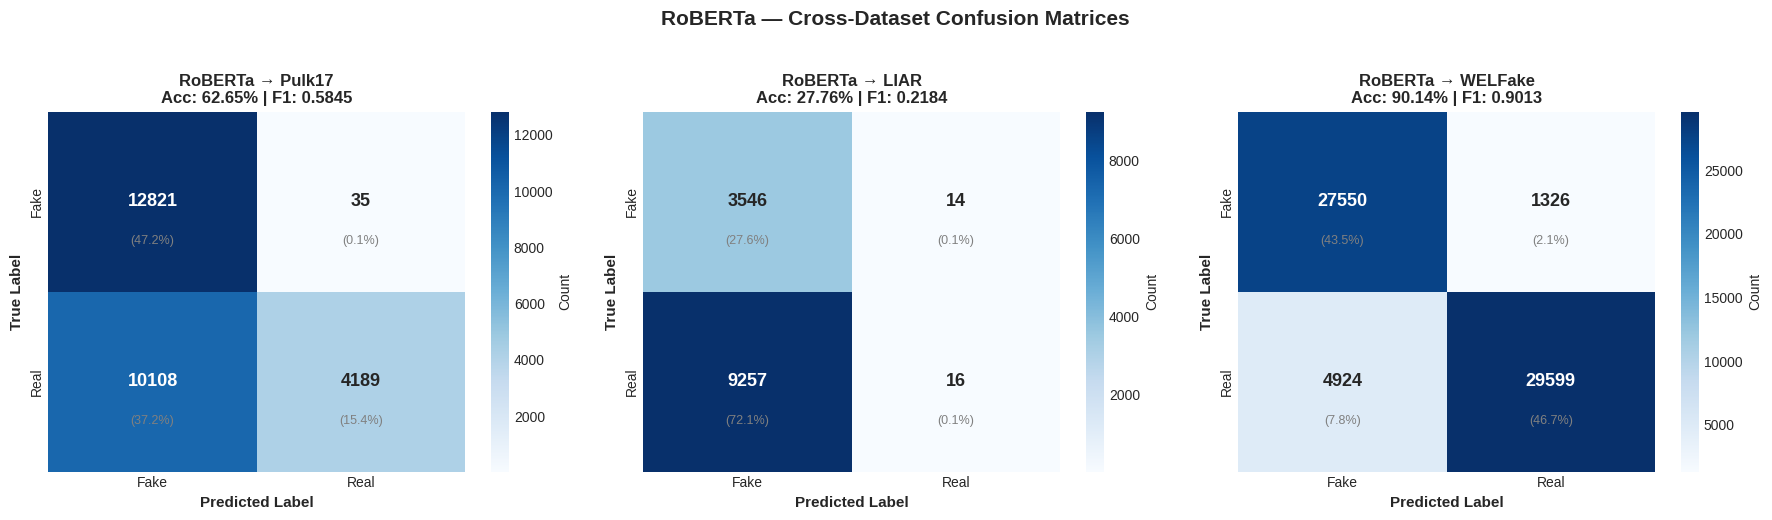

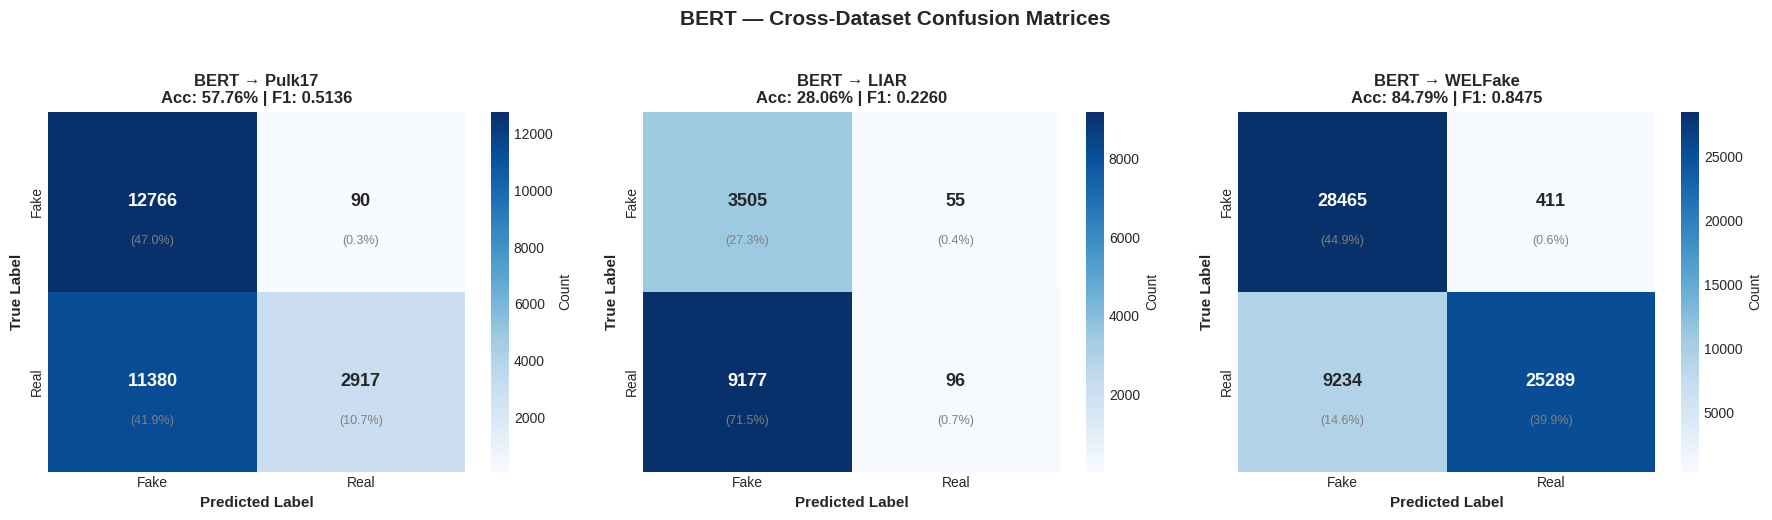

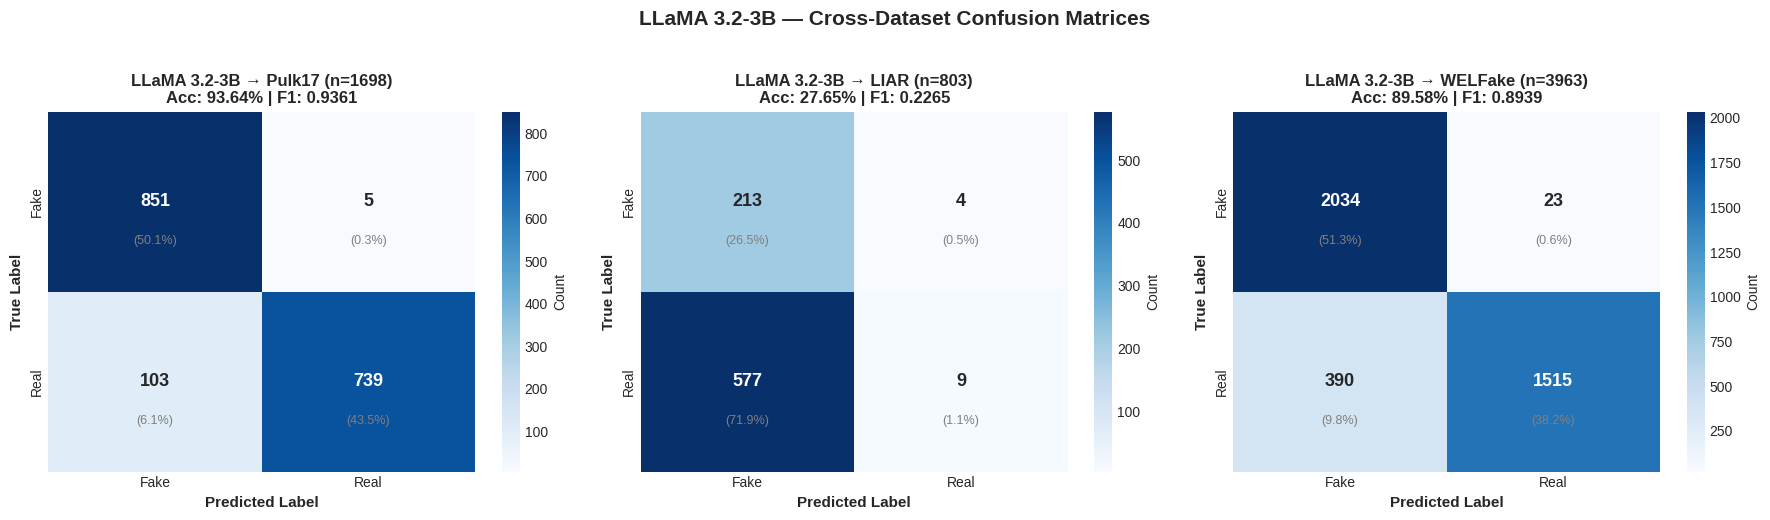

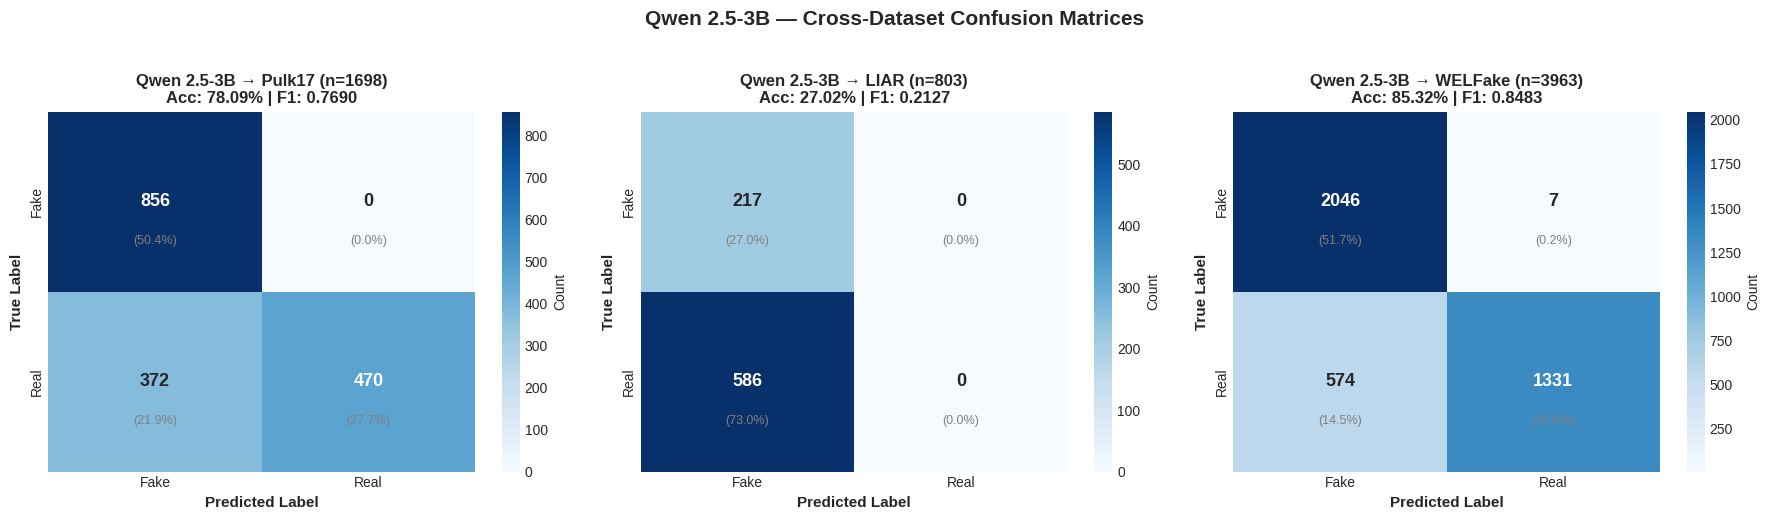

In [ ]:
# Cross-Dataset Confusion Matrices

# Plot confusion matrices for cross-dataset evaluation
def plot_cross_dataset_cms(results_dict, model_name, datasets_to_plot):

    n_datasets = len(datasets_to_plot)
    fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 5))

    if n_datasets == 1:
        axes = [axes]

    for ax, (key, display_name) in zip(axes, datasets_to_plot):
        res = results_dict.get(key)
        if res is None or 'predictions' not in res or 'true_labels' not in res:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
            ax.set_title(f'{model_name} → {display_name}', fontsize=13, fontweight='bold')
            continue

        cm = confusion_matrix(res['true_labels'], res['predictions'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Fake', 'Real'],
                    yticklabels=['Fake', 'Real'],
                    cbar_kws={'label': 'Count'},
                    annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)

        # Add percentages
        total = cm.sum()
        for i in range(2):
            for j in range(2):
                pct = cm[i, j] / total * 100
                ax.text(j + 0.5, i + 0.72, f'({pct:.1f}%)',
                        ha='center', va='center', fontsize=9, color='gray')

        ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
        ax.set_title(f'{model_name} → {display_name}\n'
                     f'Acc: {res["accuracy"]:.2%} | F1: {res["macro_f1"]:.4f}',
                     fontsize=12, fontweight='bold')

    plt.suptitle(f'{model_name} — Cross-Dataset Confusion Matrices',
                 fontsize=15, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'cross_dataset_cm_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


# RoBERTa
plot_cross_dataset_cms(RoBERTa_results, 'RoBERTa', [
    ('pulk17', 'Pulk17'),
    ('liar', 'LIAR'),
    ('welfake', 'WELFake'),
])

# BERT
plot_cross_dataset_cms(BERT_results, 'BERT', [
    ('pulk17', 'Pulk17'),
    ('liar', 'LIAR'),
    ('welfake', 'WELFake'),
])

# LLaMA
plot_cross_dataset_cms(llama_results, 'LLaMA 3.2-3B', [
    ('pulk17_sample', 'Pulk17 (n=1698)'),
    ('lia_sample', 'LIAR (n=803)'),
    ('welfake_sample', 'WELFake (n=3963)'),
])

# Qwen
plot_cross_dataset_cms(qwen_results, 'Qwen 2.5-3B', [
    ('pulk17_sample', 'Pulk17 (n=1698)'),
    ('liar_sample', 'LIAR (n=803)'),
    ('welfake_sample', 'WELFake (n=3963)'),
])

# LIME/SHAP Model Load

In [ ]:
# Confirm best model is loaded
model_RoBERTa.eval() # Change to best model

print(f"Model loaded on: {device}")
print(f"Label mapping: {id2label}")

Model loaded on: cuda
Label mapping: {0: 'Fake', 1: 'Real'}


# LIME/SHAP Prediction Wrapper

In [ ]:
def predict_proba(texts):
    model_RoBERTa.eval()
    all_probs = []

    # SHAP masker to pass numpy arrays of tokens and join them back to strings
    processed_texts = []
    for t in texts:
        if isinstance(t, str):
            processed_texts.append(t)
        else:
            # SHAP passes arrays of tokens to join back into a string
            processed_texts.append(' '.join([str(tok) for tok in t if str(tok).strip()]))

    # Process in batches to avoid OOM
    batch_size = 16
    for i in range(0, len(processed_texts), batch_size):
        batch_texts = processed_texts[i:i + batch_size]

        encodings = tokenizer_RoBERTa(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model_RoBERTa(**encodings)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    return np.vstack(all_probs)

# Prediction Sample

In [ ]:
# Select Examples to Explain

# Use test set predictions from evaluation
predictions = np.array(RoBERTa_test_metrics['predictions'])
true_labels = np.array(RoBERTa_test_metrics['true_labels'])
probabilities = np.array(RoBERTa_test_metrics['probabilities'])

# Get confidence scores (probability of predicted class)
confidence = np.max(probabilities, axis=1)

# Categorise predictions
correct_mask = predictions == true_labels
fake_mask = true_labels == 0
real_mask = true_labels == 1

# Select diverse examples for explanation
example_indices = {}

# Correct high-confidence Fake
candidates = np.where(correct_mask & fake_mask)[0]
if len(candidates) > 0:
    top = candidates[np.argsort(-confidence[candidates])[:2]]
    example_indices['Correct Fake (high conf)'] = top.tolist()

# Correct high-confidence Real
candidates = np.where(correct_mask & real_mask)[0]
if len(candidates) > 0:
    top = candidates[np.argsort(-confidence[candidates])[:2]]
    example_indices['Correct Real (high conf)'] = top.tolist()

# Misclassified examples (False Positives & False Negatives)
fp_mask = (predictions == 0) & (true_labels == 1)  # Real predicted as Fake
fn_mask = (predictions == 1) & (true_labels == 0)  # Fake predicted as Real

candidates = np.where(fp_mask)[0]
if len(candidates) > 0:
    example_indices['False Positive (Real→Fake)'] = candidates[:2].tolist()

candidates = np.where(fn_mask)[0]
if len(candidates) > 0:
    example_indices['False Negative (Fake→Real)'] = candidates[:2].tolist()

# Low-confidence correct predictions (near decision boundary)
low_conf_correct = np.where(correct_mask & (confidence < 0.7))[0]
if len(low_conf_correct) > 0:
    example_indices['Low confidence correct'] = low_conf_correct[:2].tolist()

print("Selected examples for XAI analysis:")
for category, indices in example_indices.items():
    for idx in indices:
        print(f"  {category}: idx={idx}, true={id2label[true_labels[idx]]}, "
              f"pred={id2label[predictions[idx]]}, conf={confidence[idx]:.4f}")

Selected examples for XAI analysis:
  Correct Fake (high conf): idx=4450, true=Fake, pred=Fake, conf=1.0000
  Correct Fake (high conf): idx=1063, true=Fake, pred=Fake, conf=1.0000
  Correct Real (high conf): idx=2899, true=Real, pred=Real, conf=1.0000
  Correct Real (high conf): idx=5227, true=Real, pred=Real, conf=1.0000
  False Positive (Real→Fake): idx=62, true=Real, pred=Fake, conf=0.9743
  False Positive (Real→Fake): idx=1205, true=Real, pred=Fake, conf=0.9906
  False Negative (Fake→Real): idx=73, true=Fake, pred=Real, conf=0.9929
  False Negative (Fake→Real): idx=643, true=Fake, pred=Real, conf=0.9874
  Low confidence correct: idx=5398, true=Real, pred=Real, conf=0.5833
  Low confidence correct: idx=6441, true=Fake, pred=Fake, conf=0.5226


# Retrieval of Raw Text

In [ ]:
# Retrieve Raw Text for Selected Examples

# Reload original text strings from the test split
dataset = load_dataset("GonzaloA/fake_news")

test_split = dataset['test']

# Collect all unique indices
all_explain_indices = []
for indices in example_indices.values():
    all_explain_indices.extend(indices)
all_explain_indices = sorted(set(all_explain_indices))

explain_texts = {}
for idx in all_explain_indices:
    row = test_split[idx]
    title = clean_text(row.get('title', '') or '')
    text = clean_text(row.get('text', '') or '')

    if title and text:
        combined = f"{title}. {text}"
    elif title:
        combined = title
    elif text:
        combined = text
    else:
        combined = "no content"

    # Strip source attribution tags (same as training preprocessing)
    combined = re.sub(r'\(reuters\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(ap\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'\(afp\)', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r'- reuters', '', combined, flags=re.IGNORECASE)
    combined = re.sub(r"\s+", " ", combined).strip()

    # Truncate for SHAP/LIME compute efficiency
    explain_texts[idx] = combined[:1500]

print(f"Retrieved {len(explain_texts)} texts for explanation")
for idx in list(explain_texts.keys())[:3]:
    print(f"  idx={idx}: {explain_texts[idx][:120]}...")

Repo card metadata block was not found. Setting CardData to empty.


Retrieved 10 texts for explanation
  idx=62: tom hayden from sds and viet cong to progressives for obama. search the left in power clinton to obama david horowitz ex...
  idx=73: exstate dept employee sending sensitive info to private email norm under clinton. get ready for civil unrest survey find...
  idx=643: ron brown evidence of a cover up. clinton transmitted classified info to her lawyers andrew mccarthy theres no attorney ...


# LIME

In [ ]:
# LIME Analysis

explainer_lime = LimeTextExplainer(
    class_names=['Fake', 'Real'],
    split_expression=r'\W+',  # Split on non-word characters
    random_state=42
)

lime_results = {}

for category, indices in example_indices.items():
    for idx in indices:
        text = explain_texts[idx]
        true_label = true_labels[idx]
        pred_label = predictions[idx]

        print(f"\n{'='*60}")
        print(f"LIME — {category} | idx={idx}")
        print(f"True: {id2label[true_label]} | Pred: {id2label[pred_label]} | Conf: {confidence[idx]:.4f}")
        print(f"Text: {text[:150]}...")
        print(f"{'='*60}")

        # Generate LIME explanation
        exp = explainer_lime.explain_instance(
            text,
            predict_proba,
            num_features=15,
            num_samples=500,  # Number of perturbations
            labels=(0, 1)
        )

        # Store result
        lime_results[idx] = {
            'explanation': exp,
            'category': category,
            'true_label': true_label,
            'pred_label': pred_label,
            'confidence': confidence[idx]
        }

        # Print top features
        print(f"\nTop features for predicted class ({id2label[pred_label]}):")
        for word, weight in exp.as_list(label=pred_label):
            direction = "→ Fake" if weight < 0 else "→ Real"
            if pred_label == 0:
                direction = "→ Fake" if weight > 0 else "→ Real"
            print(f"  {word:>20s}: {weight:+.4f}  {direction}")

print(f"\nLIME analysis complete: {len(lime_results)} examples explained")


LIME — Correct Fake (high conf) | idx=4450
True: Fake | Pred: Fake | Conf: 1.0000
Text: elizabeth warren supporter purchases pocahontas domain, trolls donald trump. as elizabeth warren amps up her attacks on the donald trump and his fraud...

Top features for predicted class (Fake):
           considering: +0.0000  → Fake
                   but: +0.0000  → Fake
                    it: +0.0000  → Fake
                domain: +0.0000  → Fake
                 looms: +0.0000  → Fake
                   com: +0.0000  → Fake
                  over: +0.0000  → Fake
               nominee: -0.0000  → Real
              national: -0.0000  → Real
                   and: -0.0000  → Real
                   due: +0.0000  → Fake
                   yet: -0.0000  → Real
               running: -0.0000  → Real
                 where: -0.0000  → Real
                 roger: -0.0000  → Real

LIME — Correct Fake (high conf) | idx=1063
True: Fake | Pred: Fake | Conf: 1.0000
Text: boiler room 61 hello from 

# LIME Visualisation

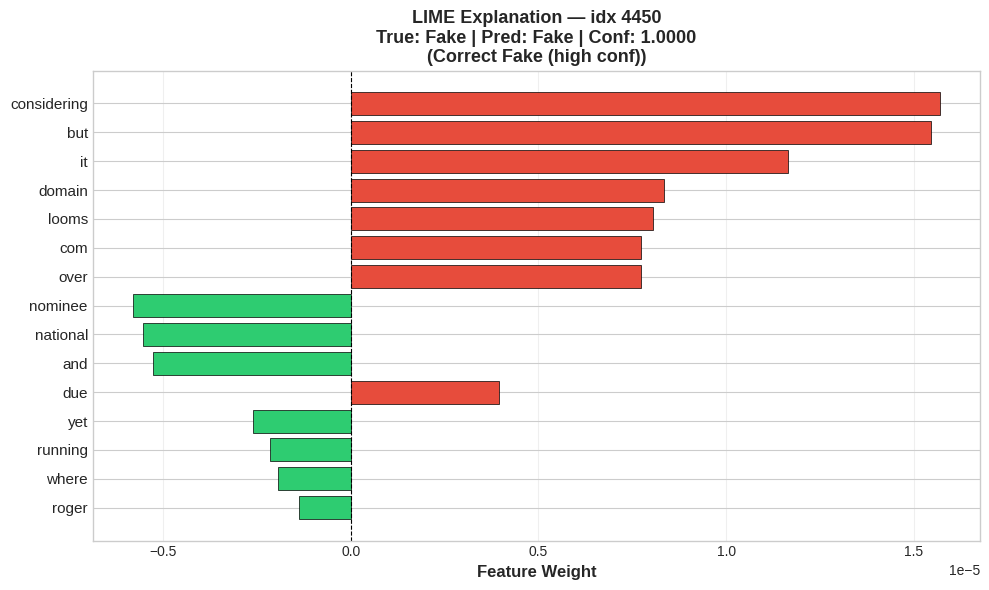

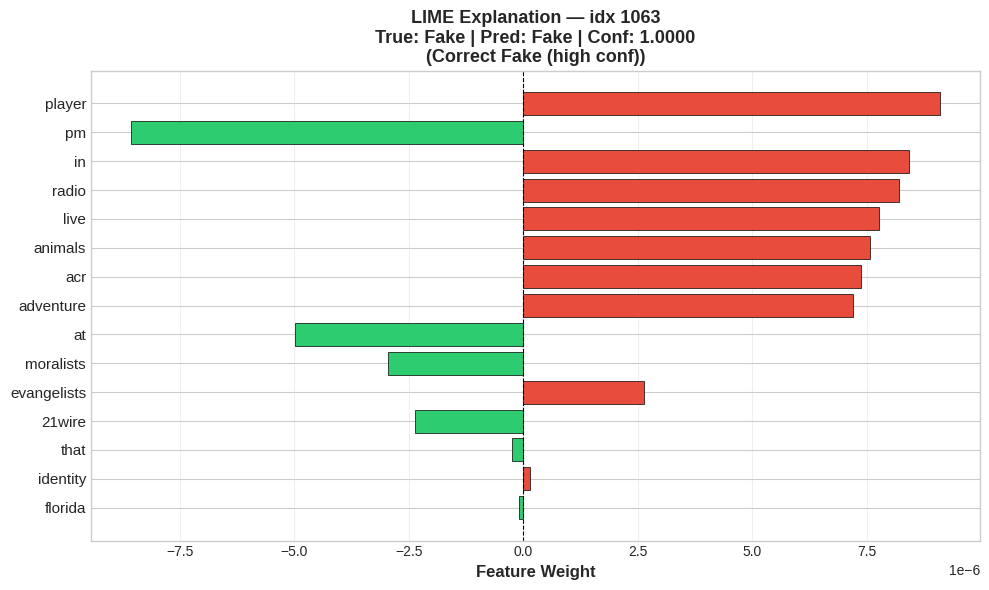

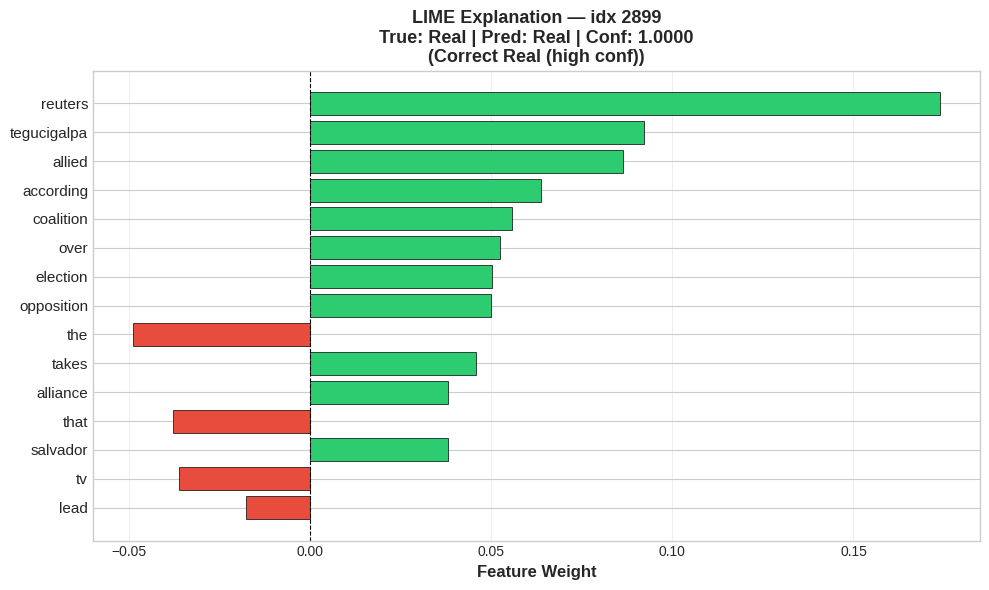

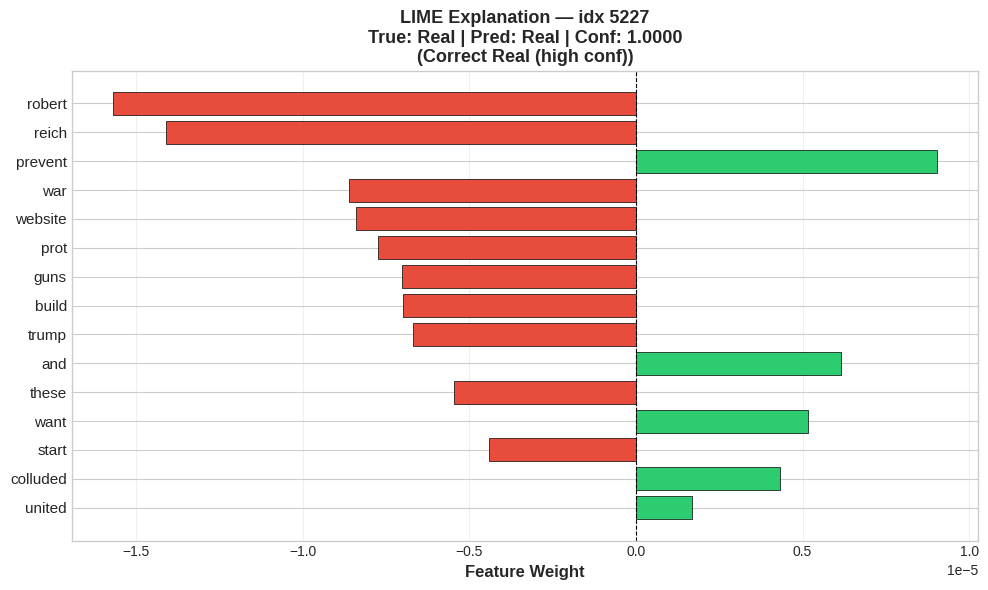

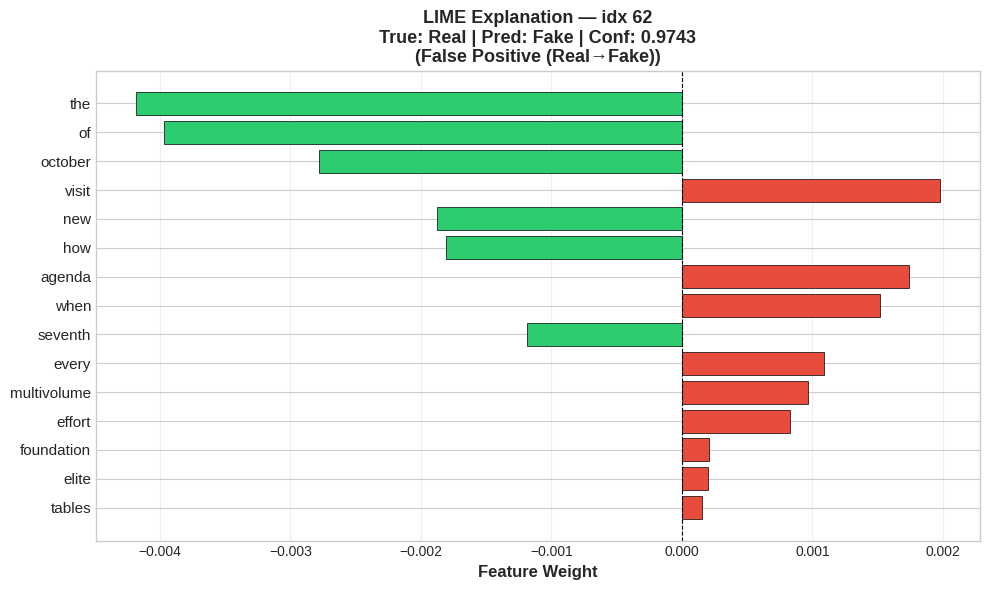

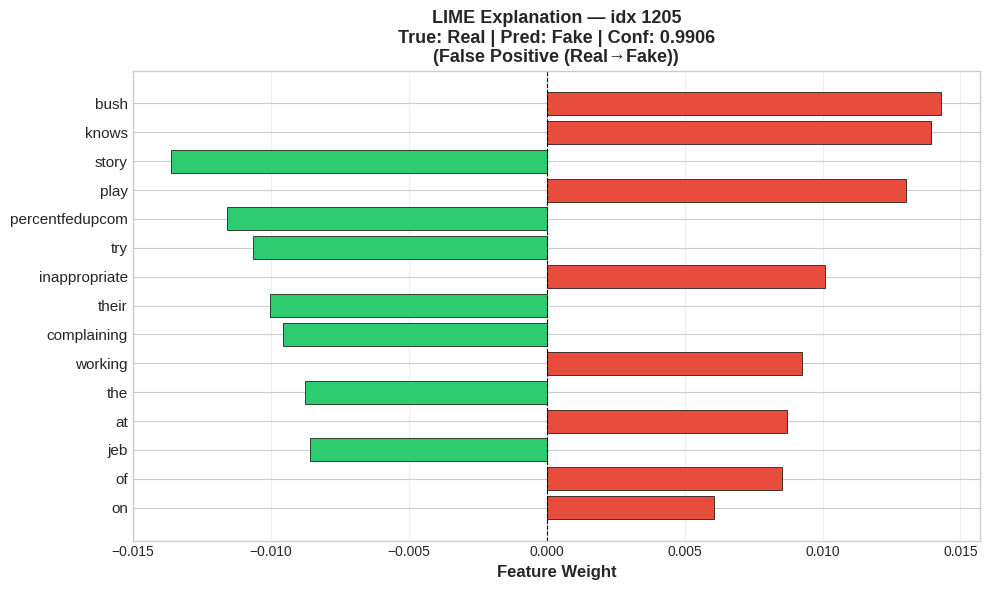

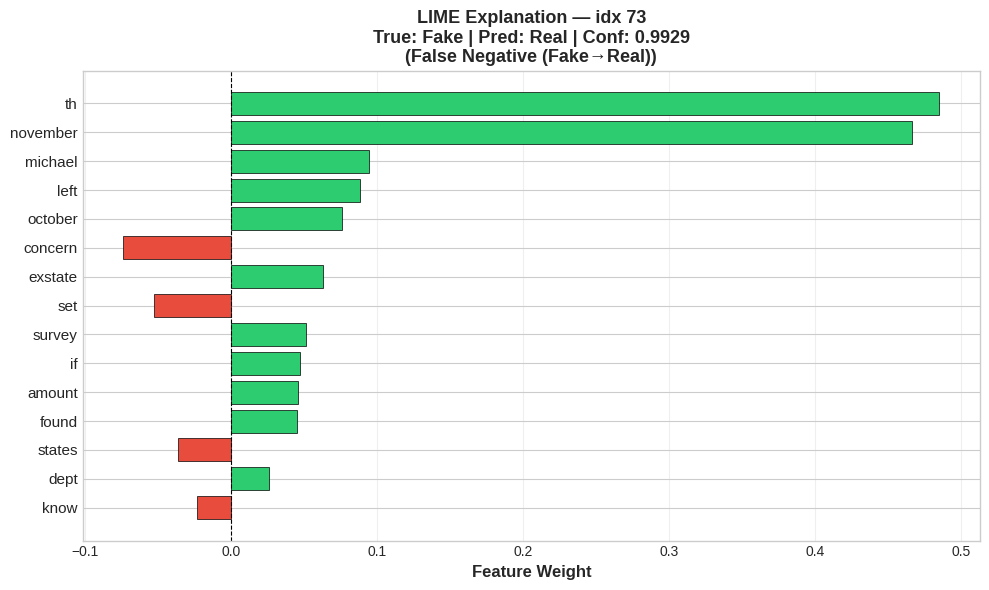

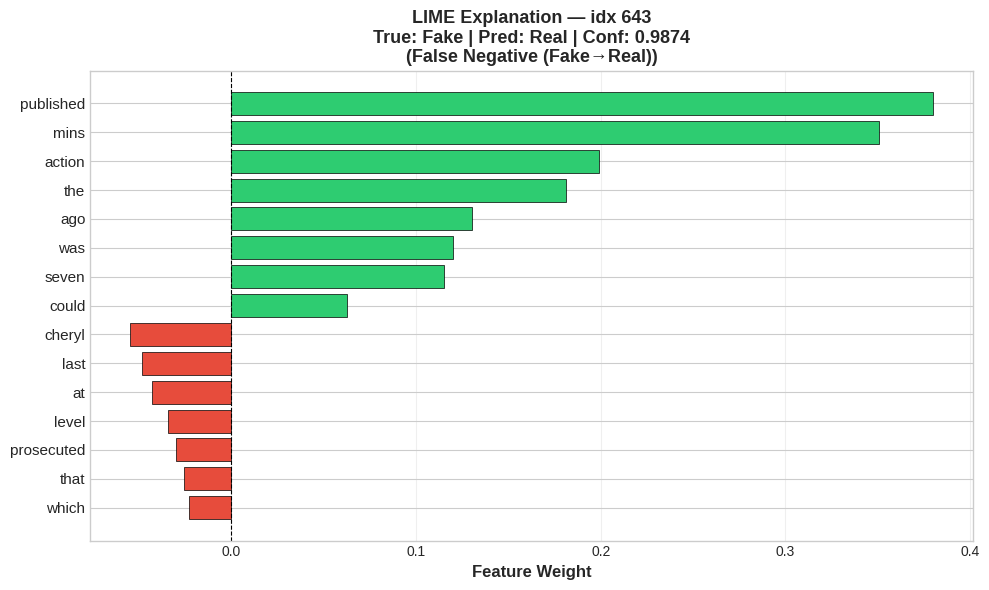

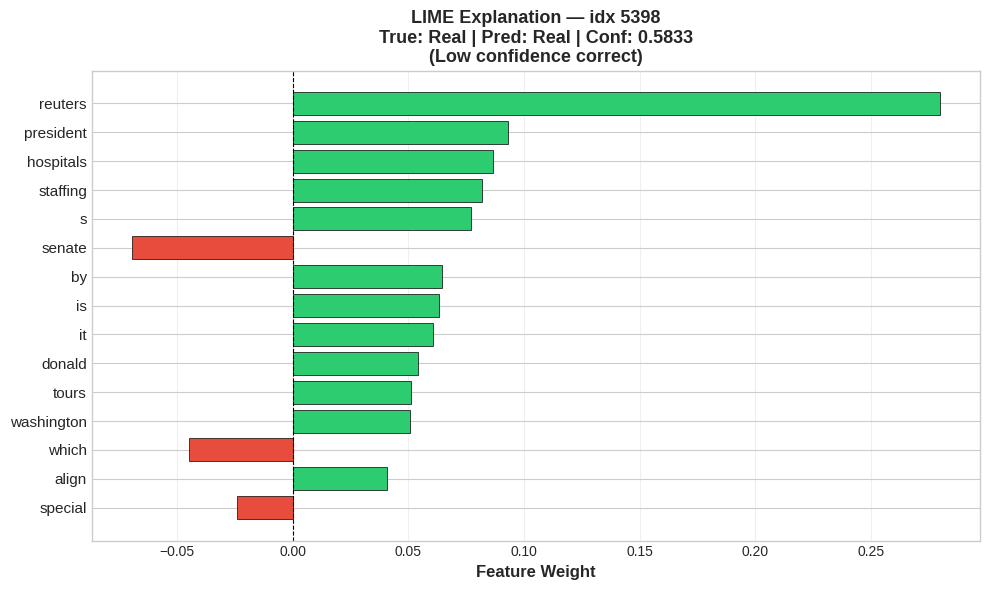

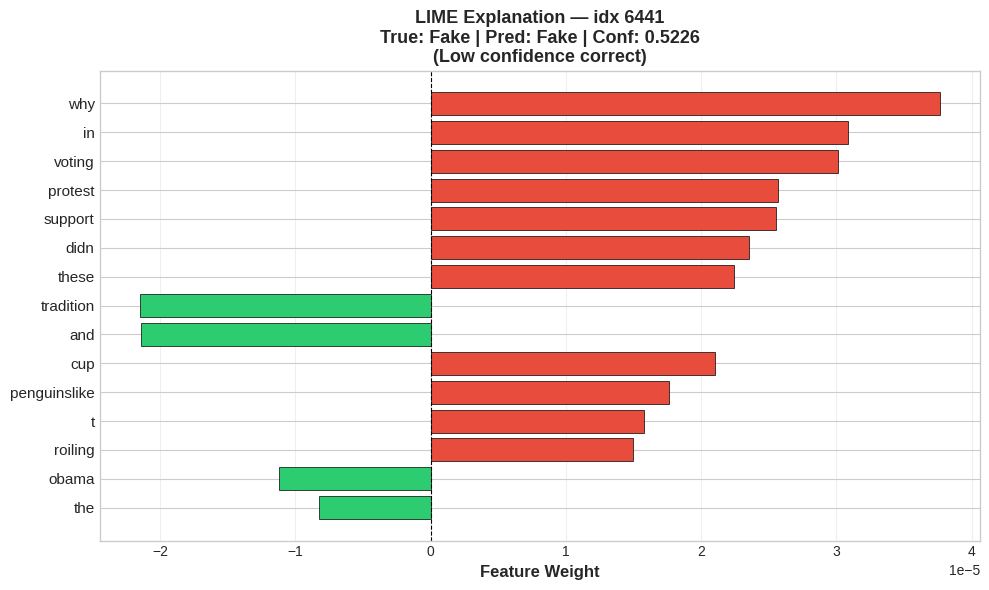

In [ ]:
# LIME Visualisation — Token Highlighting

# Plot LIME feature importance as horizontal bar chart
def plot_lime_explanation(lime_result, idx, save=False):
    exp = lime_result['explanation']
    pred_label = lime_result['pred_label']
    true_label = lime_result['true_label']
    conf = lime_result['confidence']
    category = lime_result['category']

    features = exp.as_list(label=pred_label)
    words = [f[0] for f in features]
    weights = [f[1] for f in features]

    # Colour: green for Real-leaning, red for Fake-leaning
    if pred_label == 1:  # Predicted Real
        colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
    else:  # Predicted Fake
        colors = ['#e74c3c' if w > 0 else '#2ecc71' for w in weights]

    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(words))
    ax.barh(y_pos, weights, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Weight', fontsize=12, fontweight='bold')
    ax.set_title(f'LIME Explanation — idx {idx}\n'
                 f'True: {id2label[true_label]} | Pred: {id2label[pred_label]} | Conf: {conf:.4f}\n'
                 f'({category})',
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    if save:
        plt.savefig(f'lime_explanation_idx{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot all LIME results
for idx, result in lime_results.items():
    plot_lime_explanation(result, idx, save=True)

# SHAP

In [ ]:
# SHAP Analysis

# SHAP masker and explainer for text
masker = shap.maskers.Text(r"\W+") # Split on non-word characters

shap_explainer = shap.Explainer(
    predict_proba,
    masker,
    output_names=['Fake', 'Real']
)

shap_results = {}

for category, indices in example_indices.items():
    for idx in indices:
        text = explain_texts[idx]
        true_label = true_labels[idx]
        pred_label = predictions[idx]

        print(f"\n{'='*60}")
        print(f"SHAP — {category} | idx={idx}")
        print(f"True: {id2label[true_label]} | Pred: {id2label[pred_label]} | Conf: {confidence[idx]:.4f}")
        print(f"{'='*60}")

        # Compute SHAP values
        shap_values = shap_explainer([text])

        shap_results[idx] = {
            'shap_values': shap_values,
            'category': category,
            'true_label': true_label,
            'pred_label': pred_label,
            'confidence': confidence[idx]
        }

        # Print top tokens by absolute SHAP value for predicted class
        tokens = shap_values.data[0]
        values = shap_values.values[0][:, pred_label]

        token_importance = sorted(zip(tokens, values), key=lambda x: abs(x[1]), reverse=True)

        print(f"\nTop 15 tokens by SHAP importance (for {id2label[pred_label]}):")
        for token, val in token_importance[:15]:
            direction = "→ Real" if val > 0 and pred_label == 1 else "→ Fake"
            if pred_label == 0:
                direction = "→ Fake" if val > 0 else "→ Real"
            print(f"  {str(token):>20s}: {val:+.4f}  {direction}")

print(f"\nSHAP analysis complete: {len(shap_results)} examples explained")


SHAP — Correct Fake (high conf) | idx=4450
True: Fake | Pred: Fake | Conf: 1.0000

Top 15 tokens by SHAP importance (for Fake):
               trump. : -0.0381  → Real
                   as : -0.0225  → Real
               humor. : +0.0150  → Fake
                after : -0.0130  → Real
                  but : +0.0128  → Fake
                   as : +0.0116  → Fake
              attacks : -0.0115  → Real
                   up : -0.0103  → Real
                write : +0.0101  → Fake
               simply : +0.0100  → Fake
                 good : +0.0100  → Fake
                   as : +0.0100  → Fake
                scott : +0.0095  → Fake
                  her : +0.0090  → Fake
                  her : -0.0088  → Real

SHAP — Correct Fake (high conf) | idx=1063
True: Fake | Pred: Fake | Conf: 1.0000

Top 15 tokens by SHAP importance (for Fake):
             starting : +0.0161  → Fake
                hello : +0.0145  → Fake
               boiler : -0.0142  → Real
                radio 

# SHAP Visualisation


SHAP Text Plot — idx 4450 | Correct Fake (high conf)
True: Fake | Pred: Fake | Conf: 1.0000


[Interactive SHAP text plots removed to keep the notebook under GitHub's 25 MB upload limit. Re-run this cell to regenerate them. Token-level SHAP values for the analysed instances are printed in the SHAP cell above.]


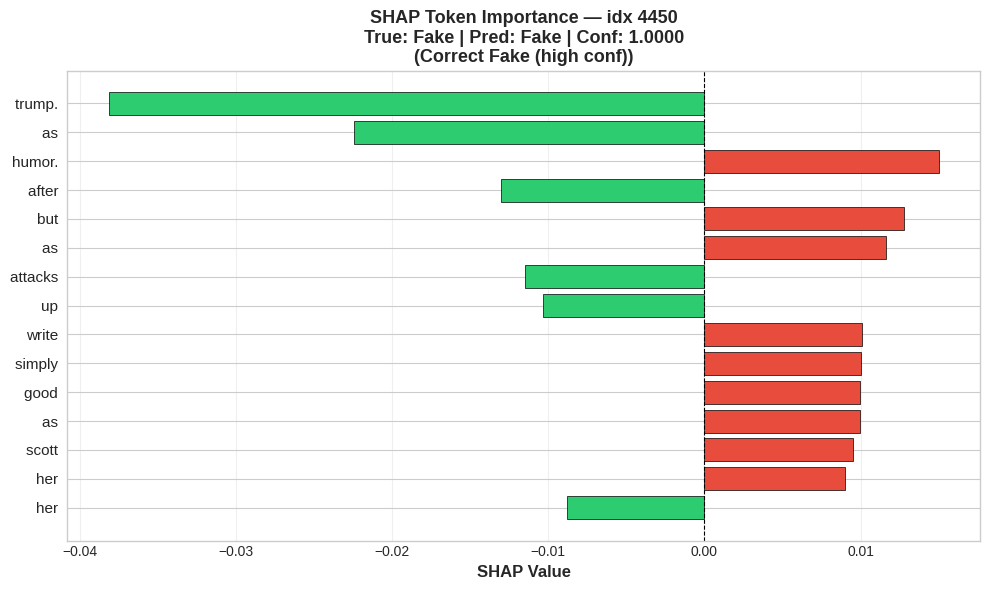


SHAP Text Plot — idx 1063 | Correct Fake (high conf)
True: Fake | Pred: Fake | Conf: 1.0000


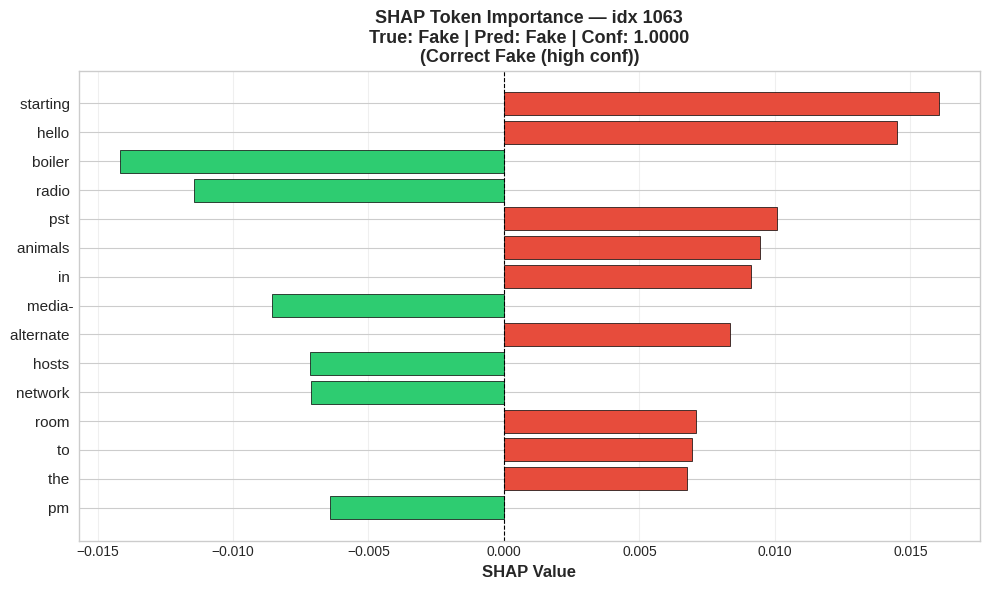


SHAP Text Plot — idx 2899 | Correct Real (high conf)
True: Real | Pred: Real | Conf: 1.0000


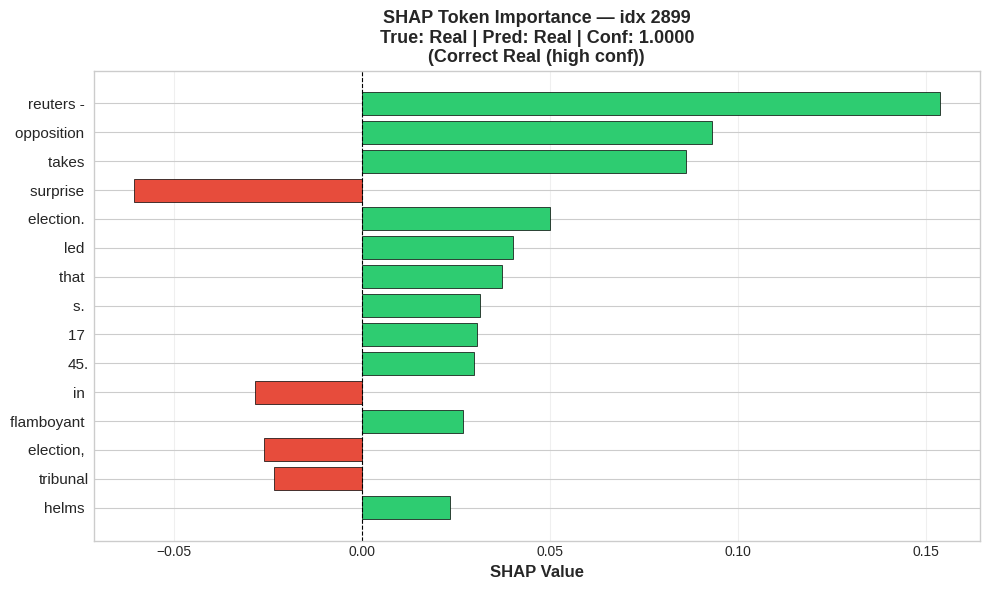


SHAP Text Plot — idx 5227 | Correct Real (high conf)
True: Real | Pred: Real | Conf: 1.0000


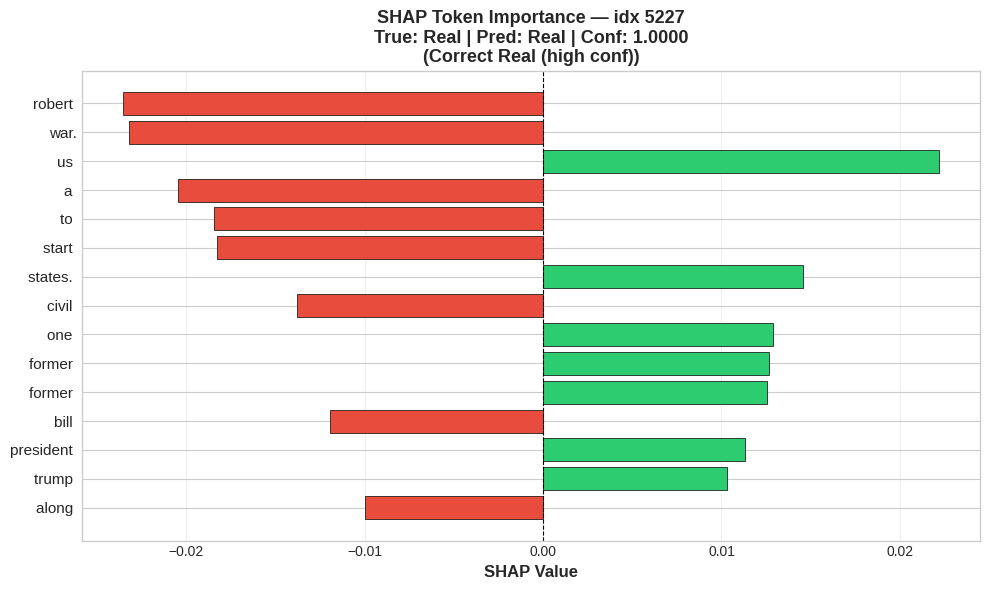


SHAP Text Plot — idx 62 | False Positive (Real→Fake)
True: Real | Pred: Fake | Conf: 0.9743


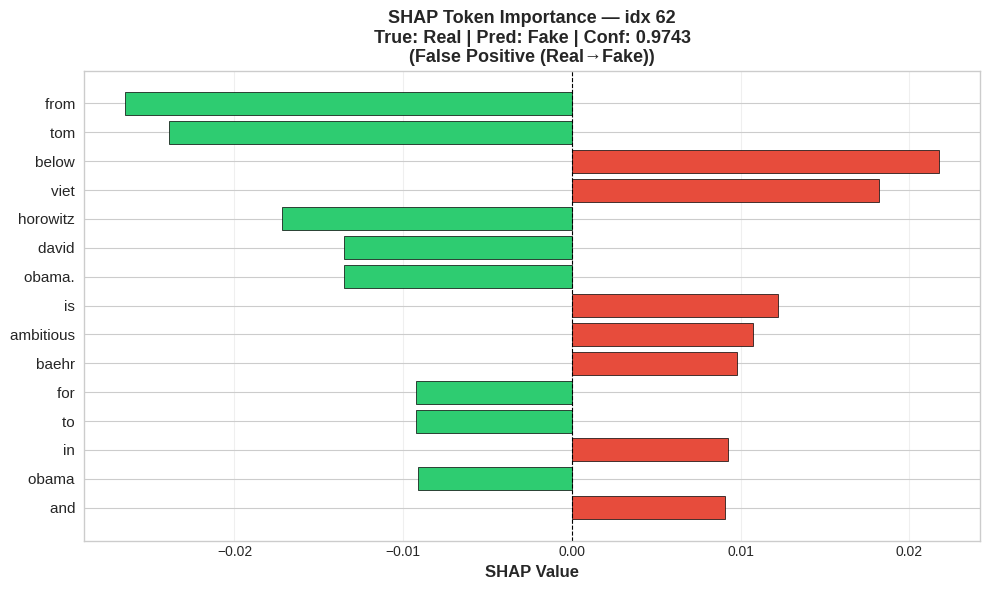


SHAP Text Plot — idx 1205 | False Positive (Real→Fake)
True: Real | Pred: Fake | Conf: 0.9906


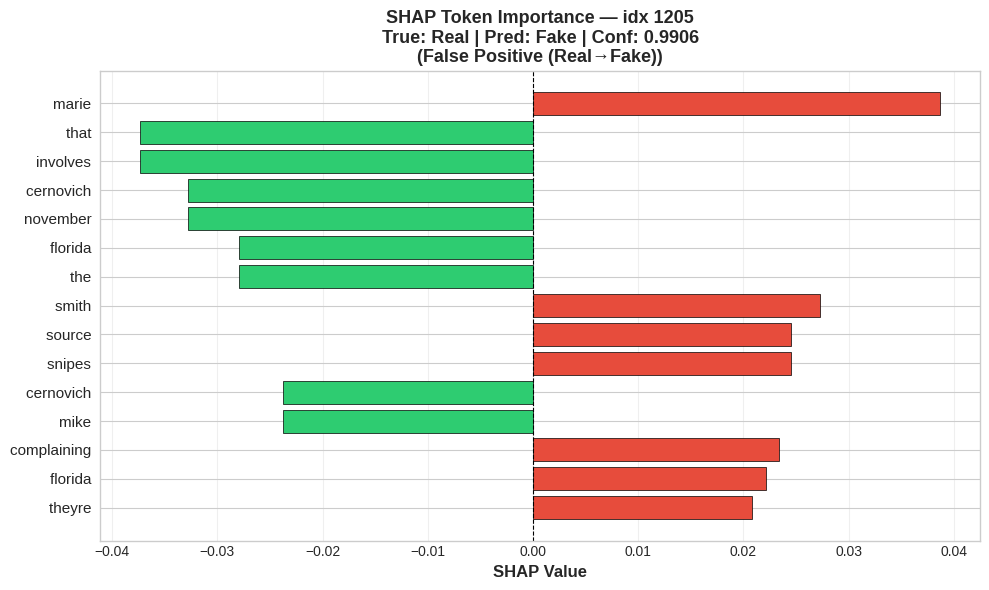


SHAP Text Plot — idx 73 | False Negative (Fake→Real)
True: Fake | Pred: Real | Conf: 0.9929


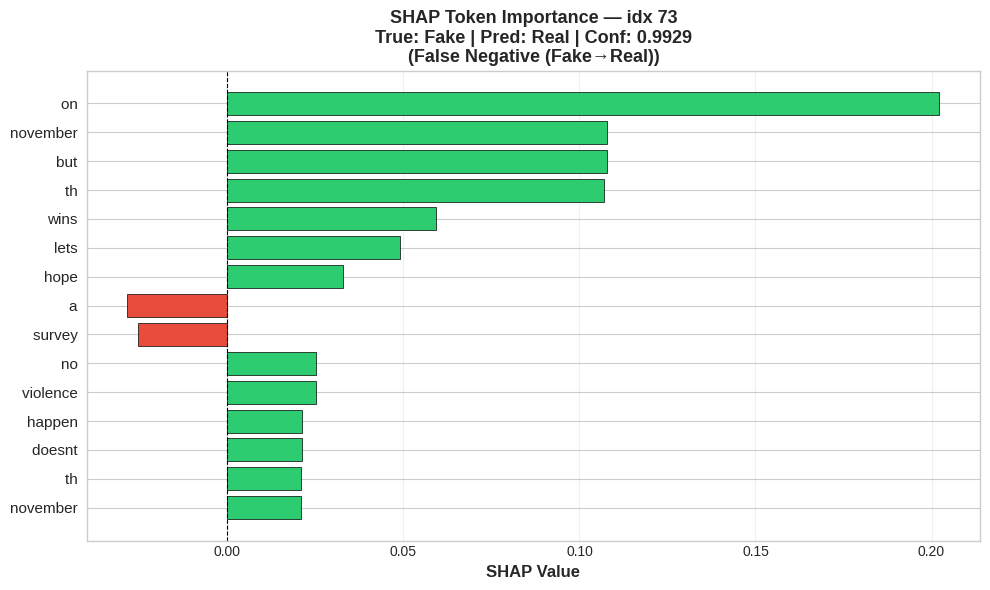


SHAP Text Plot — idx 643 | False Negative (Fake→Real)
True: Fake | Pred: Real | Conf: 0.9874


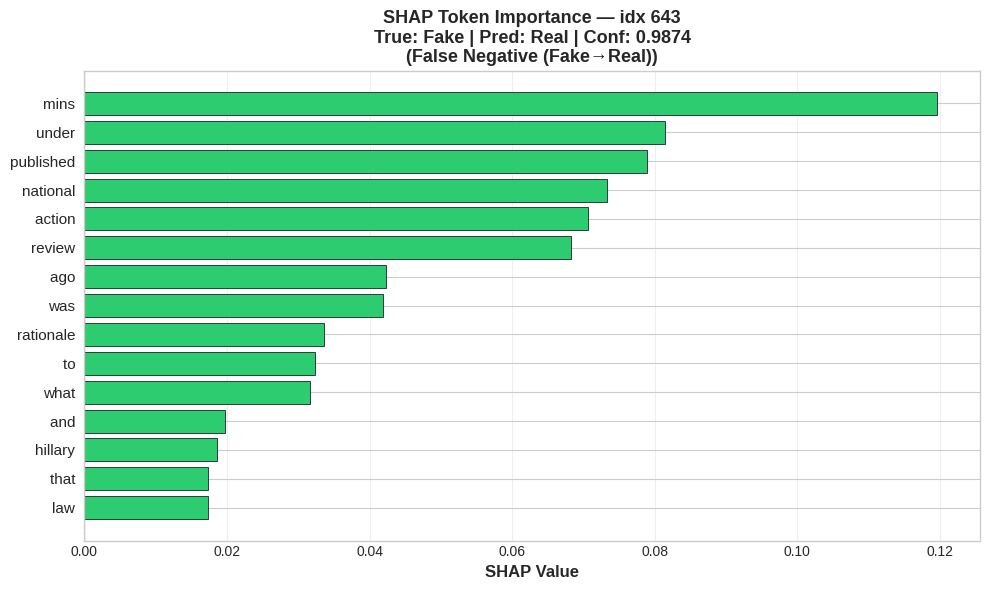


SHAP Text Plot — idx 5398 | Low confidence correct
True: Real | Pred: Real | Conf: 0.5833


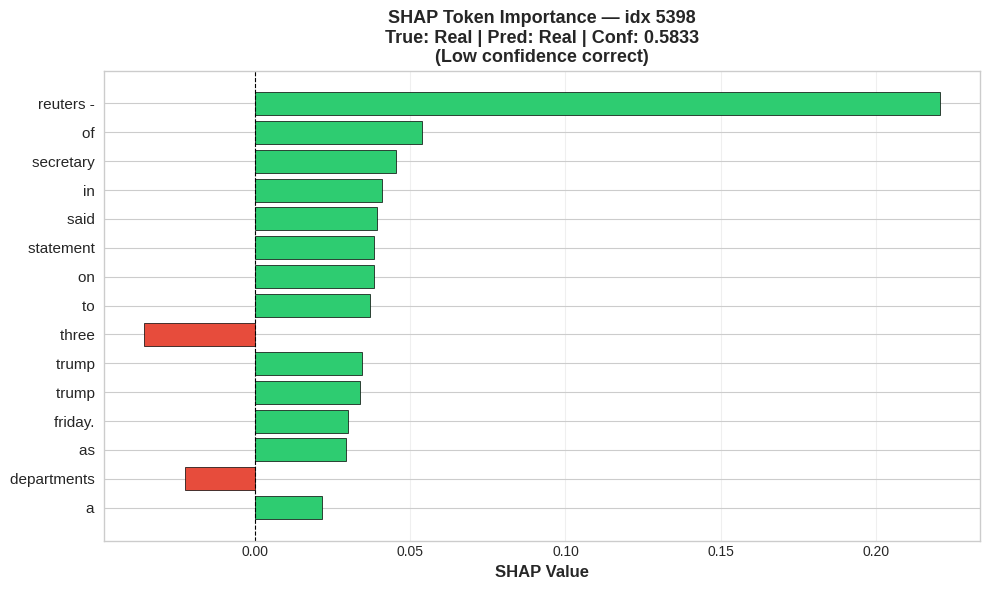


SHAP Text Plot — idx 6441 | Low confidence correct
True: Fake | Pred: Fake | Conf: 0.5226


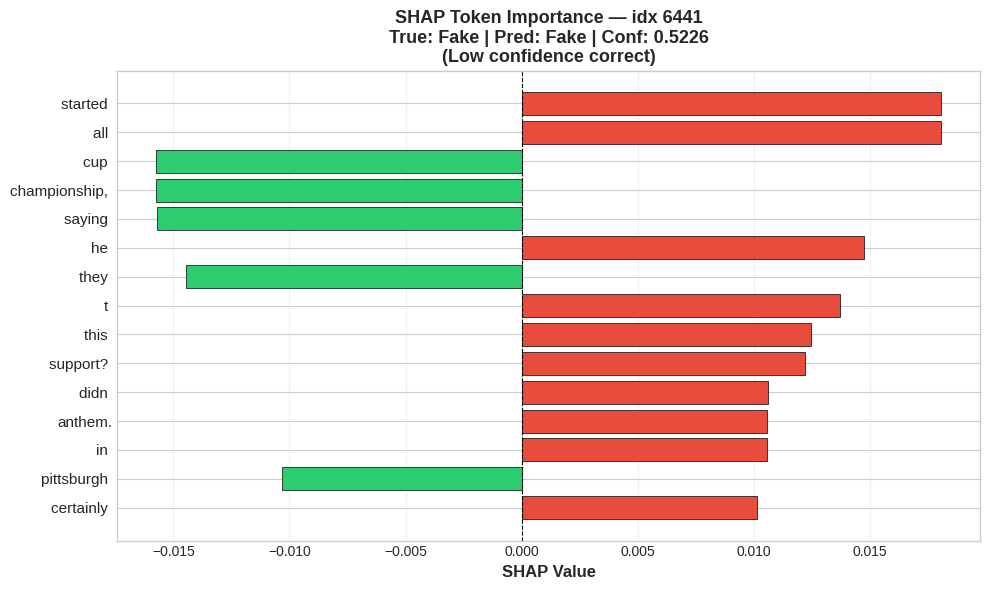

In [ ]:
# SHAP Visualisation (Text Plot and Bar Chart)

for idx, result in shap_results.items():
    sv = result['shap_values']
    pred_label = result['pred_label']
    true_label = result['true_label']
    category = result['category']
    conf = result['confidence']

    print(f"\n{'='*60}")
    print(f"SHAP Text Plot — idx {idx} | {category}")
    print(f"True: {id2label[true_label]} | Pred: {id2label[pred_label]} | Conf: {conf:.4f}")
    print(f"{'='*60}")

    # SHAP built-in text plot (token-level colour highlighting)
    shap.plots.text(sv[0], display=True)

    # Bar chart of top tokens
    tokens = sv.data[0]
    values = sv.values[0][:, pred_label]

    # Sort by absolute value, take top 15
    sorted_indices = np.argsort(np.abs(values))[::-1][:15]
    top_tokens = [str(tokens[i]) for i in sorted_indices]
    top_values = [values[i] for i in sorted_indices]

    # Colour by direction
    if pred_label == 1:
        colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_values]
    else:
        colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_values]

    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(top_tokens))
    ax.barh(y_pos, top_values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_tokens, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP Value', fontsize=12, fontweight='bold')
    ax.set_title(f'SHAP Token Importance — idx {idx}\n'
                 f'True: {id2label[true_label]} | Pred: {id2label[pred_label]} | Conf: {conf:.4f}\n'
                 f'({category})',
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'shap_bar_idx{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# LIME vs SHAP Agreement Analysis

In [ ]:
# SHAP vs LIME Agreement Analysis

print("SHAP vs LIME (Agreement Analysis)\n")

for idx in shap_results:
    if idx not in lime_results:
        continue

    sv = shap_results[idx]['shap_values']
    pred_label = shap_results[idx]['pred_label']
    true_label = shap_results[idx]['true_label']
    category = shap_results[idx]['category']

    # SHAP top tokens
    tokens_shap = sv.data[0]
    values_shap = sv.values[0][:, pred_label]
    shap_top = sorted(zip([str(t) for t in tokens_shap], values_shap),
                      key=lambda x: abs(x[1]), reverse=True)[:15]
    shap_top_words = set(w.lower().strip() for w, _ in shap_top)

    # LIME top tokens
    lime_exp = lime_results[idx]['explanation']
    lime_top = lime_exp.as_list(label=pred_label)[:15]
    lime_top_words = set(w.lower().strip() for w, _ in lime_top)

    # Agreement
    agreement = shap_top_words & lime_top_words
    overlap_pct = len(agreement) / max(len(shap_top_words | lime_top_words), 1) * 100

    print(f"idx={idx} | {category}")
    print(f"  True: {id2label[true_label]} | Pred: {id2label[pred_label]}")
    print(f"  SHAP top 15: {shap_top_words}")
    print(f"  LIME top 15: {lime_top_words}")
    print(f"  Overlap: {agreement} ({overlap_pct:.1f}%)")
    print(f"  SHAP-only: {shap_top_words - lime_top_words}")
    print(f"  LIME-only: {lime_top_words - shap_top_words}")
    print()

SHAP vs LIME (Agreement Analysis)

idx=4450 | Correct Fake (high conf)
  True: Fake | Pred: Fake
  SHAP top 15: {'trump.', 'as', 'after', 'humor.', 'good', 'scott', 'but', 'write', 'her', 'up', 'attacks', 'simply'}
  LIME top 15: {'due', 'over', 'yet', 'com', 'but', 'domain', 'it', 'roger', 'where', 'nominee', 'looms', 'considering', 'national', 'running', 'and'}
  Overlap: {'but'} (3.8%)
  SHAP-only: {'trump.', 'as', 'after', 'humor.', 'good', 'scott', 'her', 'up', 'write', 'attacks', 'simply'}
  LIME-only: {'due', 'over', 'yet', 'com', 'it', 'domain', 'roger', 'where', 'nominee', 'looms', 'considering', 'national', 'running', 'and'}

idx=1063 | Correct Fake (high conf)
  True: Fake | Pred: Fake
  SHAP top 15: {'media-', 'animals', 'pm', 'room', 'the', 'alternate', 'hosts', 'network', 'to', 'starting', 'in', 'boiler', 'radio', 'pst', 'hello'}
  LIME top 15: {'florida', 'pm', 'live', 'animals', 'evangelists', 'that', 'acr', 'moralists', 'identity', 'in', 'adventure', 'player', 'radio',

# References

Davanstrien (2023) 'WELFake'. Available at: https://huggingface.co/datasets/davanstrien/WELFake (Accessed: 6 February 2026).

GonzaloA (2022) fake_news. Available at: https://huggingface.co/datasets/GonzaloA/fake_news (Accessed: 6 February 2026).

Pulk17 (2024) Fake-News-Detection-dataset. Available at: https://huggingface.co/datasets/Pulk17/Fake-News-Detection-dataset (Accessed: 28 January 2026).

UKPLab (2023) liar. Available at: https://huggingface.co/datasets/UKPLab/liar (Accessed: 28 January 2026).